# 07 — Unsupervised Vulnerability Profiles and Hidden-Risk Screening

This notebook identifies recurring forms of climate-housing vulnerability that are not captured by the Low/Medium/High score alone. Seven standardized vulnerability dimensions are clustered across the complete 2011–2025 county-year panel, followed by profile interpretation, temporal and bootstrap robustness checks, PCA visualization, county summaries, and hidden-risk sensitivity analysis.

**Input:** `data/processed/florida_county_year_vulnerability_2011_2025.csv`  
**Outputs:** 47 clustering and county tables, 13 regenerated figures, a fitted scaler, the final K-Means model, and a two-component PCA model.

Clustering is descriptive and exploratory. Profile labels summarize observed combinations of vulnerability dimensions; they are not externally validated causal categories.


## 1. Setup and data validation

The shared configuration supplies project paths, years, random state, and semantic colours. Notebook 04 is the only required upstream stage.


In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from IPython.display import Image, display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


def locate_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (  # noqa: E402
    PROJECT_COLORS,
    RANDOM_STATE,
    STUDY_END_YEAR,
    STUDY_START_YEAR,
)

PROJECT_START_YEAR = STUDY_START_YEAR
PROJECT_END_YEAR = STUDY_END_YEAR
INPUT_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "florida_county_year_vulnerability_2011_2025.csv"
)
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables" / "vulnerability_clustering"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures" / "vulnerability_clustering"
RESULTS_LOGS = PROJECT_ROOT / "results" / "logs"
RESULTS_MODELS = PROJECT_ROOT / "results" / "models" / "vulnerability_clustering"
for output_directory in [RESULTS_TABLES, RESULTS_FIGURES, RESULTS_LOGS, RESULTS_MODELS]:
    output_directory.mkdir(parents=True, exist_ok=True)

# The same profile colours are reused wherever the four final profiles appear.
PROFILE_COLORS = [
    PROJECT_COLORS["resilience"],
    PROJECT_COLORS["disaster"],
    PROJECT_COLORS["housing"],
    PROJECT_COLORS["social"],
]
CLASS_COLORS = {
    "Low": PROJECT_COLORS["resilience"],
    "Medium": PROJECT_COLORS["nfip"],
    "High": PROJECT_COLORS["disaster"],
}
HIDDEN_RISK_COLORS = {
    "Other County": PROJECT_COLORS["light_neutral"],
    "Hidden Risk": PROJECT_COLORS["climate"],
    "Priority Hidden Risk": PROJECT_COLORS["disaster"],
}

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook", palette=PROFILE_COLORS)
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input: {INPUT_DATA_PATH}")
print(f"Tables: {RESULTS_TABLES}")
print(f"Figures: {RESULTS_FIGURES}")


Project root: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation
Input: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\data\processed\florida_county_year_vulnerability_2011_2025.csv
Tables: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering
Figures: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering


In [2]:
if not INPUT_DATA_PATH.exists():
    raise FileNotFoundError(
        "Run cleaned Notebook 04 first. Missing input: " f"{INPUT_DATA_PATH}"
    )

county_year_data = pd.read_csv(INPUT_DATA_PATH, dtype={"STCOFIPS": "string"})
county_year_data["STCOFIPS"] = county_year_data["STCOFIPS"].str.zfill(5)
county_year_data = county_year_data.sort_values(["Year", "STCOFIPS"]).reset_index(
    drop=True
)

CLUSTERING_FEATURES = [
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score",
]
required_columns = [
    "STCOFIPS",
    "RegionName",
    "Year",
    "vulnerability_class",
    "climate_housing_vulnerability_score",
] + CLUSTERING_FEATURES
missing_columns = [
    column for column in required_columns if column not in county_year_data
]
duplicate_count = int(county_year_data.duplicated(["STCOFIPS", "Year"]).sum())
missing_clustering_rows = int(
    county_year_data[CLUSTERING_FEATURES].isna().any(axis=1).sum()
)

if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")
assert duplicate_count == 0, "Duplicate county-year observations detected."
assert missing_clustering_rows == 0, "Missing clustering dimensions detected."
assert county_year_data["Year"].min() == STUDY_START_YEAR
assert county_year_data["Year"].max() == STUDY_END_YEAR
assert county_year_data["STCOFIPS"].nunique() == 67

dataset_audit = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Columns",
            "Counties",
            "Year range",
            "Duplicate county-years",
            "Rows missing clustering dimensions",
        ],
        "value": [
            len(county_year_data),
            county_year_data.shape[1],
            county_year_data["STCOFIPS"].nunique(),
            f"{county_year_data['Year'].min()}–{county_year_data['Year'].max()}",
            duplicate_count,
            missing_clustering_rows,
        ],
    }
)
display(dataset_audit)


,check,value
0,Rows,1000
1,Columns,123
2,Counties,67
3,Year range,2011–2025
4,Duplicate county-years,0
5,Rows missing clustering dimensions,0


## 2. Clustering dimensions and standardized feature space

Clusters are created from seven score dimensions: affordability stress, climate exposure, disaster history, socioeconomic vulnerability, resilience adjustment, insurance-loss stress, and spatial spillovers. Housing outcomes and the final composite score are reserved for interpretation and do not determine cluster membership.


In [3]:
CLUSTERING_FEATURES = [
    "affordability_stress_score",
    "climate_exposure_score",
    "disaster_history_score",
    "socioeconomic_vulnerability_score",
    "resilience_adjustment_score",
    "insurance_loss_stress_score",
    "spatial_spillover_score",
]

PROFILING_FEATURES = [
    "housing_pressure_score",
    "annual_price_growth_pct",
    "annual_price_volatility",
    "avg_annual_housing_price",
    "climate_housing_vulnerability_score",
    "vulnerability_class",
]

available_profiling_features = [
    column for column in PROFILING_FEATURES if column in county_year_data.columns
]

missing_profiling_features = [
    column for column in PROFILING_FEATURES if column not in county_year_data.columns
]

feature_group_summary = pd.DataFrame(
    {
        "feature_group": ["Clustering features", "Profiling features"],
        "number_of_features": [
            len(CLUSTERING_FEATURES),
            len(available_profiling_features),
        ],
        "purpose": ["Used to create clusters", "Used to interpret clusters"],
    }
)

print("Feature groups defined successfully.")
print(f"Clustering features: {len(CLUSTERING_FEATURES)}")
print(f"Available profiling features: {len(available_profiling_features)}")
print(f"Missing profiling features: {len(missing_profiling_features)}")

if missing_profiling_features:
    print("\nUnavailable profiling features:")
    print(missing_profiling_features)

display(feature_group_summary)


Feature groups defined successfully.
Clustering features: 7
Available profiling features: 6
Missing profiling features: 0


,feature_group,number_of_features,purpose
0,Clustering features,7,Used to create clusters
1,Profiling features,6,Used to interpret clusters


In [4]:
clustering_data = county_year_data[
    ["STCOFIPS", "RegionName", "Year"] + CLUSTERING_FEATURES
].copy()

clustering_summary = (
    clustering_data[CLUSTERING_FEATURES]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
)

clustering_summary["missing_values"] = clustering_data[CLUSTERING_FEATURES].isna().sum()

clustering_summary["unique_values"] = clustering_data[CLUSTERING_FEATURES].nunique()

clustering_summary = clustering_summary[
    ["count", "missing_values", "unique_values", "mean", "std", "min", "median", "max"]
]

print("Clustering data preparation summary")
print("-" * 40)
print(f"Rows available: {len(clustering_data):,}")
print(
    f"Rows with missing clustering values: "
    f"{clustering_data[CLUSTERING_FEATURES].isna().any(axis=1).sum():,}"
)
print(
    f"Duplicate county-year rows: "
    f"{clustering_data.duplicated(['STCOFIPS', 'Year']).sum():,}"
)

display(clustering_summary)


Clustering data preparation summary
----------------------------------------
Rows available: 1,000
Rows with missing clustering values: 0
Duplicate county-year rows: 0


,count,missing_values,unique_values,mean,std,min,median,max
affordability_stress_score,"1,000.0000",0,1000,0.5023,0.0760,0.2947,0.4962,0.7868
climate_exposure_score,"1,000.0000",0,67,0.6221,0.2598,0.0000,0.6174,1.0000
disaster_history_score,"1,000.0000",0,201,0.2464,0.2273,0.0000,0.2195,1.0000
socioeconomic_vulnerability_score,"1,000.0000",0,1000,0.4175,0.1274,0.0558,0.4194,0.7713
resilience_adjustment_score,"1,000.0000",0,67,0.6687,0.2395,0.0000,0.6989,1.0000
insurance_loss_stress_score,"1,000.0000",0,868,0.4383,0.2366,0.0000,0.5050,0.9836
spatial_spillover_score,"1,000.0000",0,1000,0.4769,0.2519,0.0589,0.4561,0.9870


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
affordability_stress_score,1.0000,0.5460,0.3610,-0.2210,-0.1890,0.5110,0.3100
climate_exposure_score,0.5460,1.0000,0.0170,-0.2140,-0.1160,0.6120,0.1330
disaster_history_score,0.3610,0.0170,1.0000,-0.3320,-0.0130,0.2810,0.1670
socioeconomic_vulnerability_score,-0.2210,-0.2140,-0.3320,1.0000,0.4410,-0.3230,-0.1420
resilience_adjustment_score,-0.1890,-0.1160,-0.0130,0.4410,1.0000,-0.2170,-0.0080
insurance_loss_stress_score,0.5110,0.6120,0.2810,-0.3230,-0.2170,1.0000,0.1850
spatial_spillover_score,0.3100,0.1330,0.1670,-0.1420,-0.0080,0.1850,1.0000


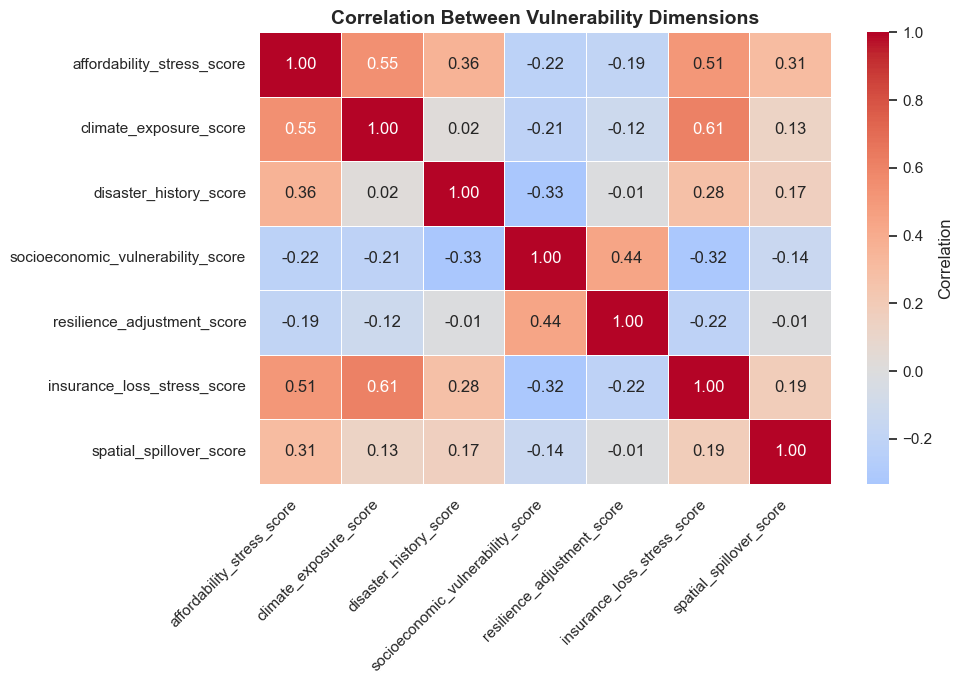

Correlation heatmap saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\clustering_feature_correlation_heatmap.png


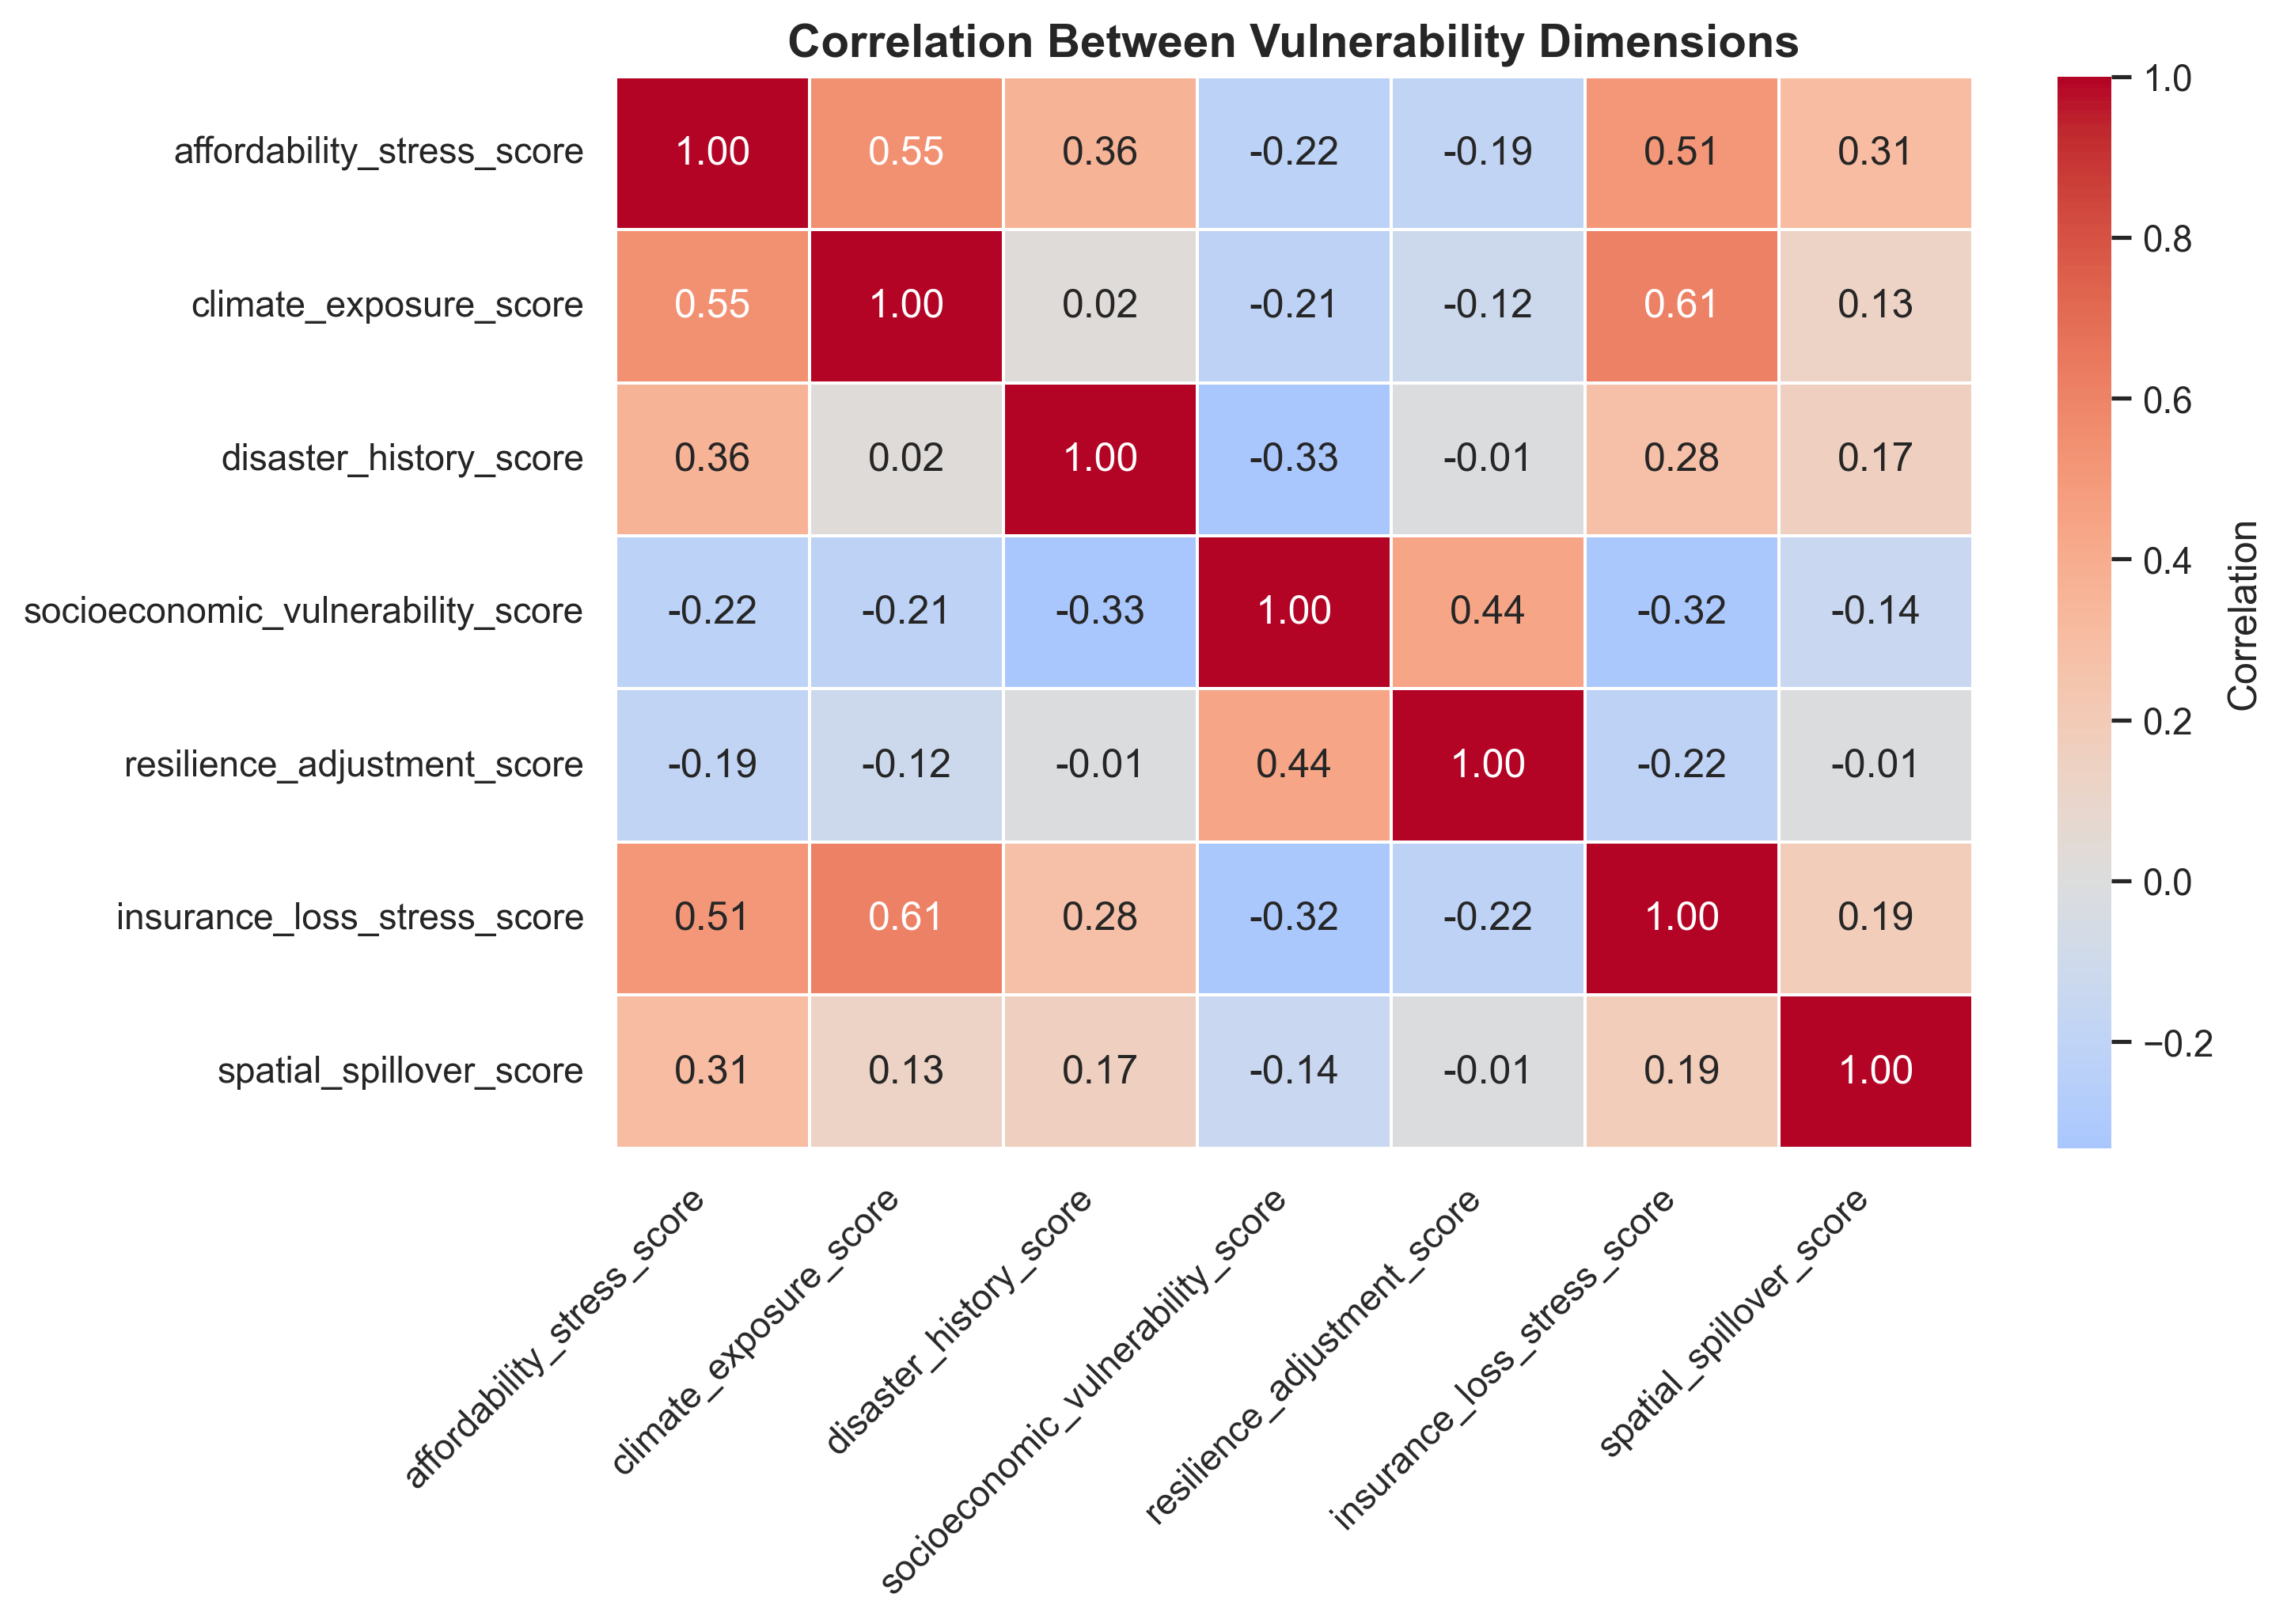

In [5]:
correlation_matrix = clustering_data[CLUSTERING_FEATURES].corr()

display(correlation_matrix.round(3))

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
)

plt.title(
    "Correlation Between Vulnerability Dimensions", fontsize=14, fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

figure_path = RESULTS_FIGURES / "clustering_feature_correlation_heatmap.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Correlation heatmap saved to: {figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "clustering_feature_correlation_heatmap.png"),
        width=850,
    )
)


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(clustering_data[CLUSTERING_FEATURES])

scaled_clustering_data = pd.DataFrame(
    X_scaled, columns=CLUSTERING_FEATURES, index=clustering_data.index
)

standardization_check = pd.DataFrame(
    {
        "mean_after_scaling": scaled_clustering_data.mean(),
        "std_after_scaling": scaled_clustering_data.std(ddof=0),
    }
)

print("Clustering features standardized successfully.")
print(f"Standardized data shape: {scaled_clustering_data.shape}")

display(standardization_check.round(4))


Clustering features standardized successfully.
Standardized data shape: (1000, 7)


,mean_after_scaling,std_after_scaling
affordability_stress_score,-0.0000,1.0000
climate_exposure_score,0.0000,1.0000
disaster_history_score,-0.0000,1.0000
socioeconomic_vulnerability_score,-0.0000,1.0000
resilience_adjustment_score,0.0000,1.0000
insurance_loss_stress_score,0.0000,1.0000
spatial_spillover_score,0.0000,1.0000


## 3. Candidate cluster solutions

K-Means solutions from two through seven clusters are compared using inertia, silhouette, Calinski–Harabasz, Davies–Bouldin, and cluster-size balance. Candidate profile heatmaps are inspected alongside these diagnostics.


In [7]:
cluster_selection_results = []

for k in range(2, 8):
    kmeans_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)

    cluster_labels = kmeans_model.fit_predict(X_scaled)

    cluster_sizes = pd.Series(cluster_labels).value_counts()

    cluster_selection_results.append(
        {
            "n_clusters": k,
            "inertia": kmeans_model.inertia_,
            "silhouette_score": silhouette_score(X_scaled, cluster_labels),
            "calinski_harabasz_score": calinski_harabasz_score(
                X_scaled, cluster_labels
            ),
            "davies_bouldin_score": davies_bouldin_score(X_scaled, cluster_labels),
            "smallest_cluster_size": cluster_sizes.min(),
            "largest_cluster_size": cluster_sizes.max(),
        }
    )

cluster_selection_table = pd.DataFrame(cluster_selection_results)

print("Candidate K-Means solutions evaluated successfully.")

display(cluster_selection_table.round(4))


Candidate K-Means solutions evaluated successfully.


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,2,"5,099.1580",0.2477,372.0301,1.5431,430,570
1,3,"4,494.9744",0.2043,277.8114,1.7997,270,380
2,4,"4,090.5791",0.1865,236.1347,1.6777,171,354
3,5,"3,719.8060",0.1663,219.3524,1.6549,156,243
4,6,"3,463.8803",0.1653,202.9460,1.6074,92,196
5,7,"3,245.7126",0.1706,191.4324,1.6084,87,200


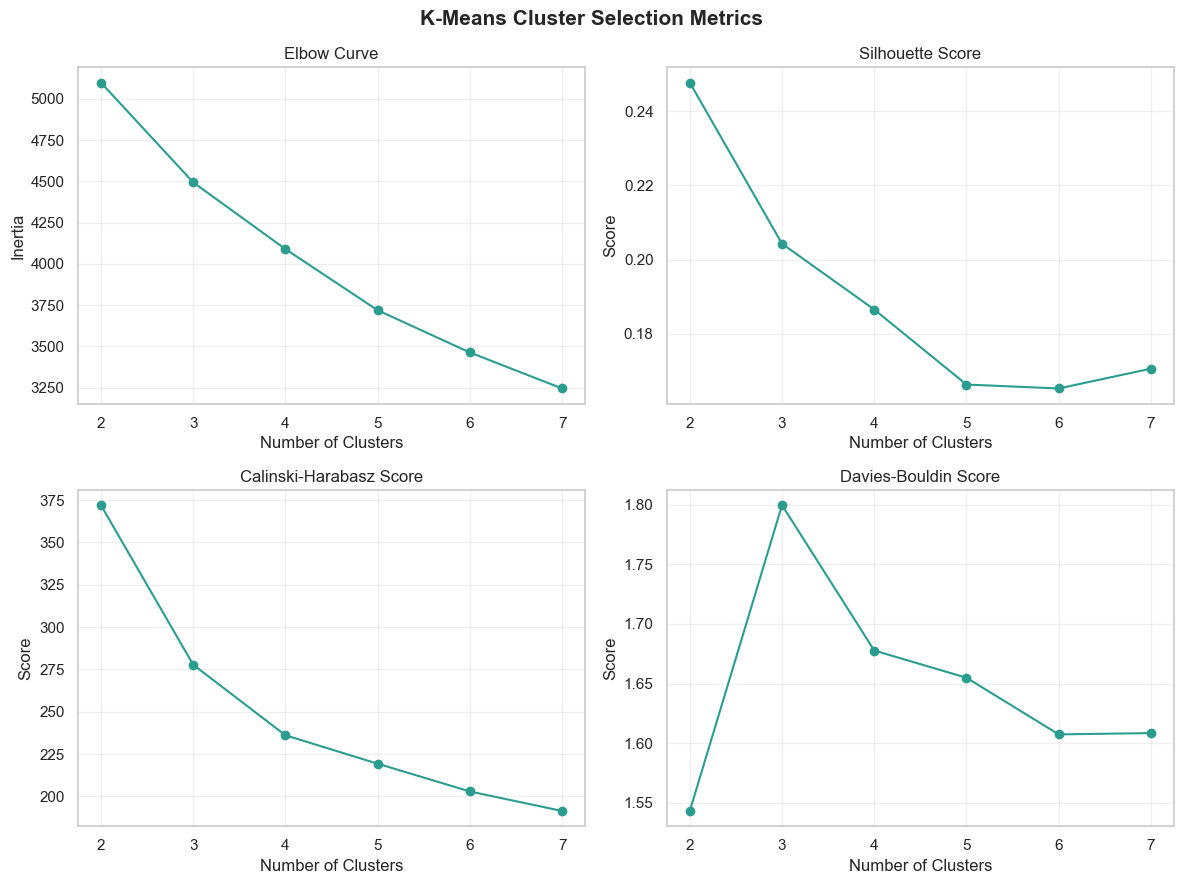

Cluster-selection figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\kmeans_cluster_selection_metrics.png


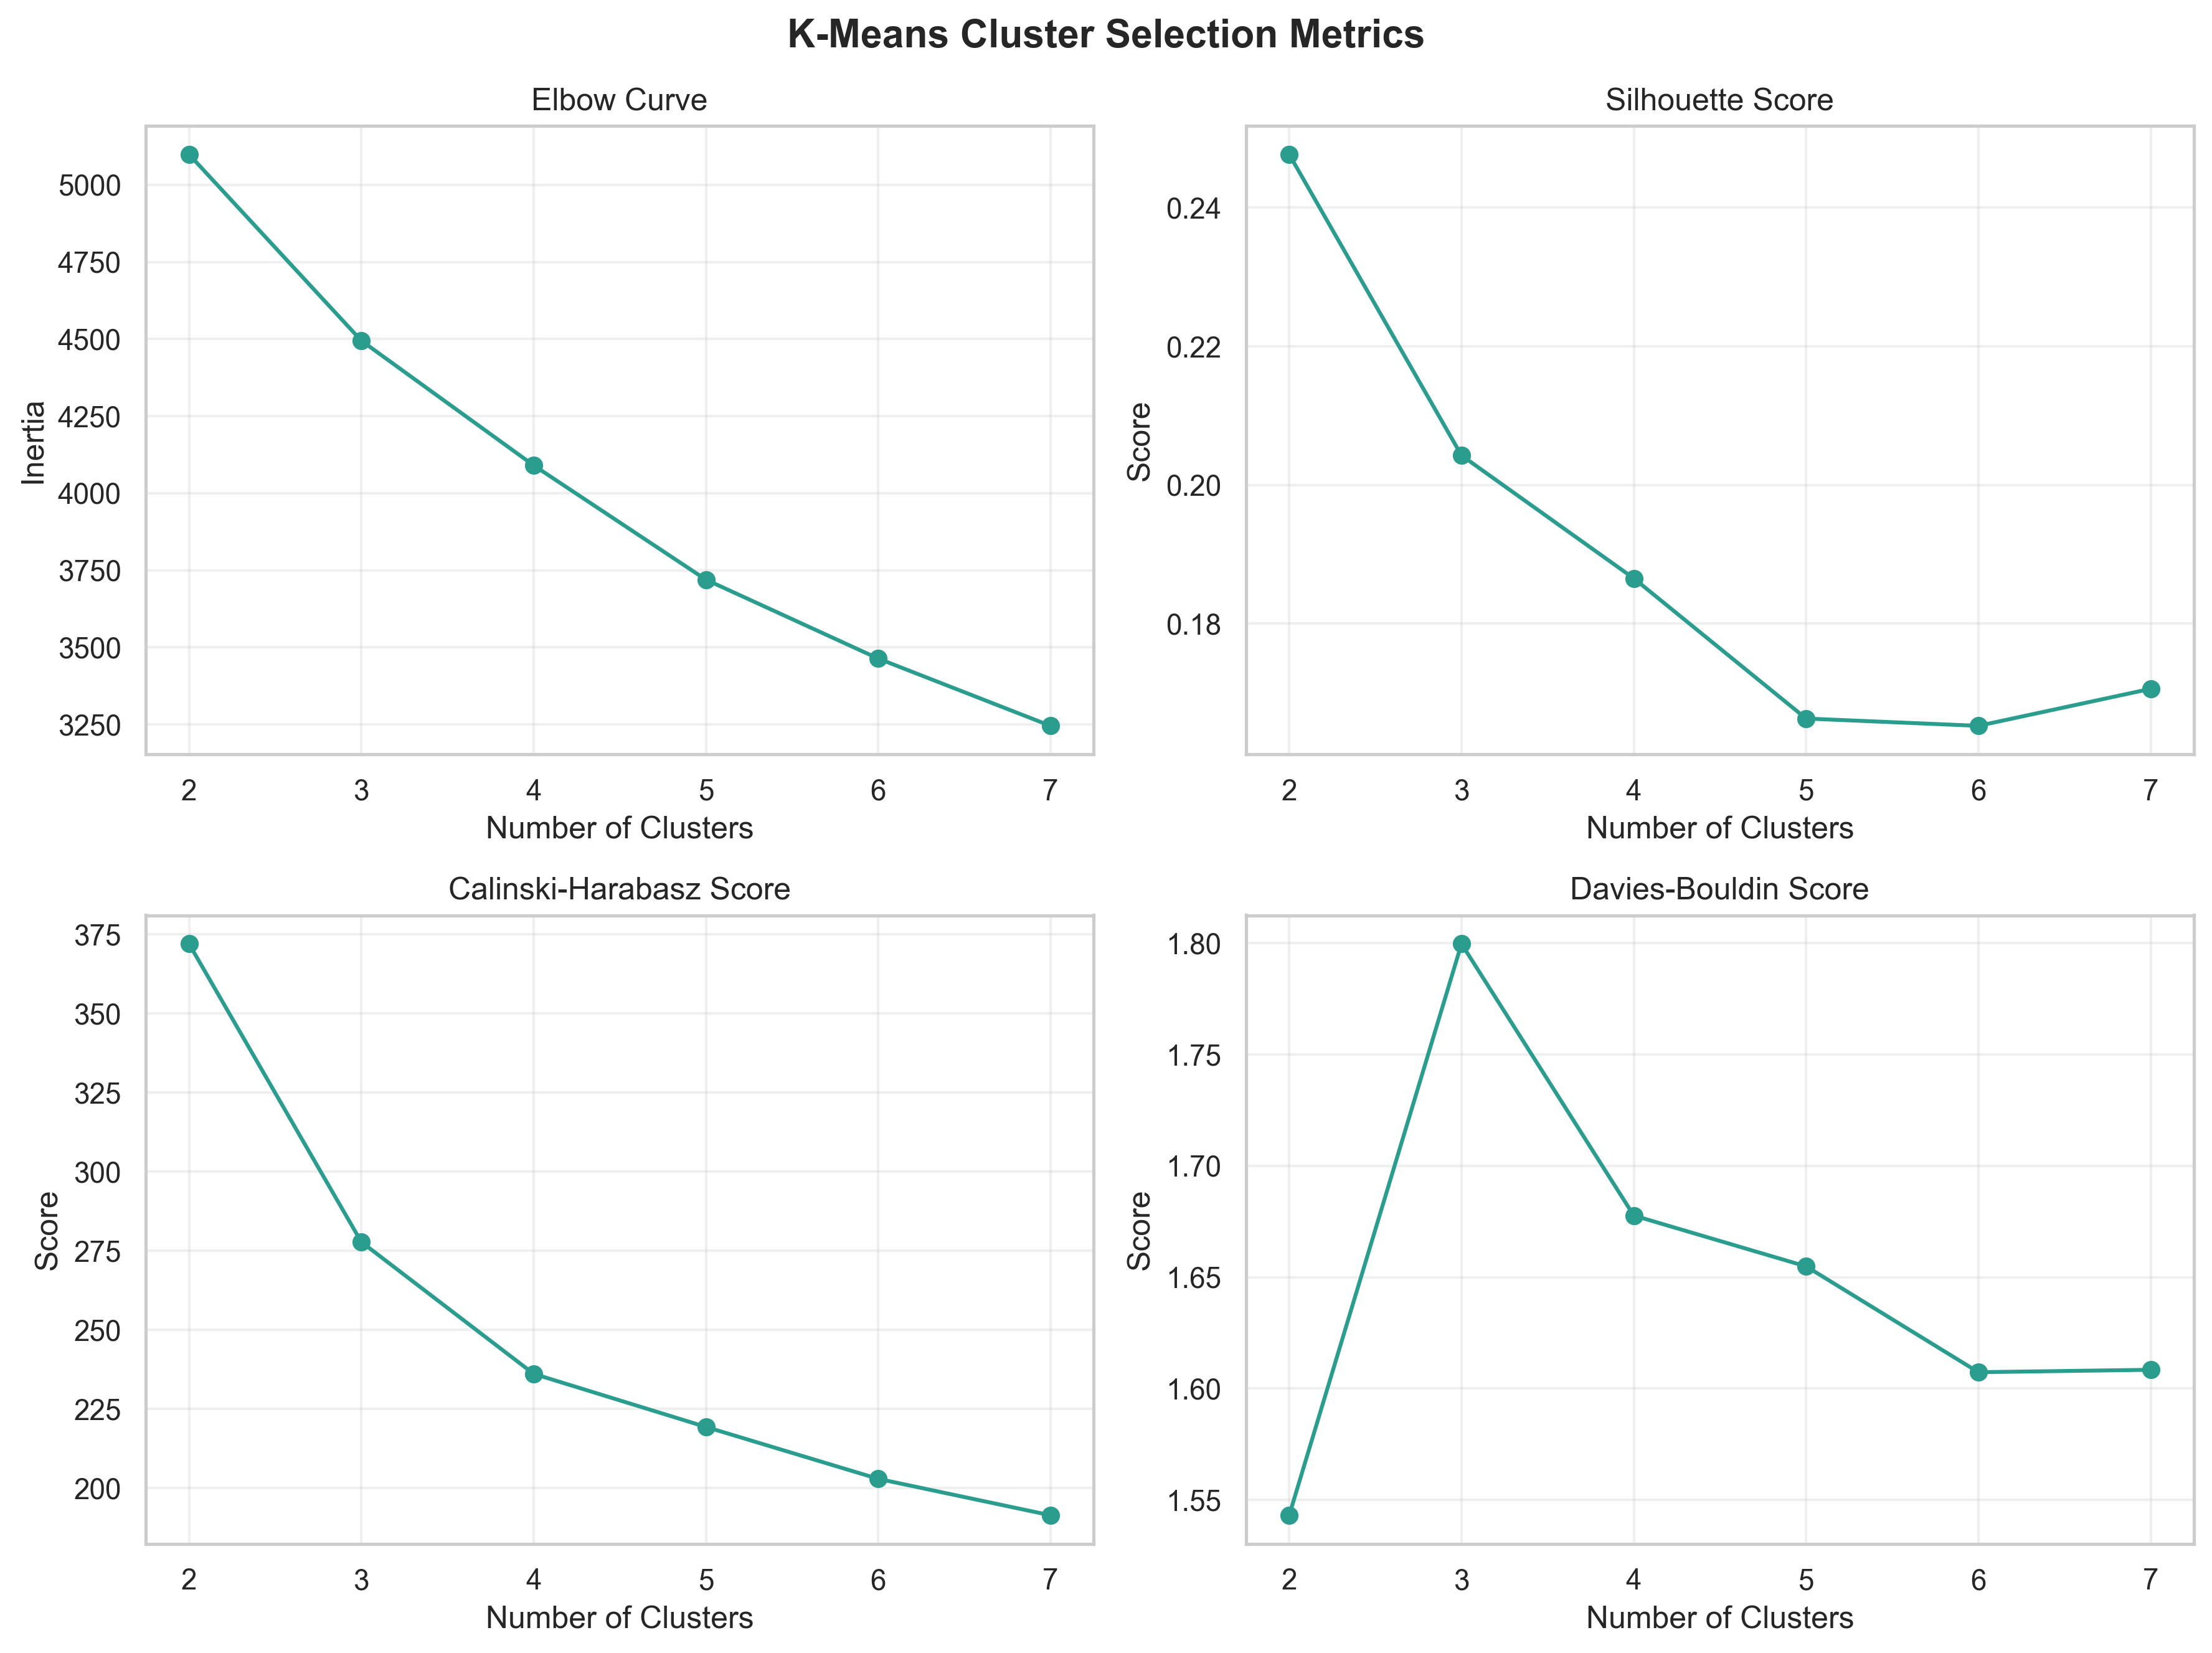

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Elbow curve
axes[0, 0].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["inertia"],
    marker="o",
)

axes[0, 0].set_title("Elbow Curve")
axes[0, 0].set_xlabel("Number of Clusters")
axes[0, 0].set_ylabel("Inertia")

# Silhouette score
axes[0, 1].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["silhouette_score"],
    marker="o",
)

axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("Number of Clusters")
axes[0, 1].set_ylabel("Score")

# Calinski-Harabasz score
axes[1, 0].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["calinski_harabasz_score"],
    marker="o",
)

axes[1, 0].set_title("Calinski-Harabasz Score")
axes[1, 0].set_xlabel("Number of Clusters")
axes[1, 0].set_ylabel("Score")

# Davies-Bouldin score
axes[1, 1].plot(
    cluster_selection_table["n_clusters"],
    cluster_selection_table["davies_bouldin_score"],
    marker="o",
)

axes[1, 1].set_title("Davies-Bouldin Score")
axes[1, 1].set_xlabel("Number of Clusters")
axes[1, 1].set_ylabel("Score")

for axis in axes.flat:
    axis.set_xticks(cluster_selection_table["n_clusters"])
    axis.grid(alpha=0.3)

plt.suptitle("K-Means Cluster Selection Metrics", fontsize=15, fontweight="bold")

plt.tight_layout()

figure_path = RESULTS_FIGURES / "kmeans_cluster_selection_metrics.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Cluster-selection figure saved to: {figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "kmeans_cluster_selection_metrics.png"),
        width=850,
    )
)


In [9]:
candidate_models = {}
candidate_labels = {}
candidate_profile_tables = {}
candidate_size_tables = {}

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)

    labels = model.fit_predict(X_scaled)

    candidate_models[k] = model
    candidate_labels[k] = labels

    profile_data = scaled_clustering_data.copy()
    profile_data["cluster"] = labels

    cluster_profiles = (
        profile_data.groupby("cluster")[CLUSTERING_FEATURES].mean().round(3)
    )

    cluster_sizes = (
        pd.Series(labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename("cluster_size")
        .to_frame()
    )

    cluster_sizes["cluster_share_pct"] = (
        cluster_sizes["cluster_size"] / len(labels) * 100
    ).round(2)

    candidate_profile_tables[k] = cluster_profiles
    candidate_size_tables[k] = cluster_sizes

for k in [2, 3, 4]:
    print(f"\n{k}-Cluster Solution")
    print("-" * 40)

    print("Cluster sizes")
    display(candidate_size_tables[k])

    print("Average standardized profiles")
    display(candidate_profile_tables[k])



2-Cluster Solution
----------------------------------------
Cluster sizes


,cluster_size,cluster_share_pct
cluster,,
0,570,57.0000
1,430,43.0000


Average standardized profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,0.5470,0.6210,0.2050,-0.4150,-0.3450,0.6040,0.2250
1,-0.7260,-0.8230,-0.2710,0.5500,0.4570,-0.8010,-0.2980



3-Cluster Solution
----------------------------------------
Cluster sizes


...

,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,0.8580,0.8150,0.4860,-0.2470,0.1130,0.8140,0.4280
1,-0.7560,-0.7810,-0.2400,0.6950,0.7020,-0.8020,-0.2590
2,-0.0490,0.0430,-0.2930,-0.6580,-1.1340,0.0730,-0.1900



4-Cluster Solution
----------------------------------------
Cluster sizes


,cluster_size,cluster_share_pct
cluster,,
0,354,35.4000
1,171,17.1000
2,284,28.4000
3,191,19.1000


Average standardized profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster,,,,,,,
0,-0.7680,-0.8650,-0.2340,0.7080,0.6840,-0.8870,-0.2820
1,-0.1780,-0.2300,-0.1550,-1.0610,-1.3830,-0.0480,-0.1190
2,0.3410,0.8630,-0.4860,0.0950,0.0560,0.5250,0.2360
3,1.0770,0.5250,1.2950,-0.5030,-0.1130,0.9060,0.2780


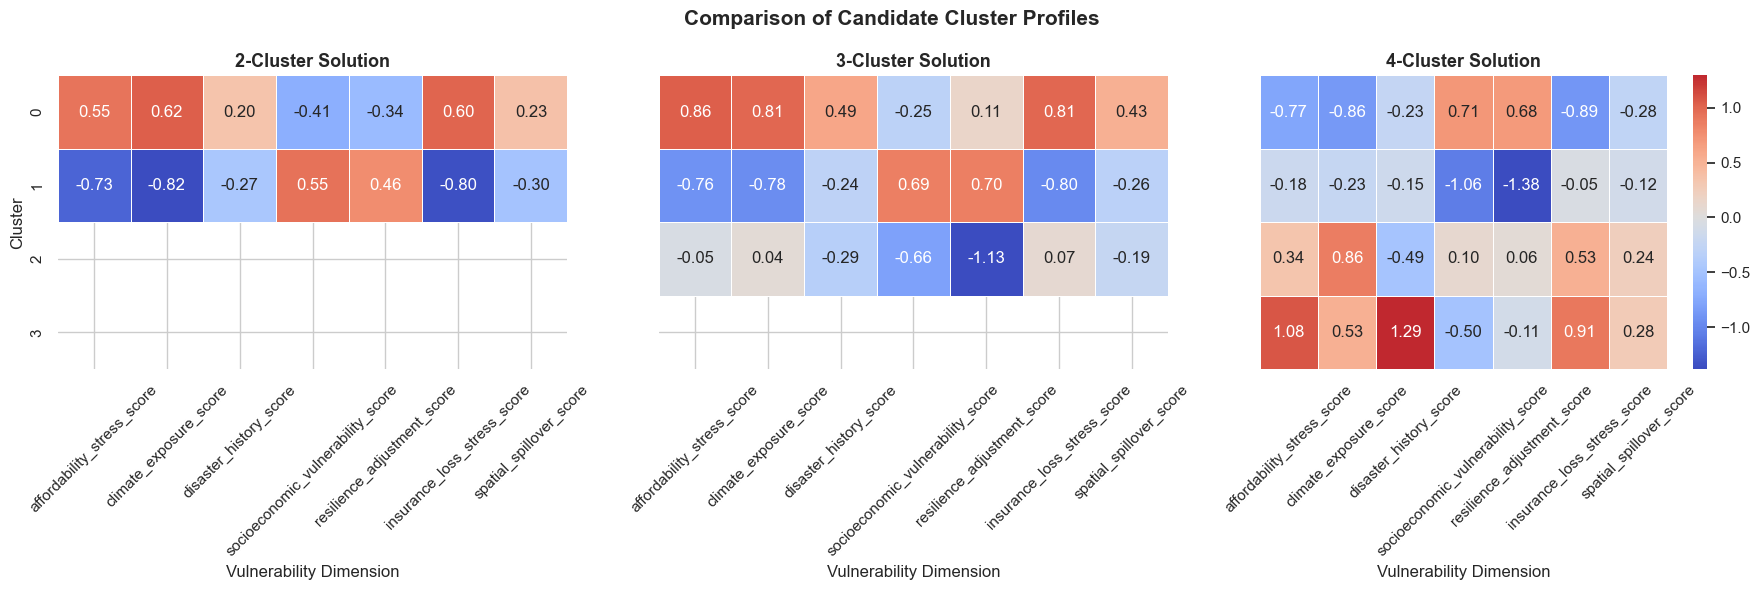

Candidate cluster profile figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\candidate_cluster_profile_heatmaps.png


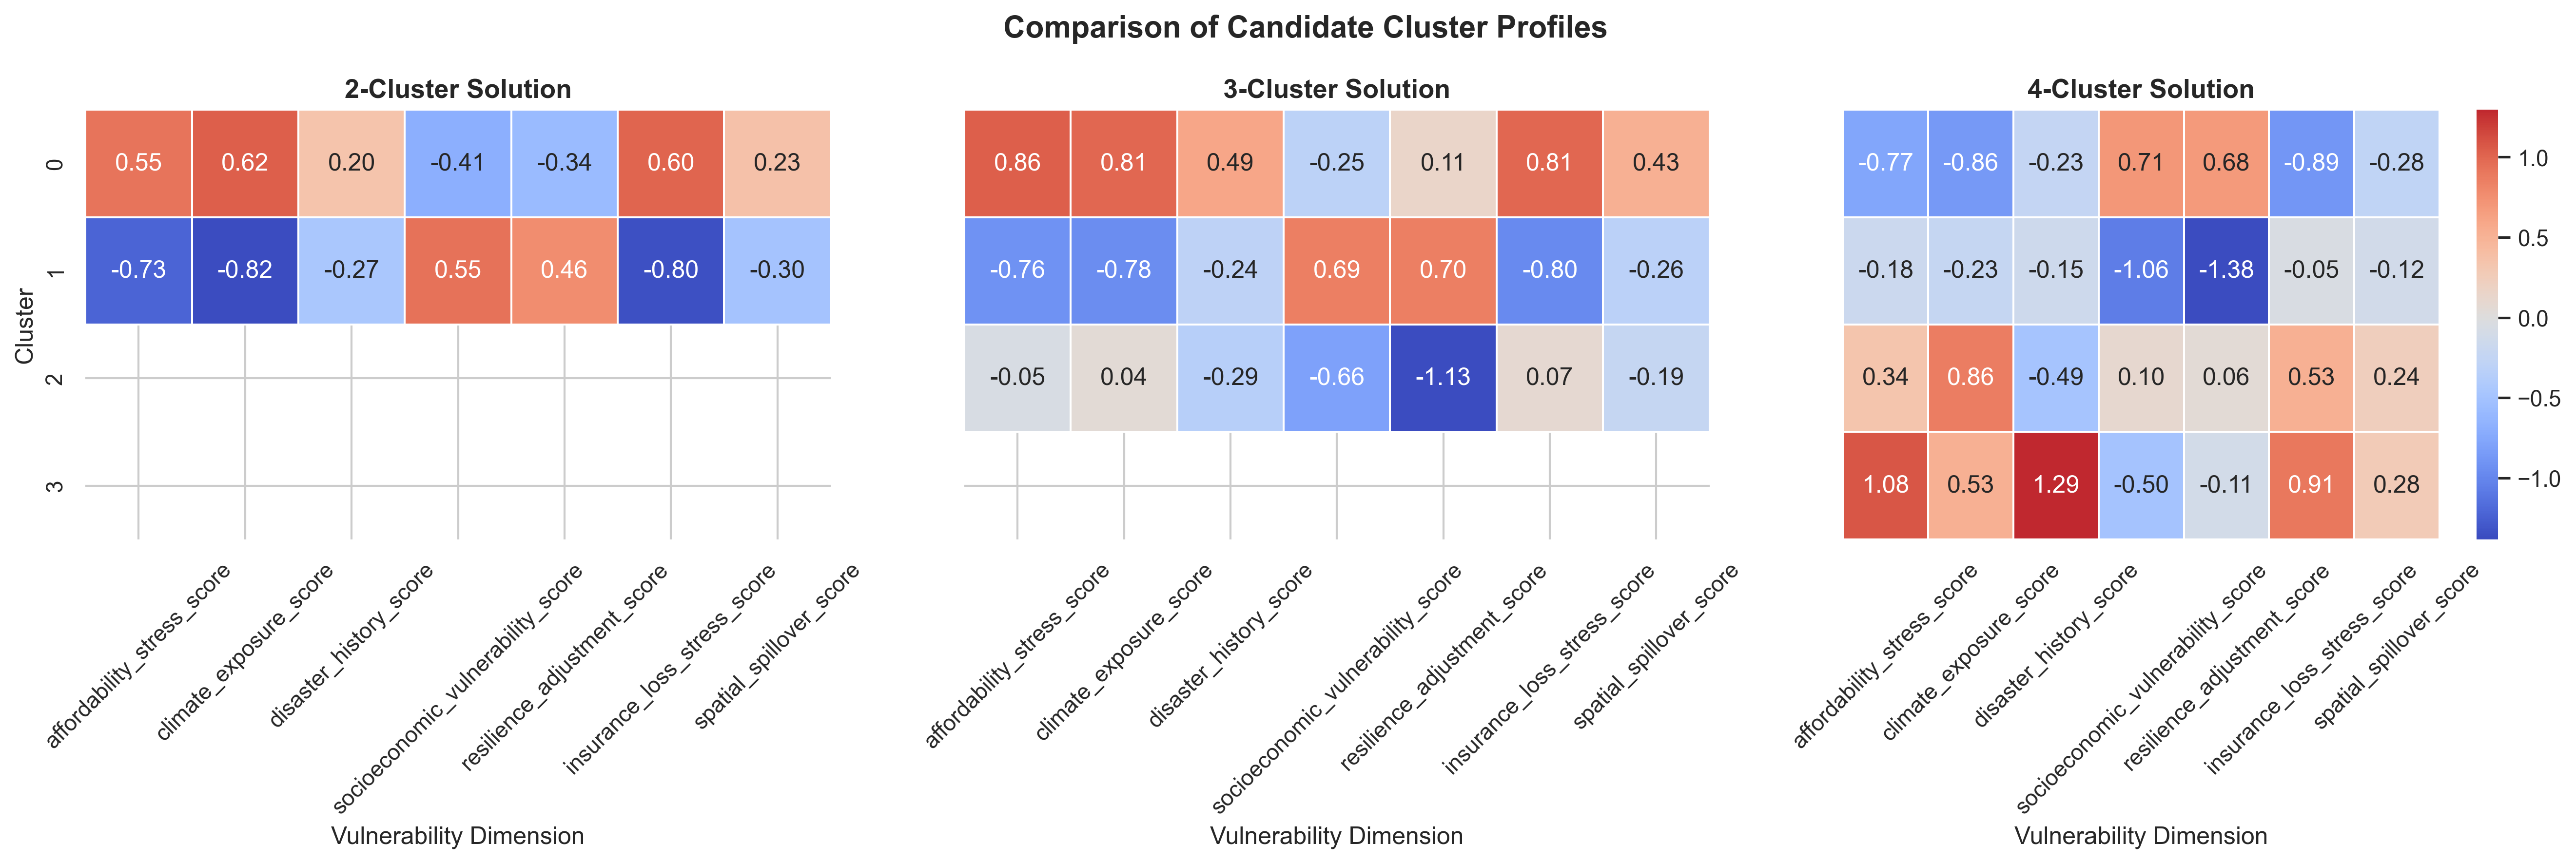

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for axis, k in zip(axes, [2, 3, 4]):
    sns.heatmap(
        candidate_profile_tables[k],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=k == 4,
        ax=axis,
    )

    axis.set_title(f"{k}-Cluster Solution", fontsize=13, fontweight="bold")

    axis.set_xlabel("Vulnerability Dimension")
    axis.set_ylabel("Cluster" if k == 2 else "")
    axis.tick_params(axis="x", rotation=45)

plt.suptitle("Comparison of Candidate Cluster Profiles", fontsize=15, fontweight="bold")

plt.tight_layout()

figure_path = RESULTS_FIGURES / "candidate_cluster_profile_heatmaps.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Candidate cluster profile figure saved to: {figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "candidate_cluster_profile_heatmaps.png"),
        width=850,
    )
)


## 4. Final four-profile solution

The two-cluster solution has the strongest silhouette score, but it collapses substantively different vulnerability forms. Four clusters are retained to distinguish interpretable profiles while maintaining adequate group sizes. K-Means is then compared with four-component Gaussian Mixture and Ward agglomerative solutions, and sensitivity to alternative random seeds is recorded. Because raw K-Means labels are arbitrary, final IDs are canonicalized from their fitted feature profiles before descriptive names are attached.


In [11]:
FINAL_N_CLUSTERS = 4

final_kmeans_model = KMeans(
    n_clusters=FINAL_N_CLUSTERS, random_state=RANDOM_STATE, n_init=50
)

raw_cluster_labels = final_kmeans_model.fit_predict(X_scaled)

# K-Means labels are arbitrary and can be permuted across scikit-learn versions.
# Canonicalize them from the fitted feature profiles before attaching names.
raw_cluster_profiles = pd.DataFrame(
    final_kmeans_model.cluster_centers_,
    columns=CLUSTERING_FEATURES,
)
remaining_raw_ids = set(range(FINAL_N_CLUSTERS))

disaster_raw_id = raw_cluster_profiles.loc[
    list(remaining_raw_ids), "disaster_history_score"
].idxmax()
remaining_raw_ids.remove(disaster_raw_id)

exposure_raw_id = raw_cluster_profiles.loc[
    list(remaining_raw_ids), "climate_exposure_score"
].idxmax()
remaining_raw_ids.remove(exposure_raw_id)

socioeconomic_raw_id = raw_cluster_profiles.loc[
    list(remaining_raw_ids), "socioeconomic_vulnerability_score"
].idxmax()
remaining_raw_ids.remove(socioeconomic_raw_id)

lower_stress_raw_id = remaining_raw_ids.pop()
canonical_raw_order = [
    lower_stress_raw_id,
    disaster_raw_id,
    exposure_raw_id,
    socioeconomic_raw_id,
]
raw_to_canonical = {
    raw_id: canonical_id for canonical_id, raw_id in enumerate(canonical_raw_order)
}
final_cluster_labels = np.array(
    [raw_to_canonical[label] for label in raw_cluster_labels], dtype=int
)

# Reorder the estimator's centers so future predict() calls return canonical IDs.
final_kmeans_model.cluster_centers_ = final_kmeans_model.cluster_centers_[
    canonical_raw_order
]


clustered_data = county_year_data.copy()
clustered_data["cluster_id"] = final_cluster_labels

final_cluster_sizes = (
    clustered_data["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("cluster_size")
    .to_frame()
)

final_cluster_sizes["cluster_share_pct"] = (
    final_cluster_sizes["cluster_size"] / len(clustered_data) * 100
).round(2)

final_cluster_profiles = (
    scaled_clustering_data.assign(cluster_id=final_cluster_labels)
    .groupby("cluster_id")[CLUSTERING_FEATURES]
    .mean()
    .round(3)
)

print("Final K-Means model fitted successfully.")
print(f"Selected number of clusters: {FINAL_N_CLUSTERS}")
print(f"Total clustered observations: {len(clustered_data):,}")

print("\nFinal cluster sizes")
display(final_cluster_sizes)

print("Final standardized cluster profiles")
display(final_cluster_profiles)


Final K-Means model fitted successfully.
Selected number of clusters: 4
Total clustered observations: 1,000

Final cluster sizes


,cluster_size,cluster_share_pct
cluster_id,,
0,171,17.1000
1,191,19.1000
2,284,28.4000
3,354,35.4000


Final standardized cluster profiles


,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score
cluster_id,,,,,,,
0,-0.1780,-0.2300,-0.1550,-1.0610,-1.3830,-0.0480,-0.1190
1,1.0770,0.5250,1.2950,-0.5030,-0.1130,0.9060,0.2780
2,0.3410,0.8630,-0.4860,0.0950,0.0560,0.5250,0.2360
3,-0.7680,-0.8650,-0.2340,0.7080,0.6840,-0.8870,-0.2820


In [12]:
algorithm_comparison_results = []
algorithm_labels = {}

# K-Means

kmeans_labels = final_cluster_labels

algorithm_labels["K-Means"] = kmeans_labels

algorithm_comparison_results.append(
    {
        "algorithm": "K-Means",
        "silhouette_score": silhouette_score(X_scaled, kmeans_labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_scaled, kmeans_labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, kmeans_labels),
        "smallest_cluster_size": (pd.Series(kmeans_labels).value_counts().min()),
        "largest_cluster_size": (pd.Series(kmeans_labels).value_counts().max()),
    }
)

# Gaussian Mixture Model

gmm_model = GaussianMixture(
    n_components=FINAL_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
    covariance_type="full",
)

gmm_labels = gmm_model.fit_predict(X_scaled)

algorithm_labels["Gaussian Mixture"] = gmm_labels

algorithm_comparison_results.append(
    {
        "algorithm": "Gaussian Mixture",
        "silhouette_score": silhouette_score(X_scaled, gmm_labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_scaled, gmm_labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, gmm_labels),
        "smallest_cluster_size": (pd.Series(gmm_labels).value_counts().min()),
        "largest_cluster_size": (pd.Series(gmm_labels).value_counts().max()),
    }
)

# Agglomerative Clustering

agglomerative_model = AgglomerativeClustering(
    n_clusters=FINAL_N_CLUSTERS, linkage="ward"
)

agglomerative_labels = agglomerative_model.fit_predict(X_scaled)

algorithm_labels["Agglomerative"] = agglomerative_labels

algorithm_comparison_results.append(
    {
        "algorithm": "Agglomerative",
        "silhouette_score": silhouette_score(X_scaled, agglomerative_labels),
        "calinski_harabasz_score": calinski_harabasz_score(
            X_scaled, agglomerative_labels
        ),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, agglomerative_labels),
        "smallest_cluster_size": (pd.Series(agglomerative_labels).value_counts().min()),
        "largest_cluster_size": (pd.Series(agglomerative_labels).value_counts().max()),
    }
)

algorithm_comparison_table = pd.DataFrame(algorithm_comparison_results)

print("Clustering algorithms compared successfully.")

display(algorithm_comparison_table.round(4))


Clustering algorithms compared successfully.


,algorithm,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,K-Means,0.1865,236.1347,1.6777,171,354
1,Gaussian Mixture,0.1172,178.8036,2.1404,215,288
2,Agglomerative,0.1468,176.7855,2.0035,91,419


In [13]:
stability_results = []

test_seeds = [0, 1, 7, 21, 42, 99, 123]

for seed in test_seeds:
    stability_model = KMeans(n_clusters=FINAL_N_CLUSTERS, random_state=seed, n_init=50)

    stability_labels = stability_model.fit_predict(X_scaled)

    stability_results.append(
        {
            "random_state": seed,
            "adjusted_rand_index": adjusted_rand_score(
                final_cluster_labels, stability_labels
            ),
        }
    )

cluster_stability_table = pd.DataFrame(stability_results)

print("Cluster stability check completed.")

display(cluster_stability_table.round(4))

cluster_stability_table.to_csv(
    RESULTS_TABLES / "cluster_stability_results.csv", index=False
)


Cluster stability check completed.


,random_state,adjusted_rand_index
0,0,0.9778
1,1,1.0000
2,7,1.0000
3,21,1.0000
4,42,1.0000
5,99,1.0000
6,123,0.9695


In [14]:
numeric_profiling_features = [
    feature
    for feature in available_profiling_features
    if feature != "vulnerability_class"
    and pd.api.types.is_numeric_dtype(clustered_data[feature])
]

cluster_profile_features = CLUSTERING_FEATURES + numeric_profiling_features

final_cluster_profile_table = (
    clustered_data.groupby("cluster_id")[cluster_profile_features].mean().round(4)
)

final_cluster_profile_table.insert(
    0, "cluster_size", final_cluster_sizes["cluster_size"]
)

final_cluster_profile_table.insert(
    1, "cluster_share_pct", final_cluster_sizes["cluster_share_pct"]
)

print("Final cluster profiles created successfully.")

display(final_cluster_profile_table)

final_cluster_profile_table.to_csv(RESULTS_TABLES / "final_cluster_profiles.csv")

print(
    "Cluster profile table saved to: "
    f"{RESULTS_TABLES / 'final_cluster_profiles.csv'}"
)


Final cluster profiles created successfully.


,cluster_size,cluster_share_pct,affordability_stress_score,climate_exposure_score,disaster_history_score,socioeconomic_vulnerability_score,resilience_adjustment_score,insurance_loss_stress_score,spatial_spillover_score,housing_pressure_score,annual_price_growth_pct,annual_price_volatility,avg_annual_housing_price,climate_housing_vulnerability_score
cluster_id,,,,,,,,,,,,,,
0,171,17.1000,0.4887,0.5624,0.2111,0.2824,0.3376,0.4269,0.4471,0.4381,4.2145,"5,142.7756","243,655.6336",0.3993
1,191,19.1000,0.5841,0.7583,0.5406,0.3535,0.6417,0.6524,0.5468,0.5368,8.9546,"9,132.9513","352,240.1625",0.5768
2,284,28.4000,0.5282,0.8463,0.1361,0.4296,0.6821,0.5623,0.5364,0.4639,7.0468,"5,951.1893","203,770.0468",0.5231
3,354,35.4000,0.4439,0.3975,0.1933,0.5077,0.8324,0.2287,0.4058,0.4225,5.1941,"3,378.7737","138,267.9764",0.4290


Cluster profile table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering\final_cluster_profiles.csv


In [15]:
CLUSTER_NAMES = {
    0: "Lower-Stress Resilient Profile",
    1: "Disaster-Loss Growth Pressure",
    2: "High-Exposure Latent Risk",
    3: "Socioeconomic Resilience Stress",
}

clustered_data["cluster_name"] = clustered_data["cluster_id"].map(CLUSTER_NAMES)

cluster_name_table = (
    clustered_data[["cluster_id", "cluster_name"]]
    .drop_duplicates()
    .sort_values("cluster_id")
    .merge(final_cluster_sizes.reset_index(), on="cluster_id", how="left")
)

print("Descriptive cluster names assigned successfully.")

display(cluster_name_table)

cluster_name_table.to_csv(RESULTS_TABLES / "cluster_name_mapping.csv", index=False)

print(
    "Cluster name mapping saved to: " f"{RESULTS_TABLES / 'cluster_name_mapping.csv'}"
)


Descriptive cluster names assigned successfully.


,cluster_id,cluster_name,cluster_size,cluster_share_pct
0,0,Lower-Stress Resilient Profile,171,17.1000
1,1,Disaster-Loss Growth Pressure,191,19.1000
2,2,High-Exposure Latent Risk,284,28.4000
3,3,Socioeconomic Resilience Stress,354,35.4000


Cluster name mapping saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering\cluster_name_mapping.csv


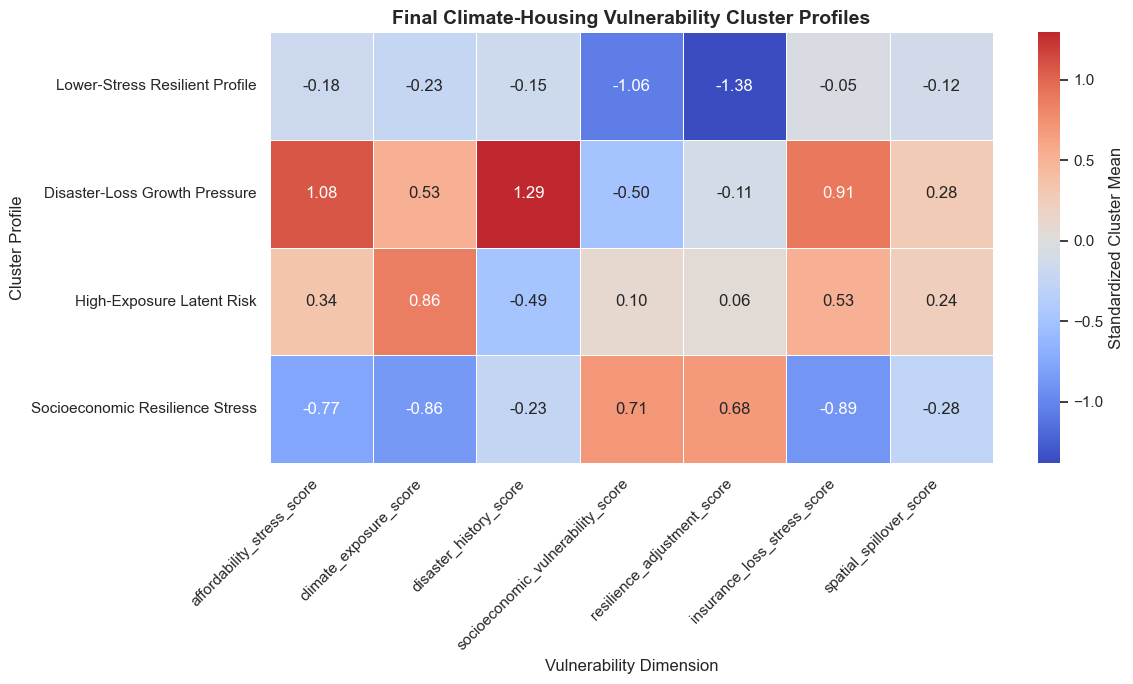

Final cluster profile heatmap saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\final_cluster_profile_heatmap.png


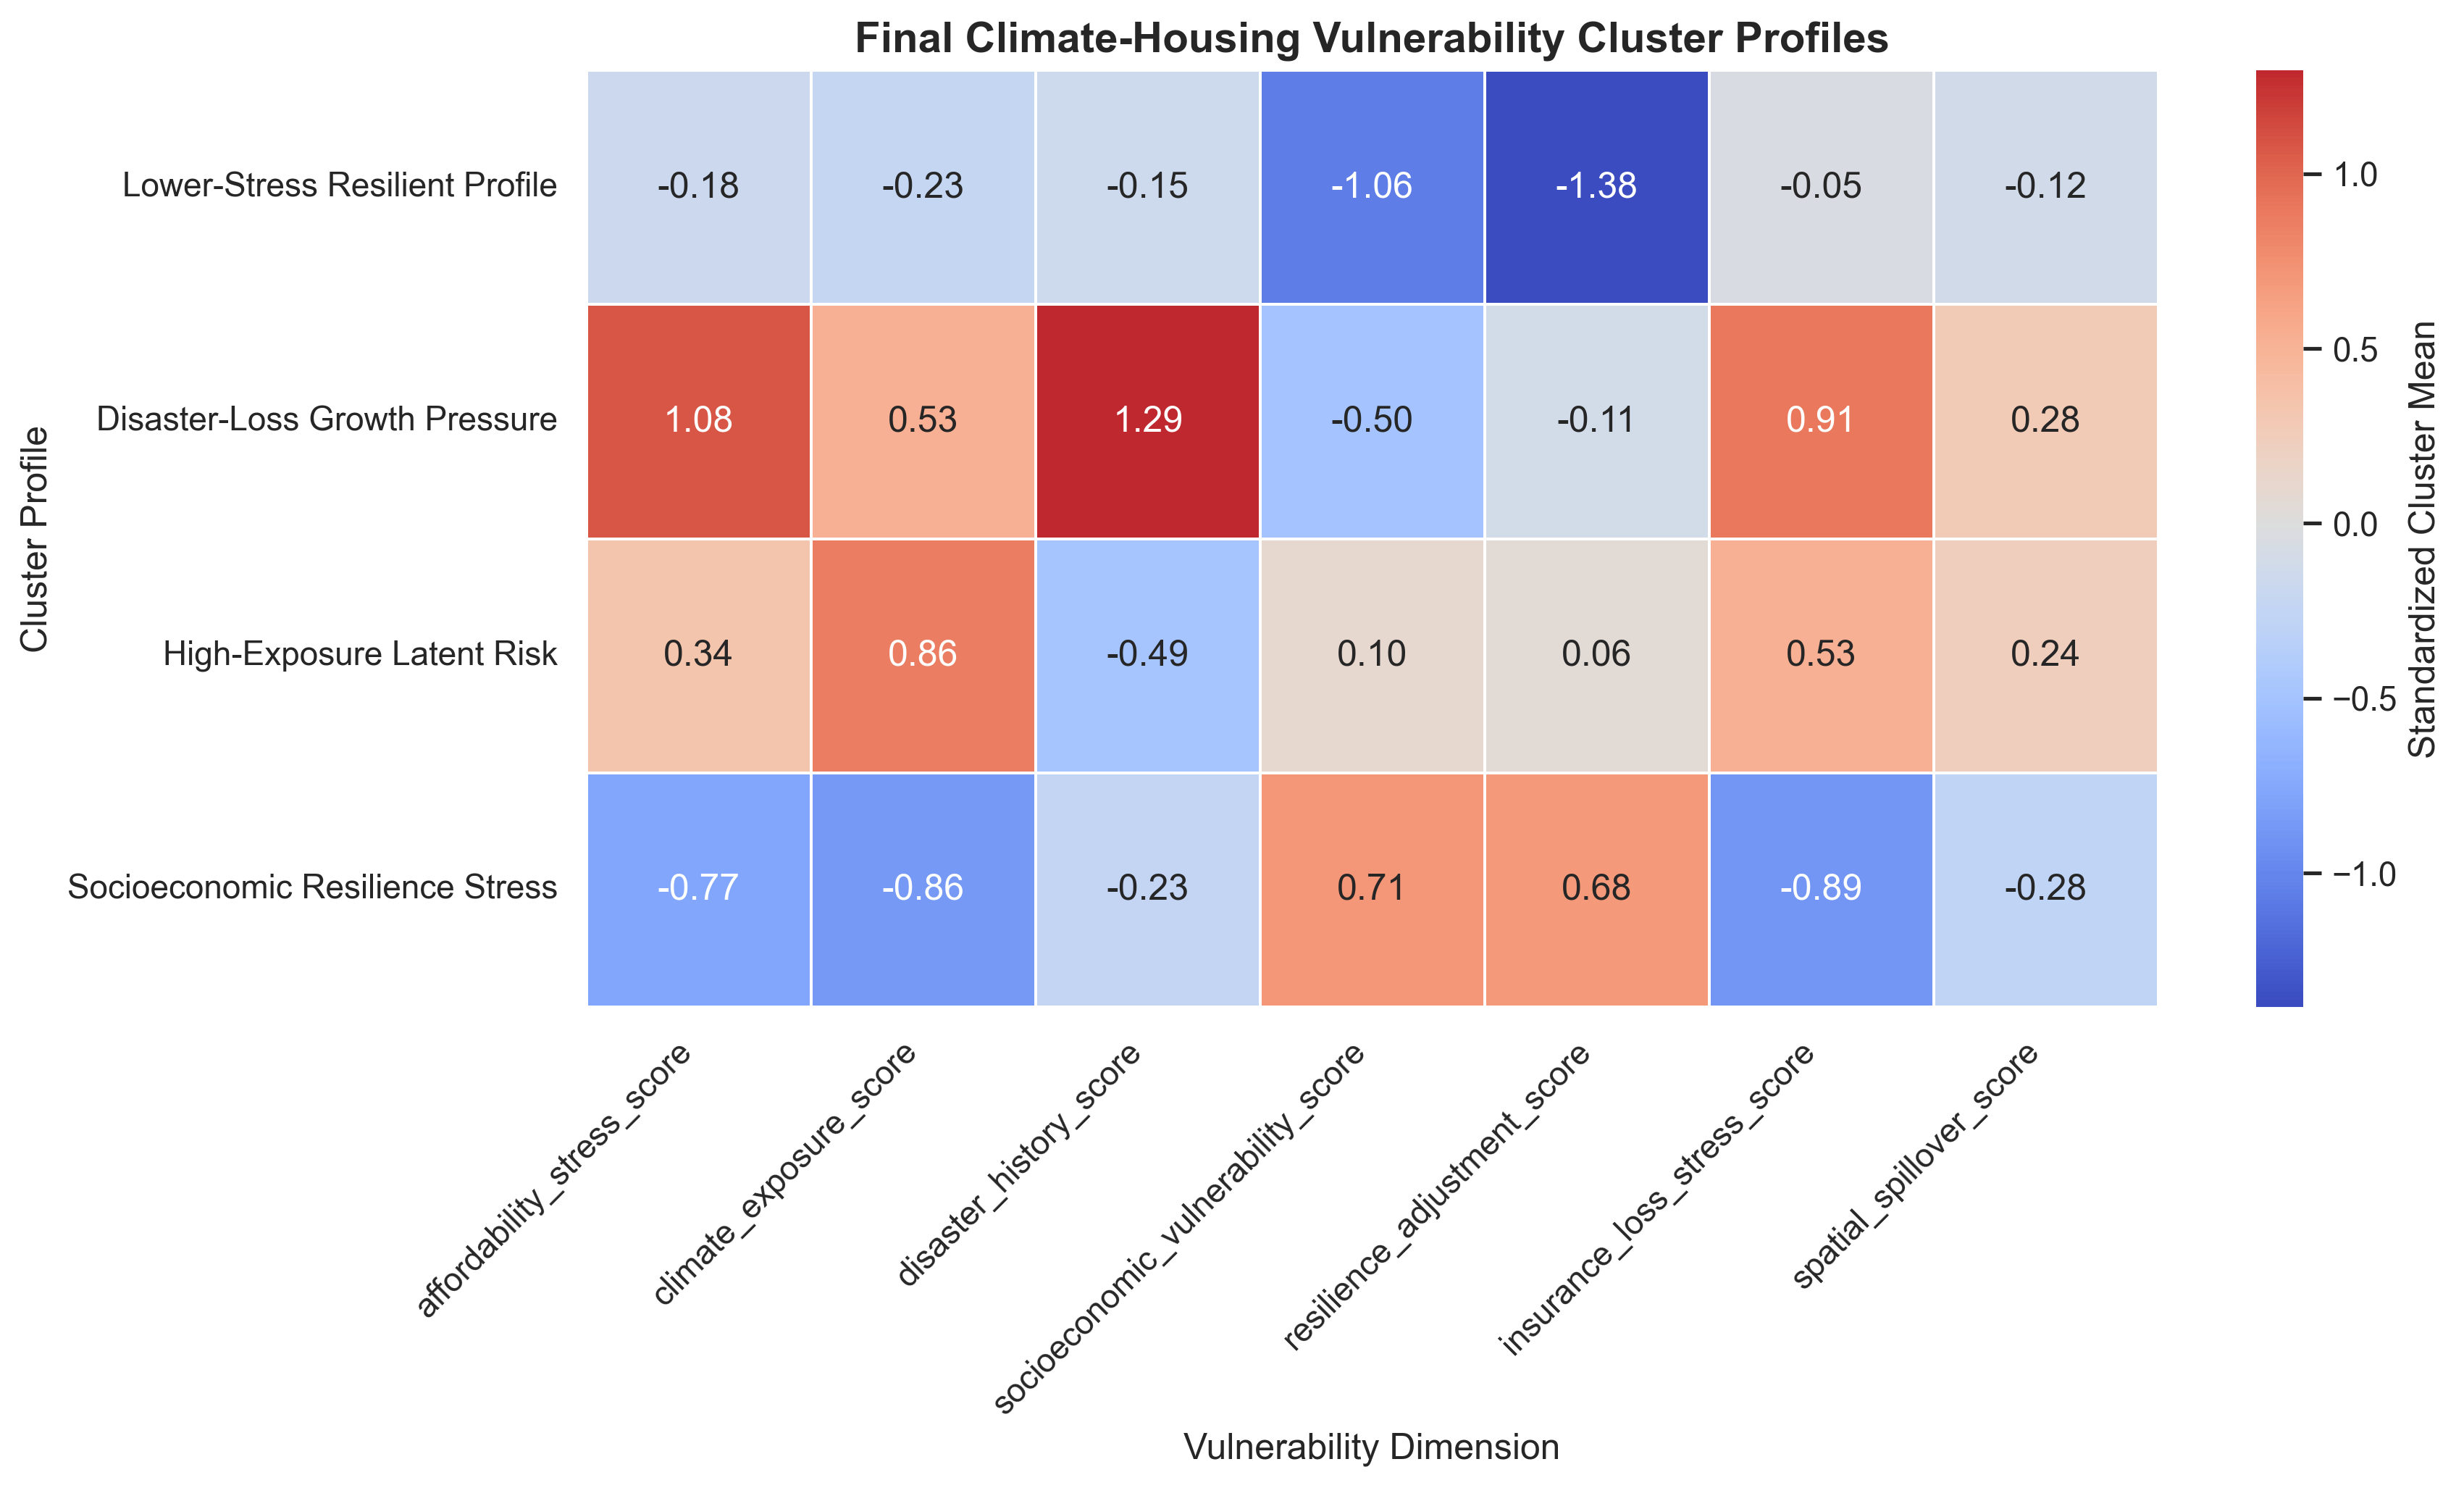

In [16]:
named_cluster_profiles = final_cluster_profiles.copy()

named_cluster_profiles.index = named_cluster_profiles.index.map(CLUSTER_NAMES)

plt.figure(figsize=(12, 7))

sns.heatmap(
    named_cluster_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Cluster Mean"},
)

plt.title(
    "Final Climate-Housing Vulnerability Cluster Profiles",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Vulnerability Dimension")
plt.ylabel("Cluster Profile")

plt.xticks(rotation=45, ha="right")

plt.yticks(rotation=0)

plt.tight_layout()

figure_path = RESULTS_FIGURES / "final_cluster_profile_heatmap.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Final cluster profile heatmap saved to: " f"{figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "final_cluster_profile_heatmap.png"), width=850
    )
)


## 5. Interpret the four profiles

Cluster profiles are compared with housing-market conditions and the constructed vulnerability classes. The class composition is descriptive: clusters are generated without using either housing outcomes or the final Low/Medium/High label.


Housing-market conditions compared successfully.


,avg_annual_growth_pct,avg_housing_pressure_score,avg_annual_housing_price,avg_price_volatility_pct
cluster_name,,,,
Lower-Stress Resilient Profile,4.2145,0.4381,"243,655.6336",2.0920
Disaster-Loss Growth Pressure,8.9546,0.5368,"352,240.1625",2.5797
High-Exposure Latent Risk,7.0468,0.4639,"203,770.0468",2.8822
Socioeconomic Resilience Stress,5.1941,0.4225,"138,267.9764",2.3468


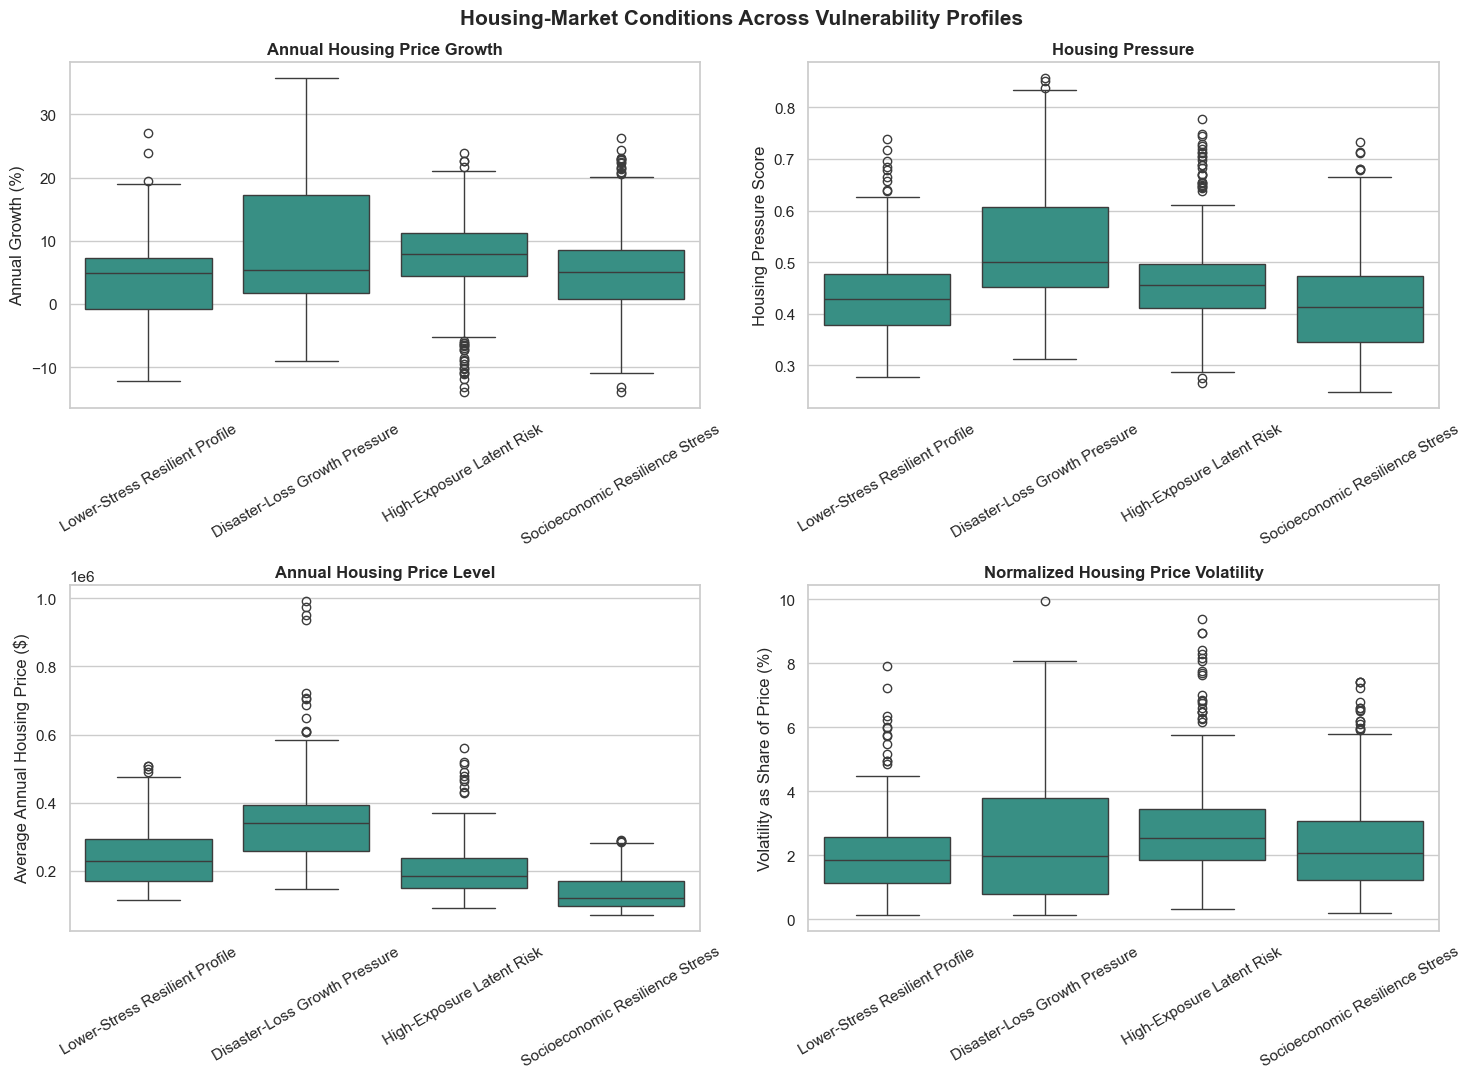

Housing-market comparison figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\housing_market_conditions_by_cluster.png


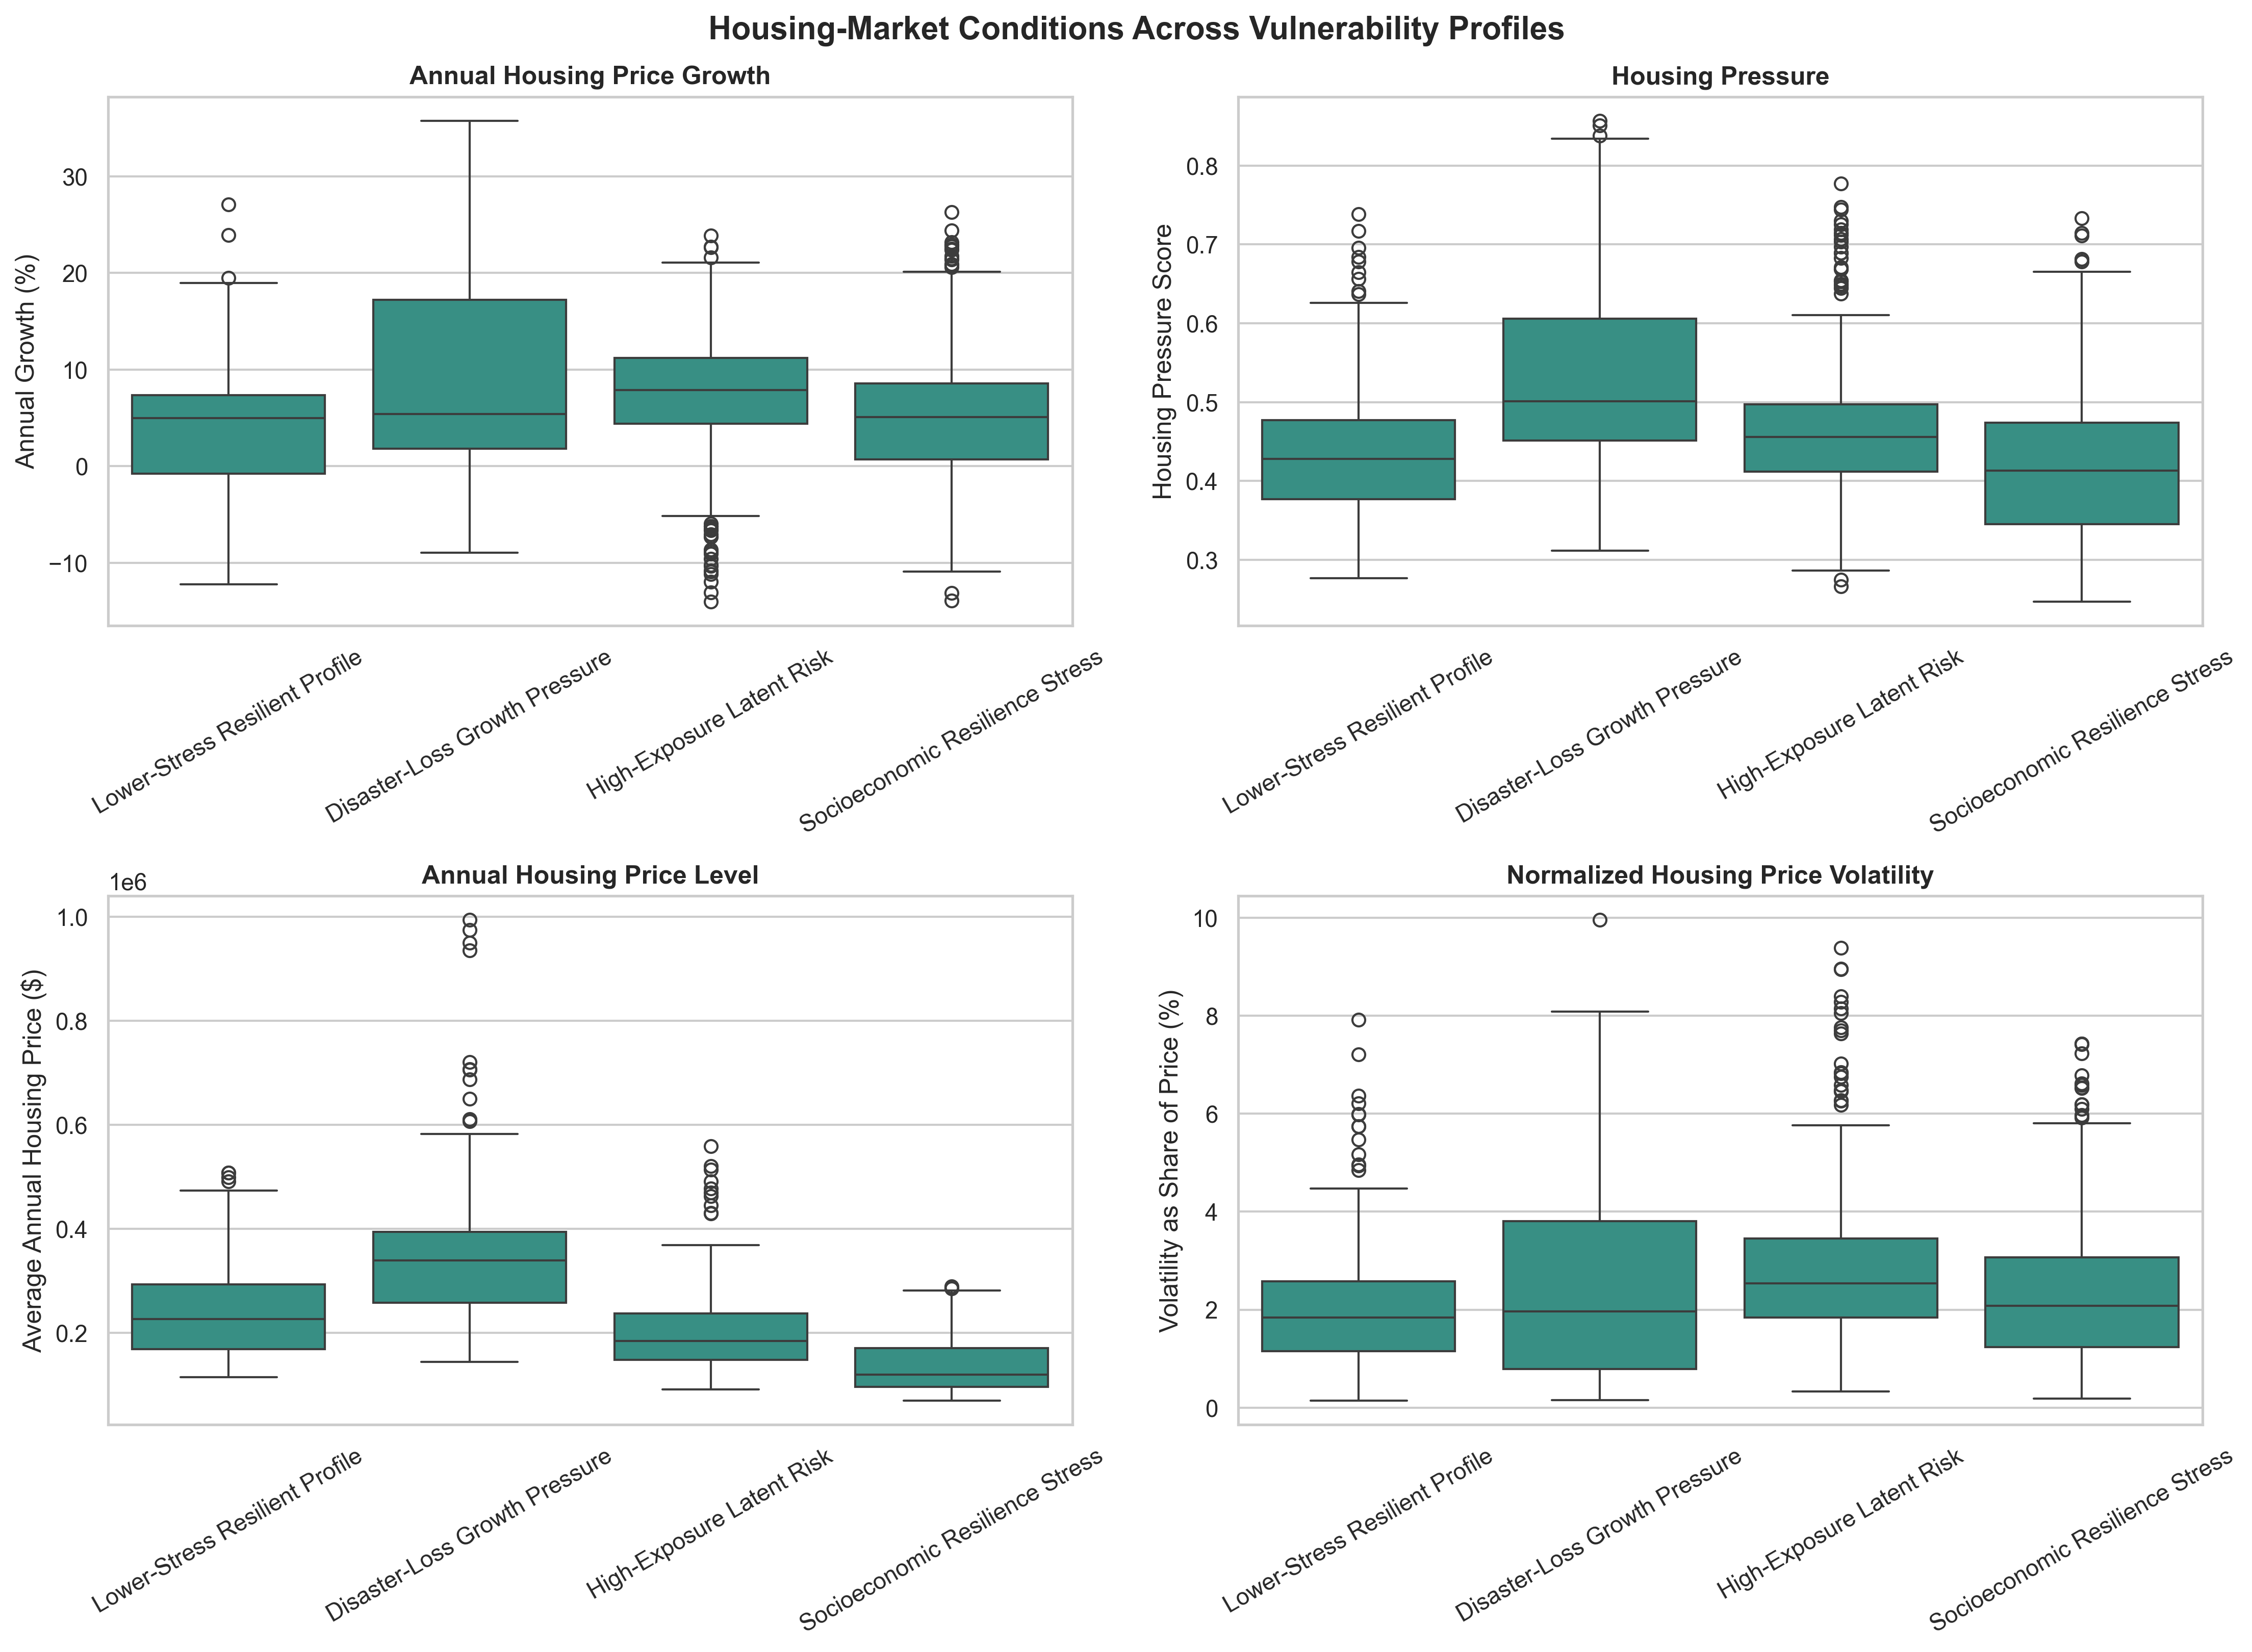

In [17]:
clustered_data["annual_price_volatility_pct"] = (
    clustered_data["annual_price_volatility"]
    / clustered_data["avg_annual_housing_price"]
    * 100
)

housing_market_features = [
    "annual_price_growth_pct",
    "housing_pressure_score",
    "avg_annual_housing_price",
    "annual_price_volatility_pct",
]

housing_market_profile_table = (
    clustered_data.groupby("cluster_name")[housing_market_features]
    .mean()
    .reindex(CLUSTER_NAMES.values())
    .round(4)
)

housing_market_profile_table.columns = [
    "avg_annual_growth_pct",
    "avg_housing_pressure_score",
    "avg_annual_housing_price",
    "avg_price_volatility_pct",
]

print("Housing-market conditions compared successfully.")

display(housing_market_profile_table)

housing_market_profile_table.to_csv(
    RESULTS_TABLES / "cluster_housing_market_profiles.csv"
)

# Housing-Market Comparison Figure

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

plot_settings = [
    ("annual_price_growth_pct", "Annual Housing Price Growth", "Annual Growth (%)"),
    ("housing_pressure_score", "Housing Pressure", "Housing Pressure Score"),
    (
        "avg_annual_housing_price",
        "Annual Housing Price Level",
        "Average Annual Housing Price ($)",
    ),
    (
        "annual_price_volatility_pct",
        "Normalized Housing Price Volatility",
        "Volatility as Share of Price (%)",
    ),
]

cluster_order = list(CLUSTER_NAMES.values())

for axis, (feature, title, ylabel) in zip(axes.flat, plot_settings):
    sns.boxplot(
        data=clustered_data, x="cluster_name", y=feature, order=cluster_order, ax=axis
    )

    axis.set_title(title, fontsize=12, fontweight="bold")

    axis.set_xlabel("")
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Housing-Market Conditions Across Vulnerability Profiles",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()

figure_path = RESULTS_FIGURES / "housing_market_conditions_by_cluster.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Housing-market comparison figure saved to: " f"{figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "housing_market_conditions_by_cluster.png"),
        width=850,
    )
)


Vulnerability-class composition calculated successfully.

Class counts by cluster


vulnerability_class,Low,Medium,High
cluster_name,,,
Lower-Stress Resilient Profile,118,49,4
Disaster-Loss Growth Pressure,1,46,144
High-Exposure Latent Risk,25,106,153
Socioeconomic Resilience Stress,190,132,32


Class percentages within each cluster


vulnerability_class,Low,Medium,High
cluster_name,,,
Lower-Stress Resilient Profile,69.0100,28.6500,2.3400
Disaster-Loss Growth Pressure,0.5200,24.0800,75.3900
High-Exposure Latent Risk,8.8000,37.3200,53.8700
Socioeconomic Resilience Stress,53.6700,37.2900,9.0400


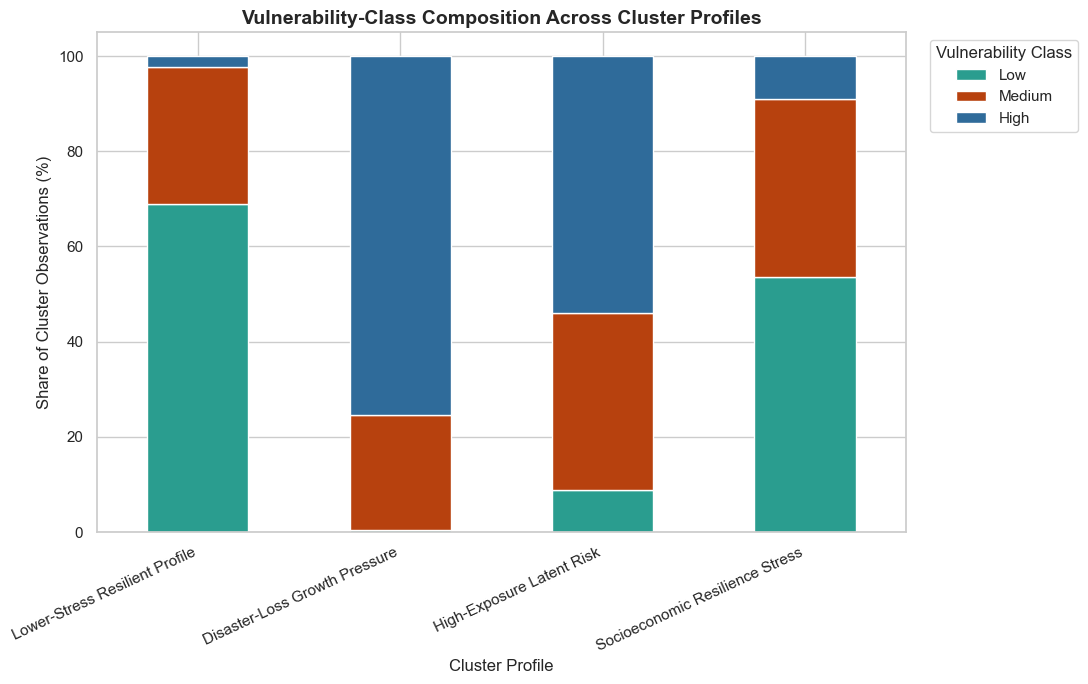

Vulnerability-class composition figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\vulnerability_class_composition_by_cluster.png


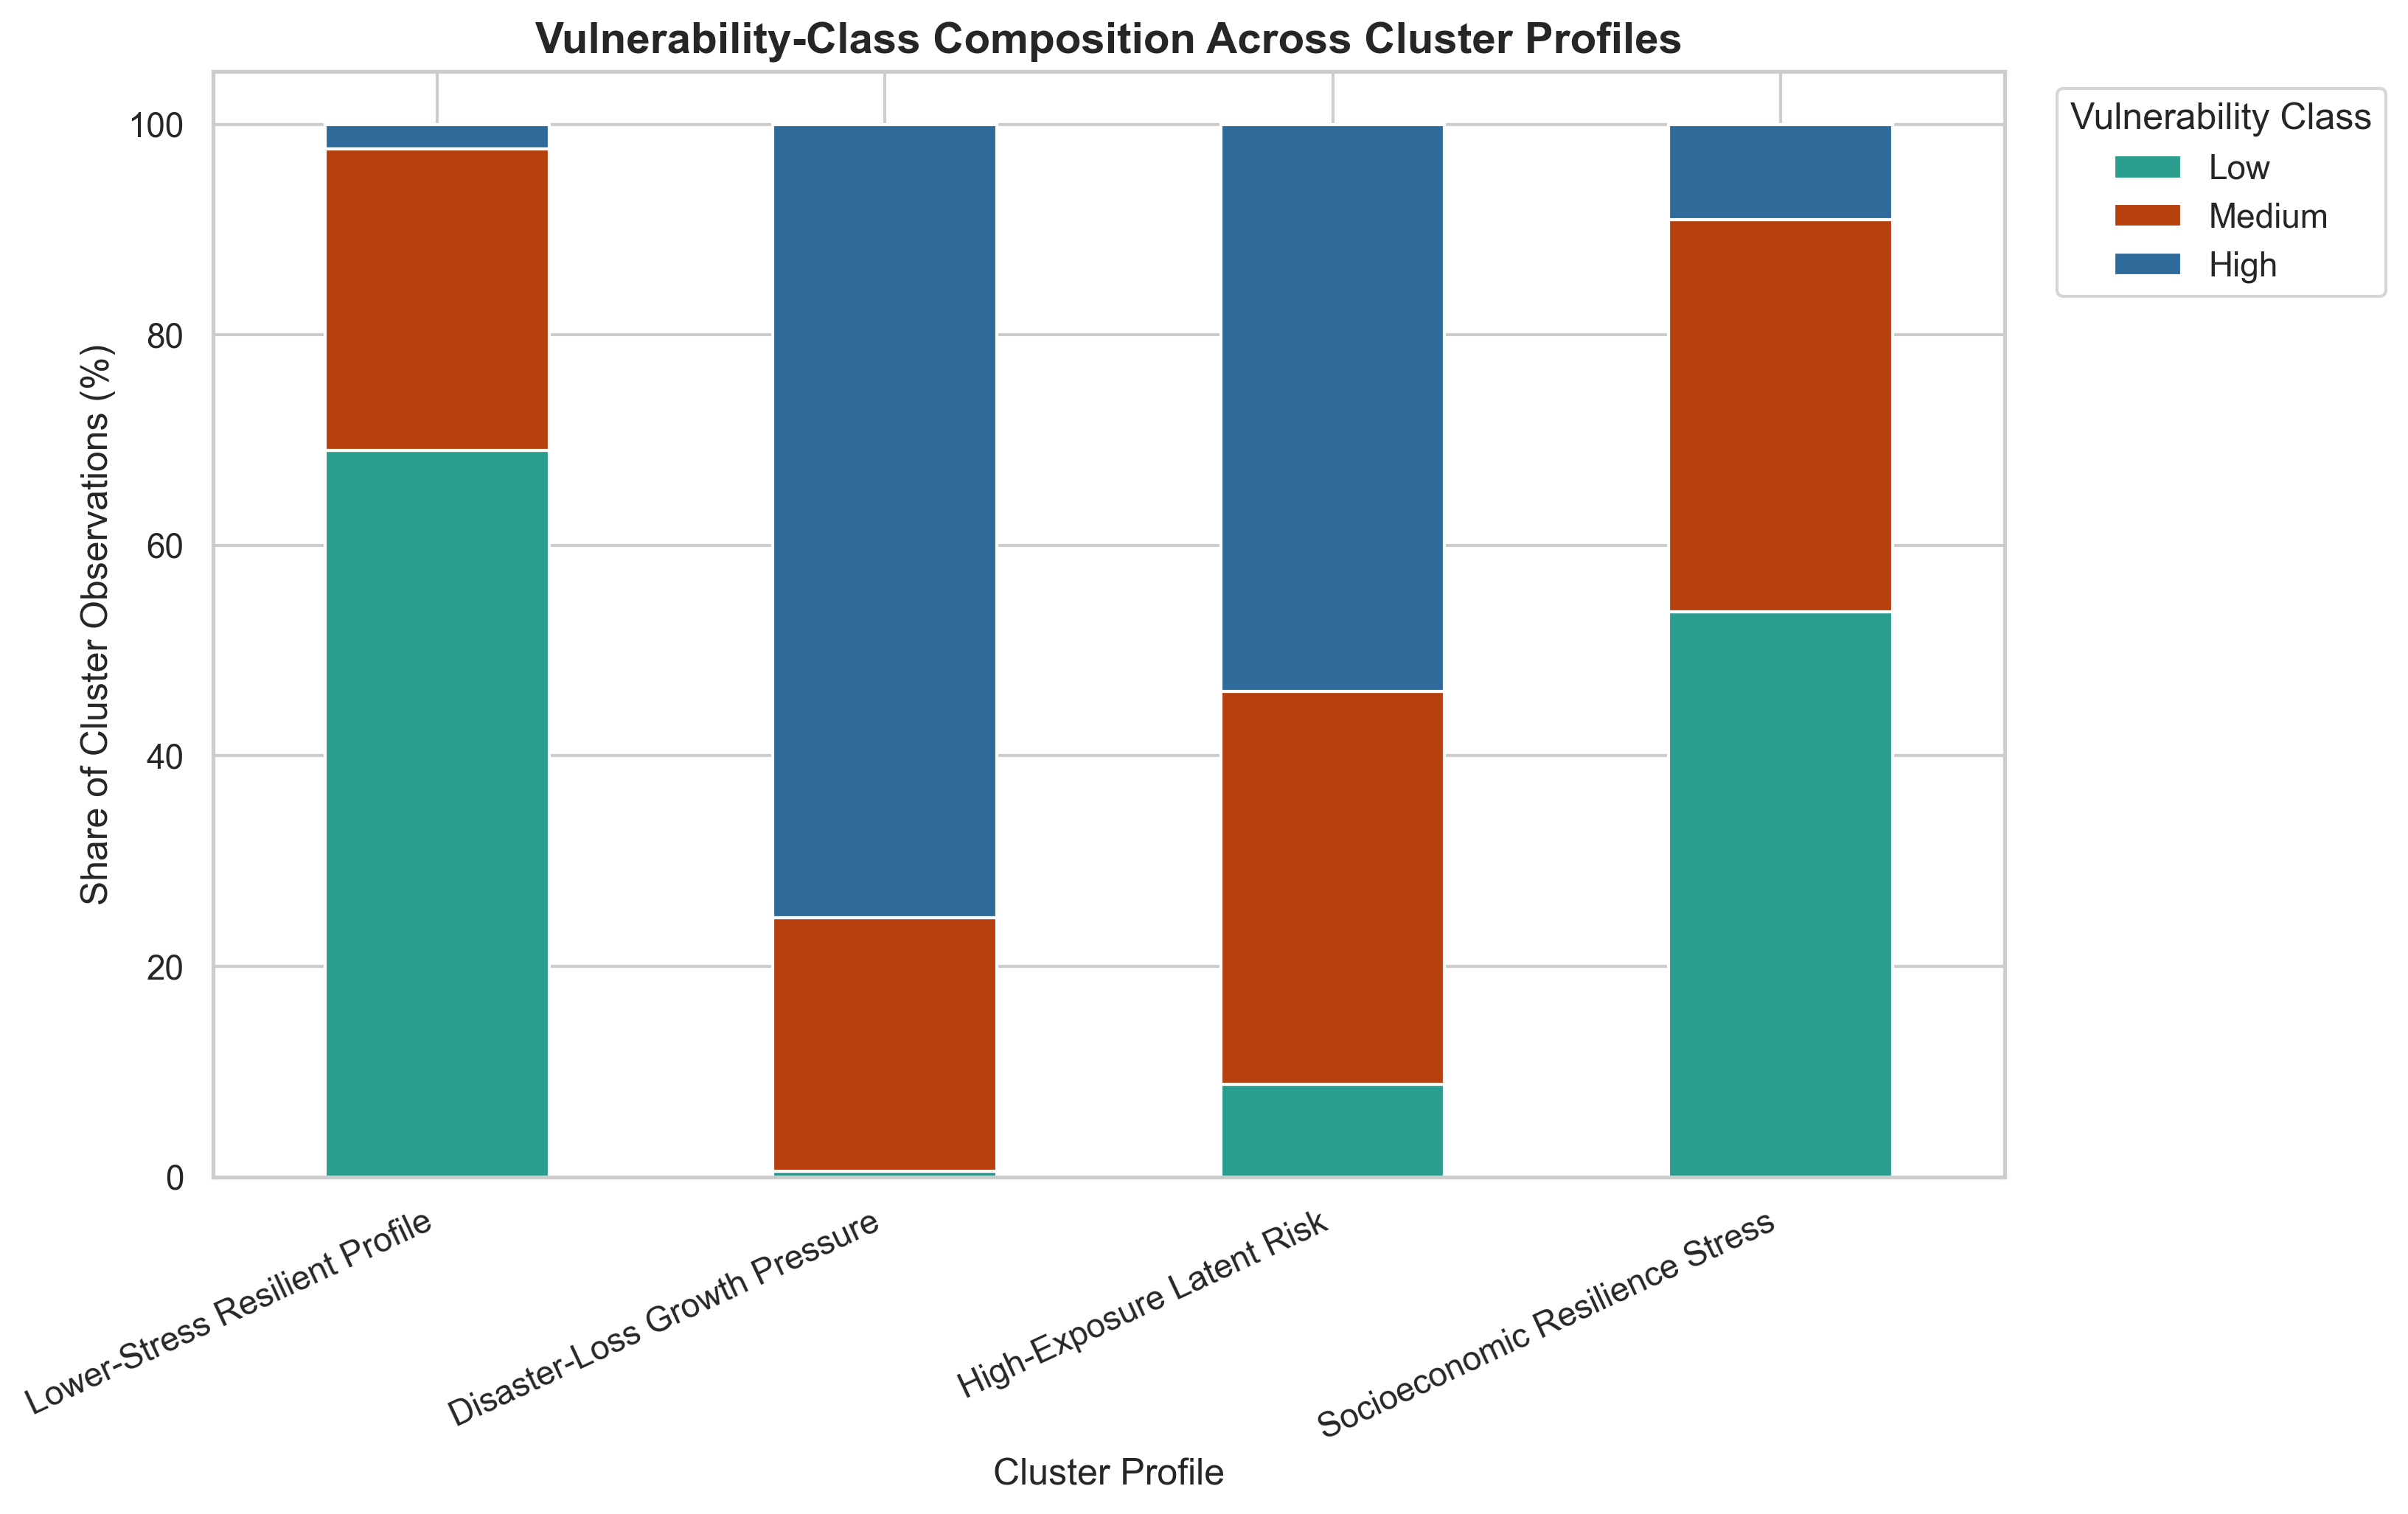

In [18]:
vulnerability_class_order = ["Low", "Medium", "High"]

cluster_order = list(CLUSTER_NAMES.values())

cluster_class_counts = pd.crosstab(
    clustered_data["cluster_name"], clustered_data["vulnerability_class"]
).reindex(index=cluster_order, columns=vulnerability_class_order, fill_value=0)

cluster_class_percentages = (
    cluster_class_counts.div(cluster_class_counts.sum(axis=1), axis=0).mul(100).round(2)
)

print("Vulnerability-class composition calculated successfully.")

print("\nClass counts by cluster")
display(cluster_class_counts)

print("Class percentages within each cluster")
display(cluster_class_percentages)

cluster_class_counts.to_csv(RESULTS_TABLES / "cluster_vulnerability_class_counts.csv")

cluster_class_percentages.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_percentages.csv"
)

# Vulnerability-Class Composition Figure

ax = cluster_class_percentages.plot(kind="bar", stacked=True, figsize=(11, 7))

plt.title(
    "Vulnerability-Class Composition Across Cluster Profiles",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Cluster Profile")
plt.ylabel("Share of Cluster Observations (%)")

plt.xticks(rotation=25, ha="right")

plt.legend(title="Vulnerability Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

figure_path = RESULTS_FIGURES / "vulnerability_class_composition_by_cluster.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Vulnerability-class composition figure saved to: " f"{figure_path}")

display(
    Image(
        filename=str(
            RESULTS_FIGURES / "vulnerability_class_composition_by_cluster.png"
        ),
        width=850,
    )
)


## 6. Temporal prevalence and robustness

Annual prevalence and study-period distributions show how profile composition changes over time. The year-by-profile chi-square statistic is descriptive because repeated observations from the same counties are not independent. Two further checks evaluate recent county-level profiles and resample complete counties in a 100-repetition bootstrap.


Temporal cluster-prevalence analysis completed.
Study period: 2011–2025

Annual cluster counts


cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
Year,,,,
2011,13,0,20,33
2012,13,0,23,30
2013,9,0,28,29
2014,10,0,28,28
2015,11,0,29,26
2016,11,1,32,23
2017,11,19,14,23
2018,12,5,28,22
2019,15,8,21,23


Annual cluster percentage shares


cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
Year,,,,
2011,19.7000,0.0000,30.3000,50.0000
2012,19.7000,0.0000,34.8500,45.4500
2013,13.6400,0.0000,42.4200,43.9400
2014,15.1500,0.0000,42.4200,42.4200
2015,16.6700,0.0000,43.9400,39.3900
2016,16.4200,1.4900,47.7600,34.3300
2017,16.4200,28.3600,20.9000,34.3300
2018,17.9100,7.4600,41.7900,32.8400
2019,22.3900,11.9400,31.3400,34.3300


Cluster counts by five-year period


...

Year distribution within each cluster


,observation_count,unique_counties,minimum_year,median_year,mean_year,maximum_year
cluster_name,,,,,,
Lower-Stress Resilient Profile,171,21,2011,"2,018.0000","2,018.0200",2025
Disaster-Loss Growth Pressure,191,55,2016,"2,022.0000","2,021.9700",2025
High-Exposure Latent Risk,284,38,2011,"2,016.0000","2,016.3500",2025
Socioeconomic Resilience Stress,354,34,2011,"2,017.0000","2,017.2400",2025


Association between year and cluster membership


,metric,value
0,Chi-square statistic,428.6754
1,Degrees of freedom,42.0000
2,P-value,0.0000
3,Bias-corrected Cramér's V,0.3595


Bias-corrected Cramér's V: 0.3595


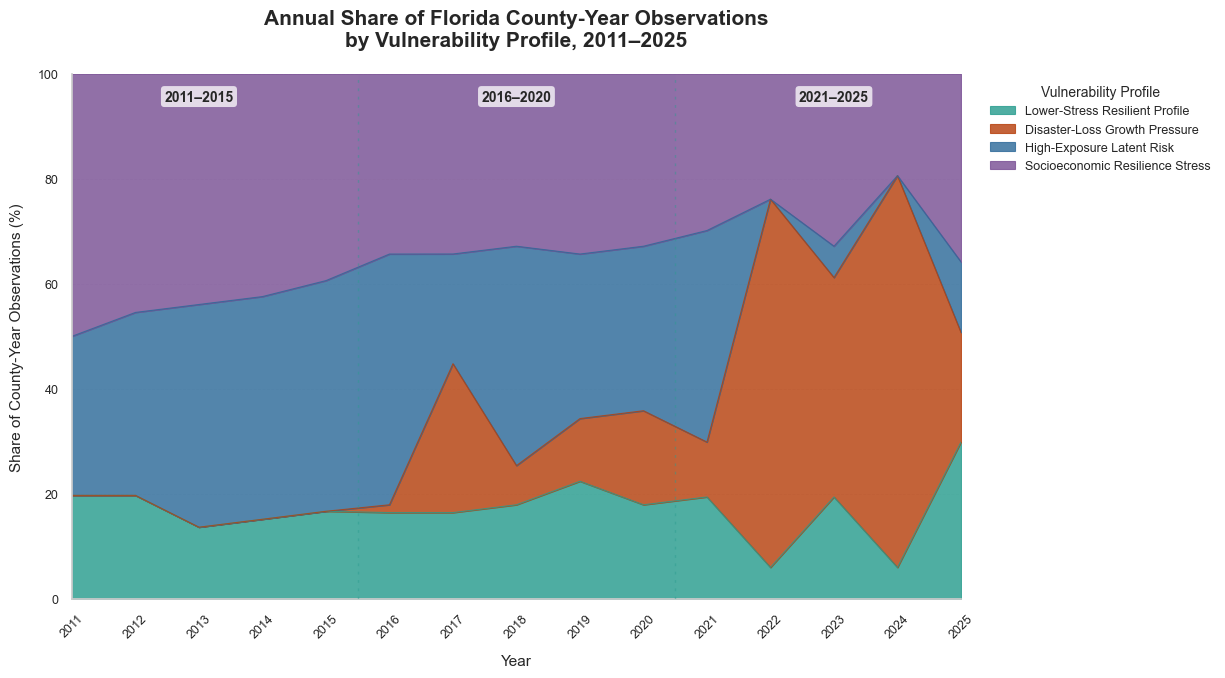

Temporal cluster tables and figure saved successfully.
Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\annual_cluster_prevalence_2011_2025.png


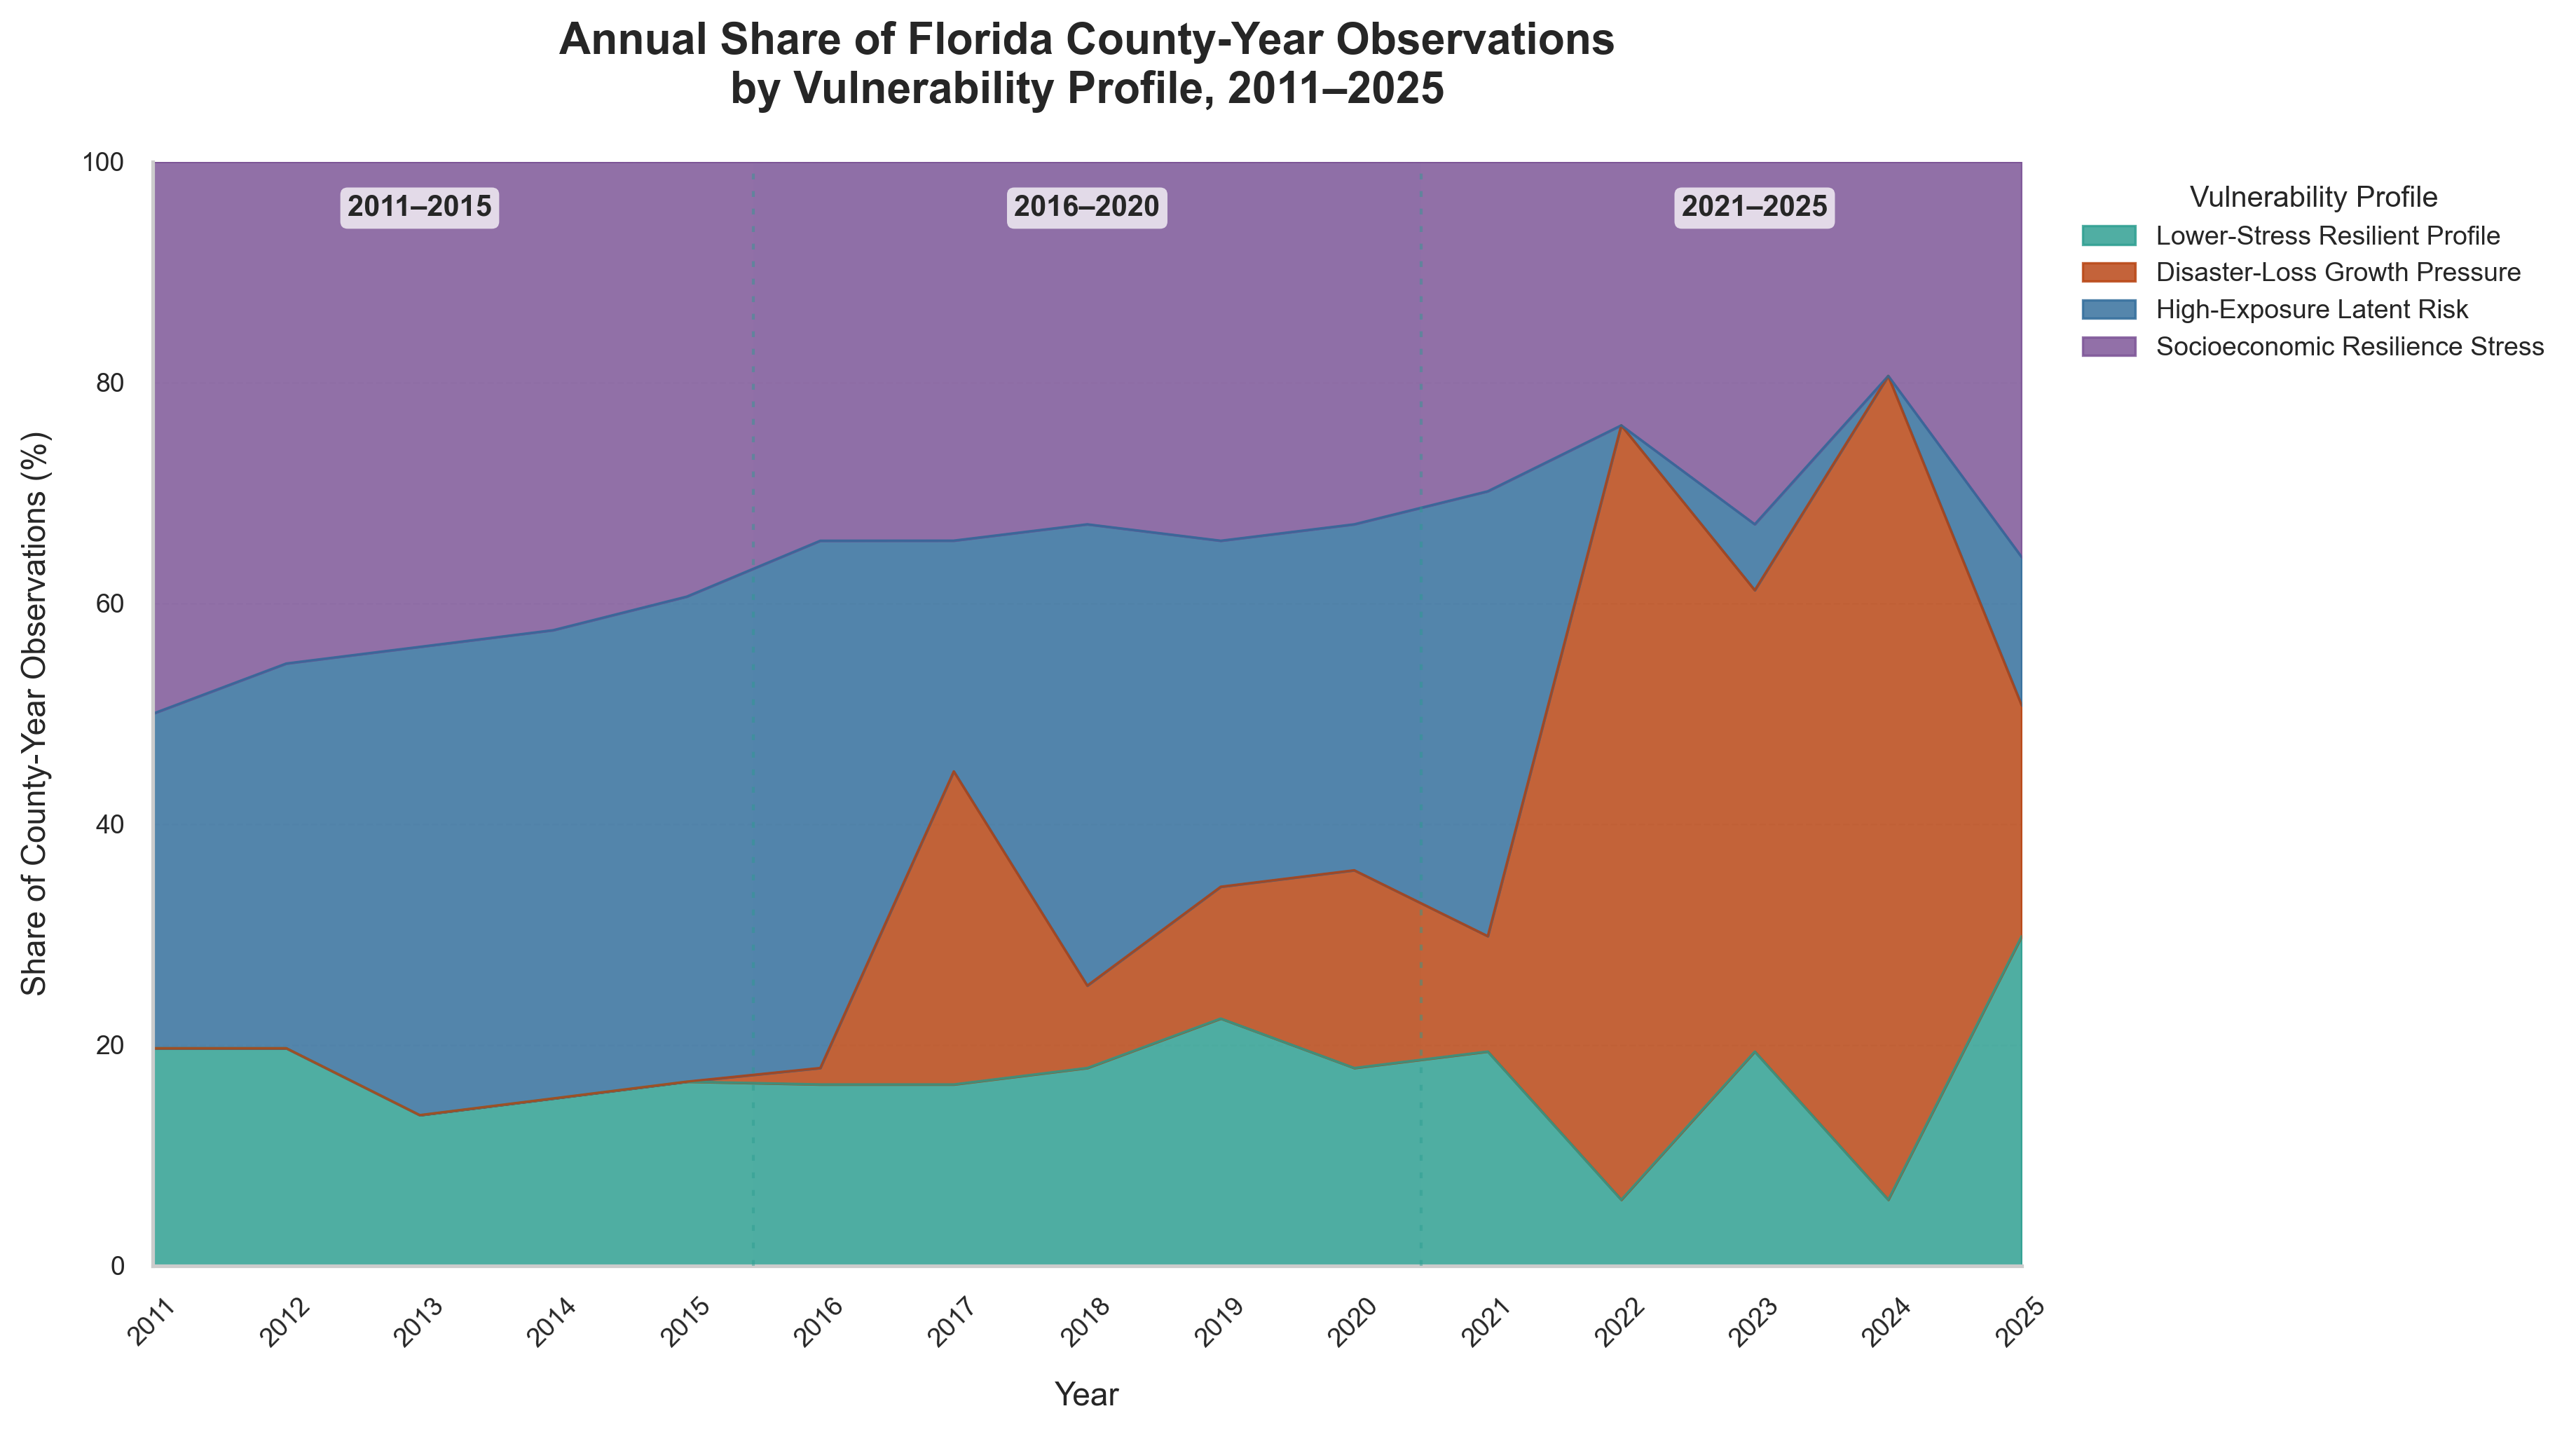

In [19]:
from scipy.stats import chi2_contingency

cluster_order = [CLUSTER_NAMES[cluster_id] for cluster_id in sorted(CLUSTER_NAMES)]

year_order = list(
    range(int(clustered_data["Year"].min()), int(clustered_data["Year"].max()) + 1)
)

# Annual Cluster Counts

annual_cluster_counts = pd.crosstab(
    clustered_data["Year"], clustered_data["cluster_name"]
).reindex(index=year_order, columns=cluster_order, fill_value=0)

annual_cluster_counts.index.name = "Year"

# Annual Cluster Percentage Shares

annual_cluster_shares = (
    annual_cluster_counts.div(annual_cluster_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

# Define Five-Year Study Periods

temporal_cluster_data = clustered_data[
    ["STCOFIPS", "RegionName", "Year", "cluster_id", "cluster_name"]
].copy()

temporal_cluster_data["study_period"] = np.select(
    [
        temporal_cluster_data["Year"].between(2011, 2015),
        temporal_cluster_data["Year"].between(2016, 2020),
        temporal_cluster_data["Year"].between(2021, 2025),
    ],
    ["2011–2015", "2016–2020", "2021–2025"],
    default="Other",
)

period_order = ["2011–2015", "2016–2020", "2021–2025"]

# Cluster Counts and Shares by Study Period

period_cluster_counts = pd.crosstab(
    temporal_cluster_data["study_period"], temporal_cluster_data["cluster_name"]
).reindex(index=period_order, columns=cluster_order, fill_value=0)

period_cluster_shares = (
    period_cluster_counts.div(period_cluster_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

# Year Distribution Within Each Cluster

cluster_year_summary = (
    temporal_cluster_data.groupby("cluster_name")
    .agg(
        observation_count=("Year", "size"),
        unique_counties=("STCOFIPS", "nunique"),
        minimum_year=("Year", "min"),
        median_year=("Year", "median"),
        mean_year=("Year", "mean"),
        maximum_year=("Year", "max"),
    )
    .reindex(cluster_order)
    .round(2)
)

# Test Relationship Between Year and Cluster

year_cluster_contingency = pd.crosstab(
    temporal_cluster_data["Year"], temporal_cluster_data["cluster_name"]
)

chi_square_statistic, chi_square_p_value, degrees_freedom, expected = chi2_contingency(
    year_cluster_contingency
)

sample_size = year_cluster_contingency.to_numpy().sum()
rows, columns = year_cluster_contingency.shape

# Bias-corrected Cramér's V
phi_squared = chi_square_statistic / sample_size

phi_squared_corrected = max(
    0, phi_squared - ((columns - 1) * (rows - 1)) / (sample_size - 1)
)

rows_corrected = rows - ((rows - 1) ** 2) / (sample_size - 1)

columns_corrected = columns - ((columns - 1) ** 2) / (sample_size - 1)

cramers_v = np.sqrt(
    phi_squared_corrected / min(columns_corrected - 1, rows_corrected - 1)
)

temporal_association_table = pd.DataFrame(
    {
        "metric": [
            "Chi-square statistic",
            "Degrees of freedom",
            "P-value",
            "Bias-corrected Cramér's V",
        ],
        "value": [chi_square_statistic, degrees_freedom, chi_square_p_value, cramers_v],
    }
)

# Display Temporal Results

print("Temporal cluster-prevalence analysis completed.")
print(
    f"Study period: "
    f"{temporal_cluster_data['Year'].min()}–"
    f"{temporal_cluster_data['Year'].max()}"
)

print("\nAnnual cluster counts")
display(annual_cluster_counts)

print("Annual cluster percentage shares")
display(annual_cluster_shares)

print("Cluster counts by five-year period")
display(period_cluster_counts)

print("Cluster percentage shares by five-year period")
display(period_cluster_shares)

print("Year distribution within each cluster")
display(cluster_year_summary)

print("Association between year and cluster membership")
display(temporal_association_table.round(4))

print(f"Bias-corrected Cramér's V: " f"{cramers_v:.4f}")

# Visualize Annual Cluster Shares

fig, ax = plt.subplots(figsize=(14, 7.5))

annual_cluster_shares.plot.area(stacked=True, alpha=0.82, linewidth=0.8, ax=ax)

# Add Subtle Study-Period Background Shading

# First period: 2011–2015
ax.axvspan(2010.5, 2015.5, alpha=0.025, zorder=0)

# Second period: 2016–2020
ax.axvspan(2015.5, 2020.5, alpha=0.06, zorder=0)

# Third period: 2021–2025
ax.axvspan(2020.5, 2025.5, alpha=0.025, zorder=0)

# Add Subtle Period Separators

for boundary_year in [2015.5, 2020.5]:
    ax.axvline(
        x=boundary_year, linestyle=(0, (2, 4)), linewidth=1.0, alpha=0.45, zorder=4
    )

# Add Study-Period Labels Inside Plot

period_labels = [(2013, "2011–2015"), (2018, "2016–2020"), (2023, "2021–2025")]

for x_position, label in period_labels:
    ax.text(
        x_position,
        97,
        label,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="semibold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
        },
        zorder=6,
    )

# Titles and Axis Formatting

ax.set_title(
    "Annual Share of Florida County-Year Observations\n"
    "by Vulnerability Profile, 2011–2025",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.set_xlabel("Year", fontsize=11, labelpad=10)

ax.set_ylabel("Share of County-Year Observations (%)", fontsize=11, labelpad=10)

ax.set_ylim(0, 100)

ax.set_xlim(annual_cluster_shares.index.min(), annual_cluster_shares.index.max())

ax.set_xticks(year_order)

ax.tick_params(axis="x", rotation=45, labelsize=9)

ax.tick_params(axis="y", labelsize=9)

# Use only light horizontal gridlines
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.3)

ax.grid(axis="x", visible=False)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend

ax.legend(
    title="Vulnerability Profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

# Reserve space for the external legend and title
fig.subplots_adjust(top=0.86, right=0.76, bottom=0.16)

# Save Figure

temporal_figure_path = RESULTS_FIGURES / "annual_cluster_prevalence_2011_2025.png"

plt.savefig(temporal_figure_path, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Save Temporal Analysis Outputs

annual_cluster_counts.to_csv(RESULTS_TABLES / "annual_cluster_counts.csv")

annual_cluster_shares.to_csv(RESULTS_TABLES / "annual_cluster_shares_pct.csv")

period_cluster_counts.to_csv(RESULTS_TABLES / "cluster_counts_by_study_period.csv")

period_cluster_shares.to_csv(RESULTS_TABLES / "cluster_shares_by_study_period_pct.csv")

cluster_year_summary.to_csv(RESULTS_TABLES / "cluster_year_distribution_summary.csv")

temporal_association_table.to_csv(
    RESULTS_TABLES / "year_cluster_association_results.csv", index=False
)

print("Temporal cluster tables and figure saved successfully.")

print(f"Figure saved to: {temporal_figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "annual_cluster_prevalence_2011_2025.png"),
        width=850,
    )
)


Recent county-level profiles created successfully.
Recent period: 2021–2025
County profiles created: 67
Counties with all five recent years: 67

Recent county-level cluster-selection results


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_size,largest_cluster_size
0,2,181.7857,0.3508,42.2536,1.1261,28,39
1,3,141.6077,0.3046,35.7831,1.2101,18,25
2,4,118.5662,0.3077,32.1271,1.2006,6,25
3,5,105.0986,0.2502,28.7377,1.2996,6,19
4,6,94.8205,0.2390,26.3936,1.2502,3,18



Recent-to-original cluster alignment


,recent_raw_cluster,matched_original_cluster,matched_profile
2,2,0,Lower-Stress Resilient Profile
0,0,1,Disaster-Loss Growth Pressure
3,3,2,High-Exposure Latent Risk
1,1,3,Socioeconomic Resilience Stress



Original versus recent centroid similarity


,cluster_id,cluster_name,matched_recent_raw_cluster,euclidean_centroid_distance,profile_correlation,cosine_similarity
0,0,Lower-Stress Resilient Profile,2,1.7209,0.8444,0.8414
1,1,Disaster-Loss Growth Pressure,0,0.9072,0.8826,0.9261
2,2,High-Exposure Latent Risk,3,2.0704,-0.0110,0.0942
3,3,Socioeconomic Resilience Stress,1,1.5591,0.6785,0.5931



County-level robustness summary


,metric,value
0,Recent county profiles,67.0000
1,Exact profile agreement (%),64.1791
2,Adjusted Rand Index,0.4440


Assignment comparison matrix


robustness_cluster_name,Lower-Stress Resilient Profile,Disaster-Loss Growth Pressure,High-Exposure Latent Risk,Socioeconomic Resilience Stress
dominant_main_cluster_name,,,,
Lower-Stress Resilient Profile,6,0,6,0
Disaster-Loss Growth Pressure,0,15,11,4
High-Exposure Latent Risk,0,3,1,0
Socioeconomic Resilience Stress,0,0,0,21


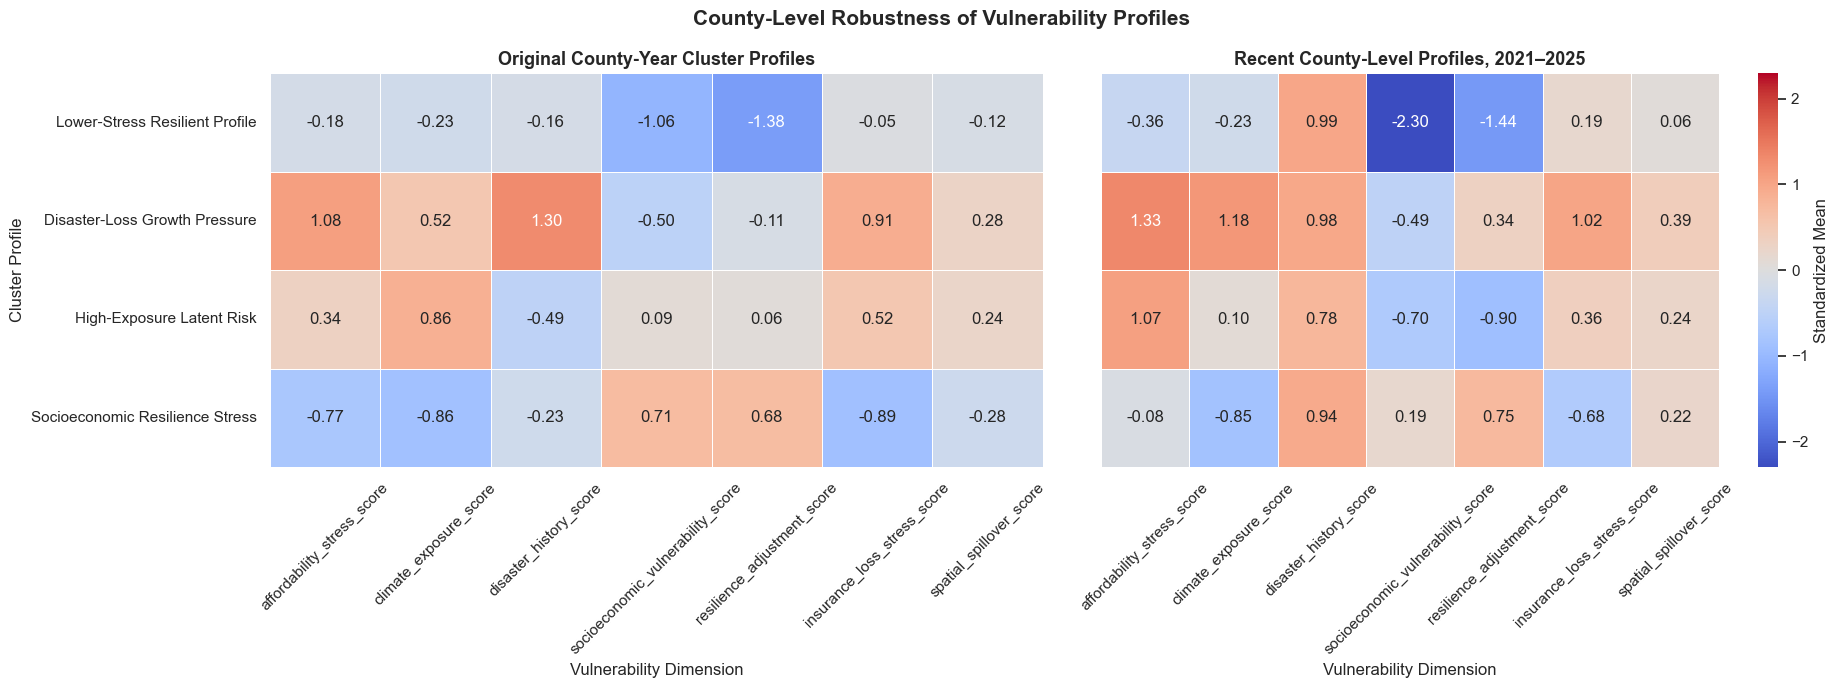

Recent county-level robustness outputs saved successfully.
Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\recent_county_level_cluster_robustness.png


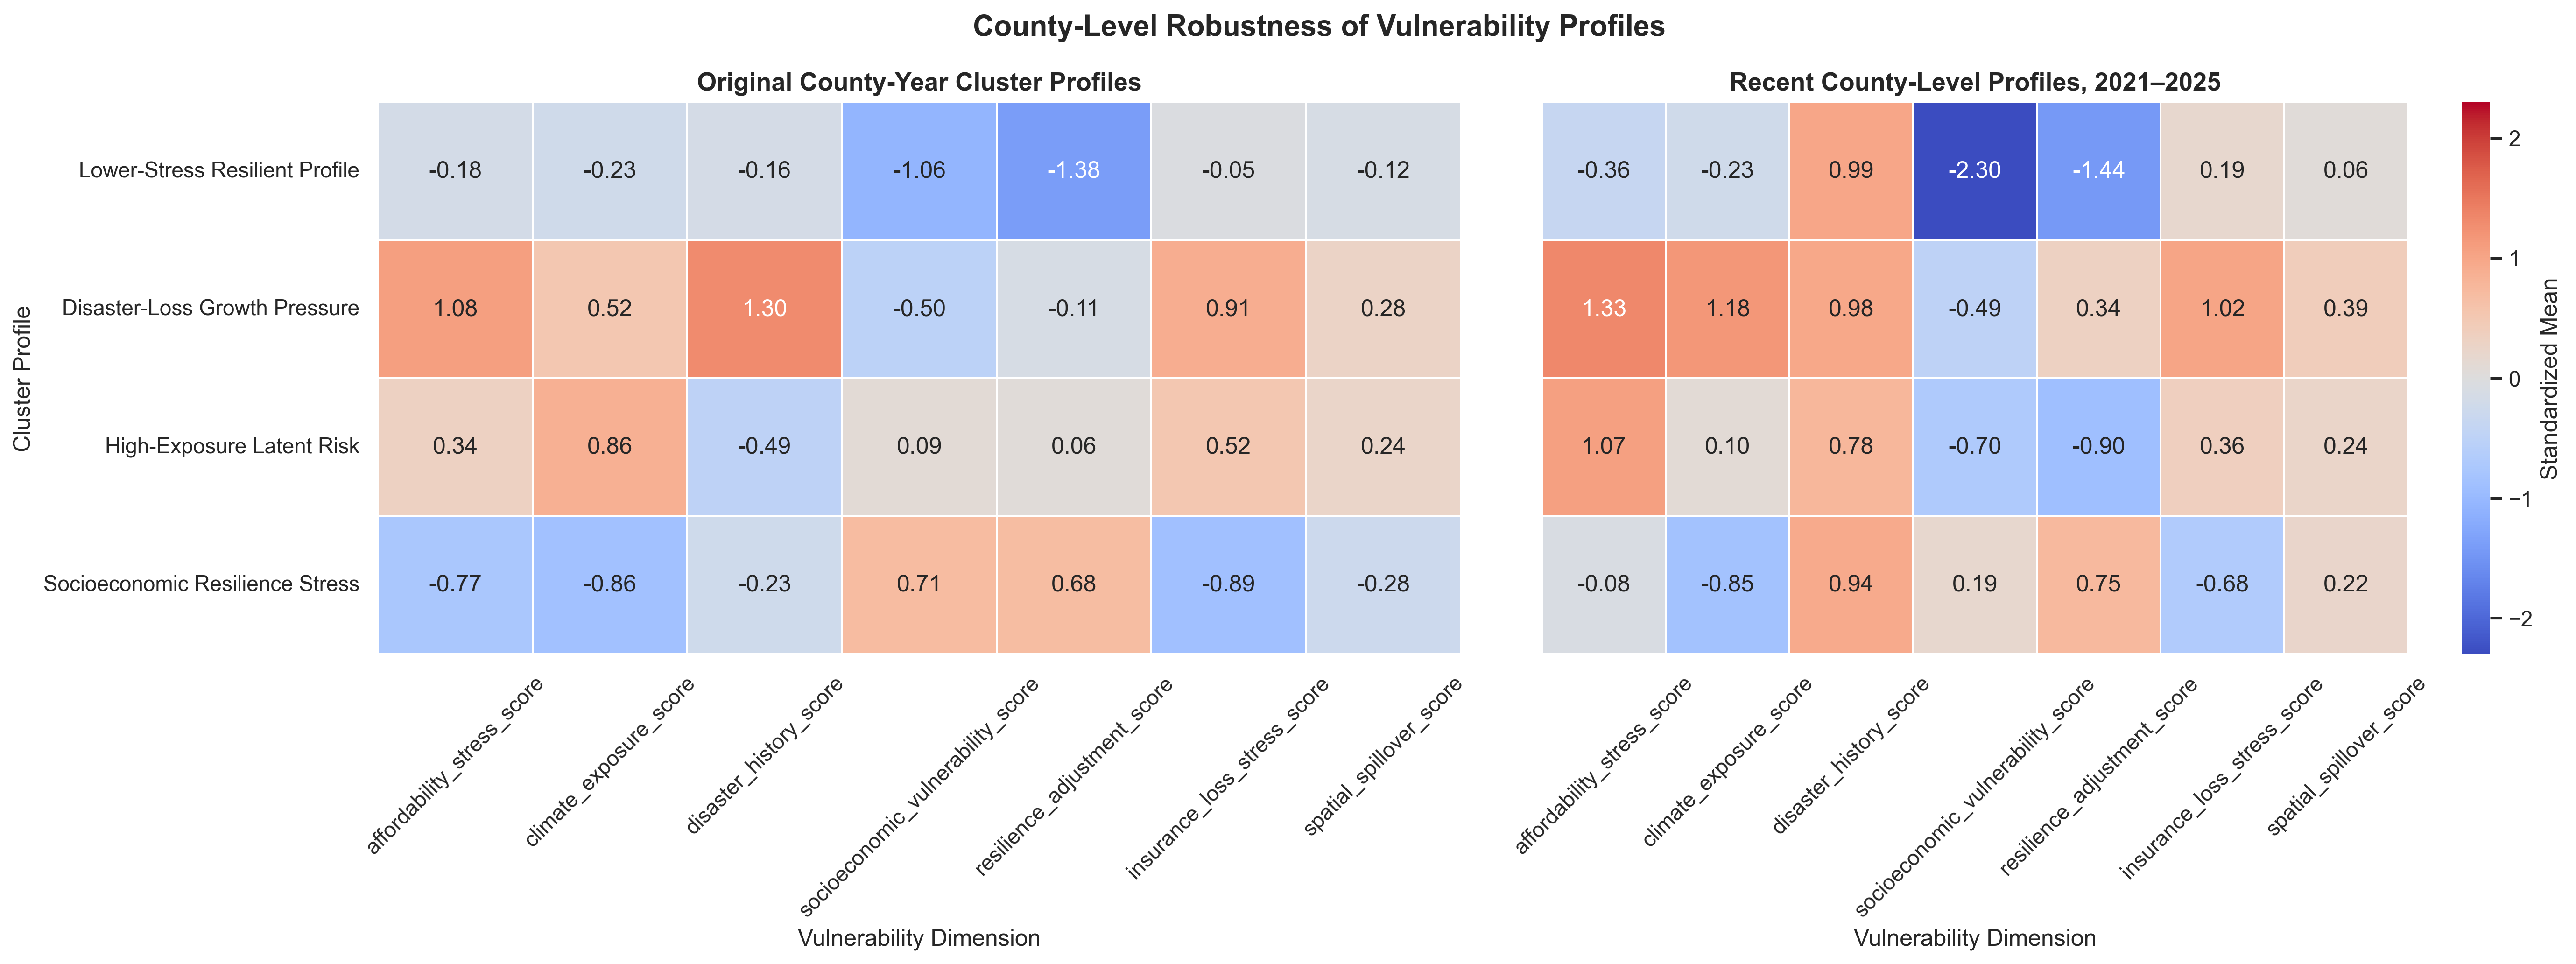

In [20]:
from scipy.optimize import linear_sum_assignment

RECENT_ROBUSTNESS_START_YEAR = 2021
RECENT_ROBUSTNESS_END_YEAR = 2025

# Create One Recent Profile Per County

recent_period_data = clustered_data[
    clustered_data["Year"].between(
        RECENT_ROBUSTNESS_START_YEAR, RECENT_ROBUSTNESS_END_YEAR
    )
].copy()

recent_county_profiles = (
    recent_period_data.groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg({**{feature: "mean" for feature in CLUSTERING_FEATURES}, "Year": "nunique"})
    .rename(columns={"Year": "recent_years_observed"})
)

print("Recent county-level profiles created successfully.")
print(
    f"Recent period: "
    f"{RECENT_ROBUSTNESS_START_YEAR}–"
    f"{RECENT_ROBUSTNESS_END_YEAR}"
)
print(f"County profiles created: " f"{len(recent_county_profiles)}")
print(
    f"Counties with all five recent years: "
    f"{(
        recent_county_profiles['recent_years_observed'] == 5
    ).sum()}"
)

# Transform Using the Original County-Year Scaler
#
# Using the original scaler keeps the recent county
# centroids in the same standardized feature space as
# the main county-year model.

X_recent_county_scaled = scaler.transform(recent_county_profiles[CLUSTERING_FEATURES])

# Evaluate Candidate Cluster Counts

recent_county_selection_results = []

for k in range(2, 7):

    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)

    labels = model.fit_predict(X_recent_county_scaled)

    cluster_sizes = pd.Series(labels).value_counts()

    recent_county_selection_results.append(
        {
            "n_clusters": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(X_recent_county_scaled, labels),
            "calinski_harabasz_score": calinski_harabasz_score(
                X_recent_county_scaled, labels
            ),
            "davies_bouldin_score": davies_bouldin_score(
                X_recent_county_scaled, labels
            ),
            "smallest_cluster_size": cluster_sizes.min(),
            "largest_cluster_size": cluster_sizes.max(),
        }
    )

recent_county_selection_table = pd.DataFrame(recent_county_selection_results)

print("\nRecent county-level cluster-selection results")
display(recent_county_selection_table.round(4))

# Fit Four-Cluster County-Level Robustness Model

recent_county_kmeans_model = KMeans(
    n_clusters=FINAL_N_CLUSTERS, random_state=RANDOM_STATE, n_init=50
)

recent_county_raw_labels = recent_county_kmeans_model.fit_predict(
    X_recent_county_scaled
)

recent_county_profiles["robustness_cluster_raw"] = recent_county_raw_labels

# Align New Cluster IDs with Original Cluster IDs
#
# K-Means cluster numbers are arbitrary. The Hungarian
# algorithm finds the one-to-one matching that minimizes
# distance between recent county-level centroids and the
# original county-year centroids.

centroid_distance_matrix = np.linalg.norm(
    recent_county_kmeans_model.cluster_centers_[:, None, :]
    - final_kmeans_model.cluster_centers_[None, :, :],
    axis=2,
)

recent_rows, original_columns = linear_sum_assignment(centroid_distance_matrix)

recent_to_original_mapping = {
    int(recent_cluster_id): int(original_cluster_id)
    for recent_cluster_id, original_cluster_id in zip(recent_rows, original_columns)
}

recent_county_profiles["robustness_cluster_id"] = recent_county_profiles[
    "robustness_cluster_raw"
].map(recent_to_original_mapping)

recent_county_profiles["robustness_cluster_name"] = recent_county_profiles[
    "robustness_cluster_id"
].map(CLUSTER_NAMES)

print("\nRecent-to-original cluster alignment")
display(
    pd.DataFrame(
        {
            "recent_raw_cluster": list(recent_to_original_mapping.keys()),
            "matched_original_cluster": list(recent_to_original_mapping.values()),
        }
    )
    .assign(
        matched_profile=lambda data: data["matched_original_cluster"].map(CLUSTER_NAMES)
    )
    .sort_values("matched_original_cluster")
)

# Create Aligned Recent Cluster Profile Table

recent_centers_aligned = pd.DataFrame(
    index=range(FINAL_N_CLUSTERS), columns=CLUSTERING_FEATURES, dtype=float
)

for recent_cluster_id, original_cluster_id in recent_to_original_mapping.items():

    recent_centers_aligned.loc[original_cluster_id] = (
        recent_county_kmeans_model.cluster_centers_[recent_cluster_id]
    )

recent_centers_aligned.index.name = "cluster_id"

recent_centers_aligned_named = recent_centers_aligned.copy()

recent_centers_aligned_named.index = recent_centers_aligned_named.index.map(
    CLUSTER_NAMES
)

# Exact original centroids
original_centers_table = pd.DataFrame(
    final_kmeans_model.cluster_centers_,
    columns=CLUSTERING_FEATURES,
    index=range(FINAL_N_CLUSTERS),
)

original_centers_table.index.name = "cluster_id"

original_centers_named = original_centers_table.copy()

original_centers_named.index = original_centers_named.index.map(CLUSTER_NAMES)

# Compare Original and Recent Profile Shapes

centroid_similarity_results = []

for original_cluster_id in range(FINAL_N_CLUSTERS):

    recent_cluster_id = next(
        recent_id
        for recent_id, matched_original_id in recent_to_original_mapping.items()
        if matched_original_id == original_cluster_id
    )

    original_centroid = final_kmeans_model.cluster_centers_[original_cluster_id]

    recent_centroid = recent_county_kmeans_model.cluster_centers_[recent_cluster_id]

    euclidean_distance = np.linalg.norm(original_centroid - recent_centroid)

    profile_correlation = np.corrcoef(original_centroid, recent_centroid)[0, 1]

    cosine_denominator = np.linalg.norm(original_centroid) * np.linalg.norm(
        recent_centroid
    )

    cosine_similarity = (
        np.dot(original_centroid, recent_centroid) / cosine_denominator
        if cosine_denominator != 0
        else np.nan
    )

    centroid_similarity_results.append(
        {
            "cluster_id": original_cluster_id,
            "cluster_name": CLUSTER_NAMES[original_cluster_id],
            "matched_recent_raw_cluster": recent_cluster_id,
            "euclidean_centroid_distance": euclidean_distance,
            "profile_correlation": profile_correlation,
            "cosine_similarity": cosine_similarity,
        }
    )

centroid_similarity_table = pd.DataFrame(centroid_similarity_results)

print("\nOriginal versus recent centroid similarity")
display(centroid_similarity_table.round(4))

# Calculate Dominant 2021–2025 Main-Model Profile

dominant_recent_counts = (
    recent_period_data.groupby(["STCOFIPS", "RegionName", "cluster_id", "cluster_name"])
    .size()
    .reset_index(name="years_in_main_profile")
)

dominant_recent_counts = (
    dominant_recent_counts.sort_values(
        ["STCOFIPS", "years_in_main_profile", "cluster_id"],
        ascending=[True, False, True],
    )
    .drop_duplicates(subset="STCOFIPS")
    .rename(
        columns={
            "cluster_id": "dominant_main_cluster_id",
            "cluster_name": "dominant_main_cluster_name",
        }
    )
)

# Compare County Assignments

county_robustness_comparison = recent_county_profiles.merge(
    dominant_recent_counts[
        [
            "STCOFIPS",
            "dominant_main_cluster_id",
            "dominant_main_cluster_name",
            "years_in_main_profile",
        ]
    ],
    on="STCOFIPS",
    how="left",
)

county_robustness_comparison["profile_assignment_agreement"] = (
    county_robustness_comparison["robustness_cluster_id"]
    == county_robustness_comparison["dominant_main_cluster_id"]
)

assignment_agreement_pct = (
    county_robustness_comparison["profile_assignment_agreement"].mean() * 100
)

county_level_ari = adjusted_rand_score(
    county_robustness_comparison["dominant_main_cluster_id"],
    county_robustness_comparison["robustness_cluster_id"],
)

assignment_comparison_matrix = pd.crosstab(
    county_robustness_comparison["dominant_main_cluster_name"],
    county_robustness_comparison["robustness_cluster_name"],
).reindex(
    index=list(CLUSTER_NAMES.values()),
    columns=list(CLUSTER_NAMES.values()),
    fill_value=0,
)

robustness_summary_table = pd.DataFrame(
    {
        "metric": [
            "Recent county profiles",
            "Exact profile agreement (%)",
            "Adjusted Rand Index",
        ],
        "value": [
            len(county_robustness_comparison),
            assignment_agreement_pct,
            county_level_ari,
        ],
    }
)

print("\nCounty-level robustness summary")
display(robustness_summary_table.round(4))

print("Assignment comparison matrix")
display(assignment_comparison_matrix)

# Compare Original and Recent Profiles Visually

combined_centers = pd.concat([original_centers_named, recent_centers_aligned_named])

maximum_absolute_value = combined_centers.abs().to_numpy().max()

fig, axes = plt.subplots(1, 2, figsize=(19, 7), sharey=True)

sns.heatmap(
    original_centers_named,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value,
    linewidths=0.5,
    cbar=False,
    ax=axes[0],
)

axes[0].set_title(
    "Original County-Year Cluster Profiles", fontsize=13, fontweight="bold"
)

axes[0].set_xlabel("Vulnerability Dimension")
axes[0].set_ylabel("Cluster Profile")

sns.heatmap(
    recent_centers_aligned_named,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"},
    ax=axes[1],
)

axes[1].set_title(
    "Recent County-Level Profiles, 2021–2025", fontsize=13, fontweight="bold"
)

axes[1].set_xlabel("Vulnerability Dimension")
axes[1].set_ylabel("")

for axis in axes:
    axis.tick_params(axis="x", rotation=45)
    axis.tick_params(axis="y", rotation=0)

plt.suptitle(
    "County-Level Robustness of Vulnerability Profiles", fontsize=15, fontweight="bold"
)

plt.tight_layout()

robustness_figure_path = RESULTS_FIGURES / "recent_county_level_cluster_robustness.png"

plt.savefig(robustness_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Save County-Level Robustness Outputs

recent_county_selection_table.to_csv(
    RESULTS_TABLES / "recent_county_cluster_selection_results.csv", index=False
)

recent_county_profiles.to_csv(
    RESULTS_TABLES / "recent_county_cluster_profiles_and_assignments.csv", index=False
)

recent_centers_aligned_named.to_csv(
    RESULTS_TABLES / "recent_county_standardized_cluster_centroids.csv"
)

centroid_similarity_table.to_csv(
    RESULTS_TABLES / "recent_county_centroid_similarity.csv", index=False
)

county_robustness_comparison.to_csv(
    RESULTS_TABLES / "recent_county_assignment_comparison.csv", index=False
)

assignment_comparison_matrix.to_csv(
    RESULTS_TABLES / "recent_county_assignment_matrix.csv"
)

robustness_summary_table.to_csv(
    RESULTS_TABLES / "recent_county_robustness_summary.csv", index=False
)

print("Recent county-level robustness outputs saved successfully.")
print(f"Figure saved to: " f"{robustness_figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "recent_county_level_cluster_robustness.png"),
        width=850,
    )
)


County-level bootstrap stability analysis
Unique counties: 67
County-year observations: 1000
Bootstrap repetitions: 100

County-level bootstrap repetitions completed.

Overall bootstrap-stability summary


,valid_repetitions,mean,standard_deviation,minimum,p05,p25,median,p75,p95,maximum
full_sample_ari,100.0000,0.5577,0.1927,0.2945,0.3398,0.3913,0.4939,0.7160,0.8900,0.9554
oob_ari,100.0000,0.5457,0.2031,0.2430,0.3060,0.3650,0.4721,0.7173,0.8677,0.9495
full_assignment_agreement_pct,100.0000,70.9160,16.1690,48.1000,51.4900,55.4000,66.6000,86.0500,95.4300,98.3000
oob_assignment_agreement_pct,100.0000,69.9169,16.4634,46.6667,49.9933,53.7797,66.4116,85.9046,94.6207,97.9661
mean_centroid_distance,100.0000,0.9310,0.3979,0.2003,0.3682,0.5608,1.0604,1.2846,1.4785,1.5422
maximum_centroid_distance,100.0000,1.6916,0.8449,0.2461,0.4697,0.8916,1.7738,2.4472,2.7621,3.2928



Bootstrap stability by vulnerability profile


,cluster_id,cluster_name,county_year_observations,mean_oob_assignment_stability_pct,median_oob_assignment_stability_pct,minimum_oob_assignment_stability_pct,mean_centroid_distance,maximum_centroid_distance
0,0,Lower-Stress Resilient Profile,171,65.5081,69.2308,9.7561,1.0943,2.8084
1,1,Disaster-Loss Growth Pressure,191,78.4437,81.8182,26.9231,0.9457,3.2928
2,2,High-Exposure Latent Risk,284,54.9217,56.1738,21.2121,1.1251,2.8088
3,3,Socioeconomic Resilience Stress,354,79.2669,87.9952,13.8889,0.5588,1.0835



Key bootstrap-stability indicators


,indicator,value
0,Bootstrap repetitions,100.0000
1,Mean full-sample ARI,0.5577
2,Minimum full-sample ARI,0.2945
3,Mean out-of-bag ARI,0.5457
4,Minimum out-of-bag ARI,0.2430
5,Mean full assignment agreement (%),70.9160
6,Mean out-of-bag assignment agreement (%),69.9169
7,Repetitions with full-sample ARI ≥ 0.80 (%),15.0000
8,Repetitions with out-of-bag ARI ≥ 0.80 (%),14.0000


C:\Users\saadm\AppData\Local\Temp\ipykernel_7560\2088086665.py:307: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


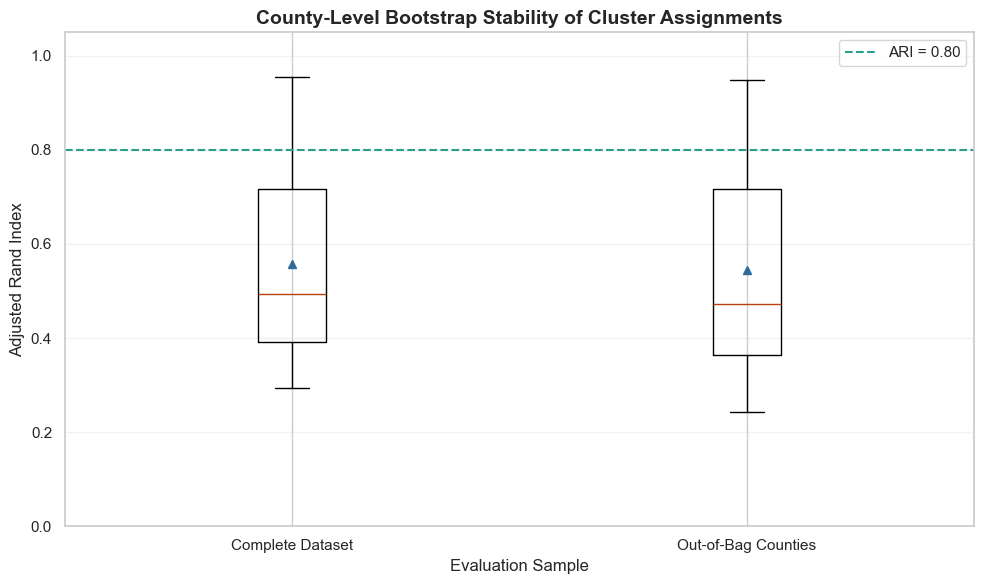

County-level bootstrap stability outputs saved successfully.
Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\county_level_bootstrap_cluster_stability.png


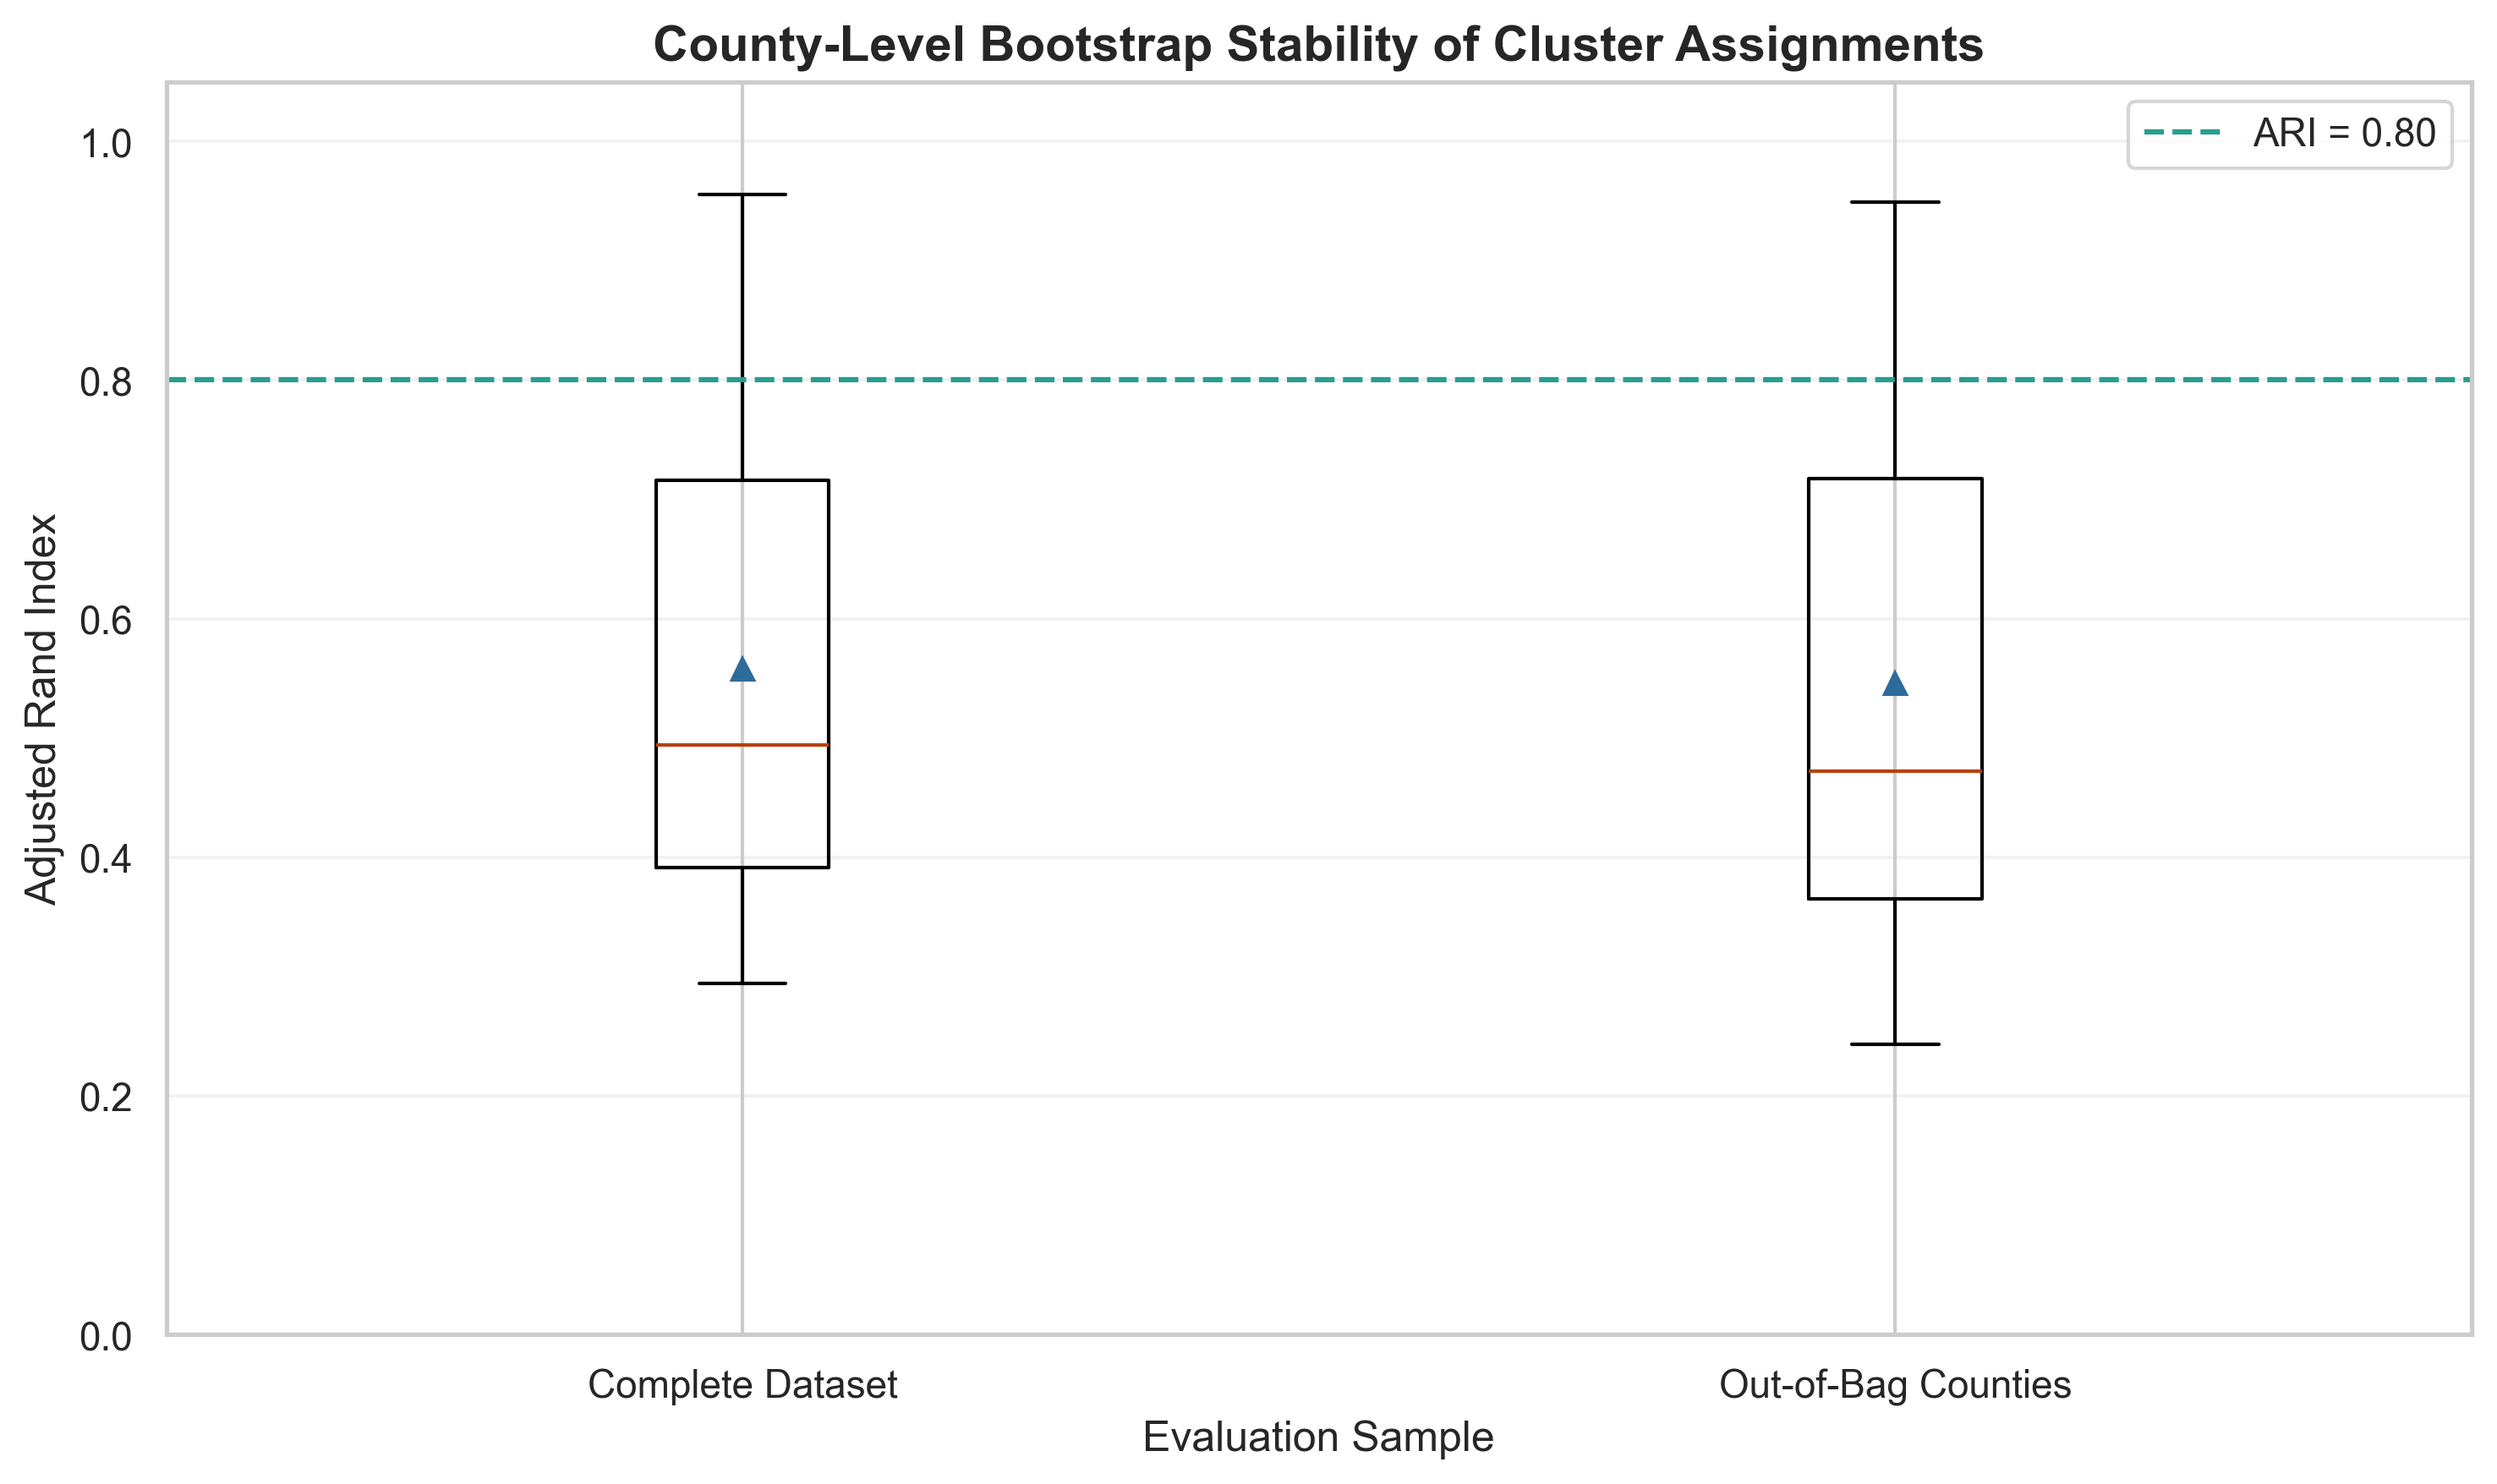

In [21]:
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

BOOTSTRAP_REPETITIONS = 100
BOOTSTRAP_RANDOM_SEED = 42
BOOTSTRAP_N_INIT = 50

# Prepare Original Data and Model Information

bootstrap_data = clustered_data.copy()

X_bootstrap_full = scaler.transform(bootstrap_data[CLUSTERING_FEATURES])

original_cluster_labels = bootstrap_data["cluster_id"].astype(int).to_numpy()

original_cluster_centers = final_kmeans_model.cluster_centers_.copy()

county_ids = bootstrap_data["STCOFIPS"].drop_duplicates().to_numpy()

county_row_indices = {
    county_id: np.flatnonzero(bootstrap_data["STCOFIPS"].to_numpy() == county_id)
    for county_id in county_ids
}

number_of_counties = len(county_ids)
number_of_observations = len(bootstrap_data)

print("County-level bootstrap stability analysis")
print(f"Unique counties: {number_of_counties}")
print(f"County-year observations: {number_of_observations}")
print(f"Bootstrap repetitions: {BOOTSTRAP_REPETITIONS}")

# Storage Objects

bootstrap_results = []

# Track how often every observation receives its
# original label when it is evaluated out of bag.
oob_match_counts = np.zeros(number_of_observations, dtype=float)

oob_evaluation_counts = np.zeros(number_of_observations, dtype=float)

rng = np.random.default_rng(BOOTSTRAP_RANDOM_SEED)

# Run County-Level Bootstrap

for repetition in range(BOOTSTRAP_REPETITIONS):

    # Sample complete counties with replacement
    sampled_counties = rng.choice(county_ids, size=number_of_counties, replace=True)

    # Include every county-year belonging to each
    # sampled county. Repeated counties receive
    # repeated representation in the bootstrap sample.
    sampled_row_indices = np.concatenate(
        [county_row_indices[county_id] for county_id in sampled_counties]
    )

    X_bootstrap_sample = X_bootstrap_full[sampled_row_indices]

    bootstrap_model = KMeans(
        n_clusters=FINAL_N_CLUSTERS,
        random_state=(BOOTSTRAP_RANDOM_SEED + repetition),
        n_init=BOOTSTRAP_N_INIT,
    )

    bootstrap_model.fit(X_bootstrap_sample)

    # Align Bootstrap Clusters with Original Profiles

    centroid_distance_matrix = np.linalg.norm(
        bootstrap_model.cluster_centers_[:, None, :]
        - original_cluster_centers[None, :, :],
        axis=2,
    )

    bootstrap_cluster_ids, original_ids = linear_sum_assignment(
        centroid_distance_matrix
    )

    bootstrap_to_original_mapping = {
        int(bootstrap_id): int(original_id)
        for bootstrap_id, original_id in zip(bootstrap_cluster_ids, original_ids)
    }

    # Predict assignments for the complete dataset
    raw_full_predictions = bootstrap_model.predict(X_bootstrap_full)

    aligned_full_predictions = np.array(
        [
            bootstrap_to_original_mapping[int(cluster_id)]
            for cluster_id in raw_full_predictions
        ]
    )

    # Full-Sample Stability

    full_sample_ari = adjusted_rand_score(
        original_cluster_labels, aligned_full_predictions
    )

    full_assignment_agreement = (
        aligned_full_predictions == original_cluster_labels
    ).mean()

    # Out-of-Bag Stability

    unique_sampled_counties = np.unique(sampled_counties)

    out_of_bag_counties = np.setdiff1d(county_ids, unique_sampled_counties)

    out_of_bag_mask = bootstrap_data["STCOFIPS"].isin(out_of_bag_counties).to_numpy()

    oob_original_labels = original_cluster_labels[out_of_bag_mask]

    oob_predicted_labels = aligned_full_predictions[out_of_bag_mask]

    if (
        out_of_bag_mask.sum() > 1
        and np.unique(oob_original_labels).size > 1
        and np.unique(oob_predicted_labels).size > 1
    ):
        oob_ari = adjusted_rand_score(oob_original_labels, oob_predicted_labels)
    else:
        oob_ari = np.nan

    oob_assignment_agreement = (
        (oob_original_labels == oob_predicted_labels).mean()
        if out_of_bag_mask.sum() > 0
        else np.nan
    )

    # Track observation-level out-of-bag stability
    oob_match_counts[out_of_bag_mask] += (
        oob_original_labels == oob_predicted_labels
    ).astype(float)

    oob_evaluation_counts[out_of_bag_mask] += 1

    # Align Bootstrap Centroids

    aligned_bootstrap_centers = np.empty_like(original_cluster_centers)

    for (
        bootstrap_cluster_id,
        original_cluster_id,
    ) in bootstrap_to_original_mapping.items():

        aligned_bootstrap_centers[original_cluster_id] = (
            bootstrap_model.cluster_centers_[bootstrap_cluster_id]
        )

    centroid_distances = np.linalg.norm(
        aligned_bootstrap_centers - original_cluster_centers, axis=1
    )

    repetition_result = {
        "bootstrap_repetition": repetition + 1,
        "unique_sampled_counties": len(unique_sampled_counties),
        "out_of_bag_counties": len(out_of_bag_counties),
        "full_sample_ari": full_sample_ari,
        "oob_ari": oob_ari,
        "full_assignment_agreement_pct": full_assignment_agreement * 100,
        "oob_assignment_agreement_pct": oob_assignment_agreement * 100,
        "mean_centroid_distance": centroid_distances.mean(),
        "maximum_centroid_distance": centroid_distances.max(),
    }

    for cluster_id in range(FINAL_N_CLUSTERS):
        repetition_result[f"centroid_distance_cluster_{cluster_id}"] = (
            centroid_distances[cluster_id]
        )

    bootstrap_results.append(repetition_result)

bootstrap_stability_results = pd.DataFrame(bootstrap_results)

print("\nCounty-level bootstrap repetitions completed.")

# Overall Bootstrap Summary

summary_metrics = [
    "full_sample_ari",
    "oob_ari",
    "full_assignment_agreement_pct",
    "oob_assignment_agreement_pct",
    "mean_centroid_distance",
    "maximum_centroid_distance",
]

bootstrap_stability_summary = (
    bootstrap_stability_results[summary_metrics]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T.rename(
        columns={
            "count": "valid_repetitions",
            "mean": "mean",
            "std": "standard_deviation",
            "min": "minimum",
            "5%": "p05",
            "25%": "p25",
            "50%": "median",
            "75%": "p75",
            "95%": "p95",
            "max": "maximum",
        }
    )
)

print("\nOverall bootstrap-stability summary")
display(bootstrap_stability_summary.round(4))

# Observation-Level Out-of-Bag Stability

observation_oob_stability = np.divide(
    oob_match_counts,
    oob_evaluation_counts,
    out=np.full(number_of_observations, np.nan, dtype=float),
    where=oob_evaluation_counts > 0,
)

bootstrap_assignment_stability = bootstrap_data[
    ["STCOFIPS", "RegionName", "Year", "cluster_id", "cluster_name"]
].copy()

bootstrap_assignment_stability["oob_evaluations"] = oob_evaluation_counts

bootstrap_assignment_stability["oob_assignment_stability_pct"] = (
    observation_oob_stability * 100
)

# Profile-Level Stability Summary

profile_stability_rows = []

for cluster_id in range(FINAL_N_CLUSTERS):

    cluster_mask = bootstrap_assignment_stability["cluster_id"] == cluster_id

    cluster_stability_values = bootstrap_assignment_stability.loc[
        cluster_mask, "oob_assignment_stability_pct"
    ].dropna()

    centroid_distance_column = f"centroid_distance_cluster_{cluster_id}"

    profile_stability_rows.append(
        {
            "cluster_id": cluster_id,
            "cluster_name": CLUSTER_NAMES[cluster_id],
            "county_year_observations": int(cluster_mask.sum()),
            "mean_oob_assignment_stability_pct": cluster_stability_values.mean(),
            "median_oob_assignment_stability_pct": cluster_stability_values.median(),
            "minimum_oob_assignment_stability_pct": cluster_stability_values.min(),
            "mean_centroid_distance": bootstrap_stability_results[
                centroid_distance_column
            ].mean(),
            "maximum_centroid_distance": bootstrap_stability_results[
                centroid_distance_column
            ].max(),
        }
    )

profile_bootstrap_stability = pd.DataFrame(profile_stability_rows)

print("\nBootstrap stability by vulnerability profile")
display(profile_bootstrap_stability.round(4))

# Additional Stability Indicators

bootstrap_indicator_table = pd.DataFrame(
    {
        "indicator": [
            "Bootstrap repetitions",
            "Mean full-sample ARI",
            "Minimum full-sample ARI",
            "Mean out-of-bag ARI",
            "Minimum out-of-bag ARI",
            "Mean full assignment agreement (%)",
            "Mean out-of-bag assignment agreement (%)",
            "Repetitions with full-sample ARI ≥ 0.80 (%)",
            "Repetitions with out-of-bag ARI ≥ 0.80 (%)",
        ],
        "value": [
            BOOTSTRAP_REPETITIONS,
            bootstrap_stability_results["full_sample_ari"].mean(),
            bootstrap_stability_results["full_sample_ari"].min(),
            bootstrap_stability_results["oob_ari"].mean(),
            bootstrap_stability_results["oob_ari"].min(),
            bootstrap_stability_results["full_assignment_agreement_pct"].mean(),
            bootstrap_stability_results["oob_assignment_agreement_pct"].mean(),
            (bootstrap_stability_results["full_sample_ari"] >= 0.80).mean() * 100,
            (bootstrap_stability_results["oob_ari"] >= 0.80).mean() * 100,
        ],
    }
)

print("\nKey bootstrap-stability indicators")
display(bootstrap_indicator_table.round(4))

# Visualize ARI Distribution

valid_oob_ari = bootstrap_stability_results["oob_ari"].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    [bootstrap_stability_results["full_sample_ari"], valid_oob_ari],
    labels=["Complete Dataset", "Out-of-Bag Counties"],
    showmeans=True,
)

ax.axhline(0.80, linestyle="--", linewidth=1.5, label="ARI = 0.80")

ax.set_title(
    "County-Level Bootstrap Stability of Cluster Assignments",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Evaluation Sample")
ax.set_ylabel("Adjusted Rand Index")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

bootstrap_stability_figure_path = (
    RESULTS_FIGURES / "county_level_bootstrap_cluster_stability.png"
)

plt.savefig(bootstrap_stability_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Save Bootstrap Stability Outputs

bootstrap_stability_results.to_csv(
    RESULTS_TABLES / "county_level_bootstrap_results.csv", index=False
)

bootstrap_stability_summary.to_csv(
    RESULTS_TABLES / "county_level_bootstrap_summary.csv"
)

profile_bootstrap_stability.to_csv(
    RESULTS_TABLES / "bootstrap_stability_by_profile.csv", index=False
)

bootstrap_indicator_table.to_csv(
    RESULTS_TABLES / "bootstrap_stability_key_indicators.csv", index=False
)

bootstrap_assignment_stability.to_csv(
    RESULTS_TABLES / "observation_level_oob_assignment_stability.csv", index=False
)

print("County-level bootstrap stability outputs saved successfully.")

print(f"Figure saved to: " f"{bootstrap_stability_figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "county_level_bootstrap_cluster_stability.png"),
        width=850,
    )
)


## 7. PCA interpretation

PCA provides a two-dimensional visualization of the seven-dimensional clustering space. PC1 and PC2 explain 54.92% of total variance, so apparent overlap in the plot does not imply that clusters are indistinguishable in the full feature space.


PCA completed successfully.
PC1 explained variance: 37.83%
PC2 explained variance: 17.09%
Total variance explained by PC1 and PC2: 54.92%


,principal_component,explained_variance_pct
0,PC1,37.8340
1,PC2,17.0863



PCA loadings


,PC1,PC2
affordability_stress_score,0.4824,0.2542
climate_exposure_score,0.4299,0.3170
disaster_history_score,0.2939,-0.0730
socioeconomic_vulnerability_score,-0.3644,0.5567
resilience_adjustment_score,-0.2511,0.6593
insurance_loss_stress_score,0.4910,0.1404
spatial_spillover_score,0.2431,0.2552


Dimensions contributing most strongly to PC1


,PC1,PC1_absolute
insurance_loss_stress_score,0.4910,0.4910
affordability_stress_score,0.4824,0.4824
climate_exposure_score,0.4299,0.4299
socioeconomic_vulnerability_score,-0.3644,0.3644
disaster_history_score,0.2939,0.2939
resilience_adjustment_score,-0.2511,0.2511
spatial_spillover_score,0.2431,0.2431


Dimensions contributing most strongly to PC2


,PC2,PC2_absolute
resilience_adjustment_score,0.6593,0.6593
socioeconomic_vulnerability_score,0.5567,0.5567
climate_exposure_score,0.3170,0.3170
spatial_spillover_score,0.2552,0.2552
affordability_stress_score,0.2542,0.2542
insurance_loss_stress_score,0.1404,0.1404
disaster_history_score,-0.0730,0.0730



Cluster centroids in PCA space


,cluster_id,cluster_name,PC1,PC2
0,0,Lower-Stress Resilient Profile,0.4514,-1.6465
1,1,Disaster-Loss Growth Pressure,1.8495,0.1894
2,2,High-Exposure Latent Risk,0.6593,0.6194
3,3,Socioeconomic Resilience Stress,-1.7449,0.1963


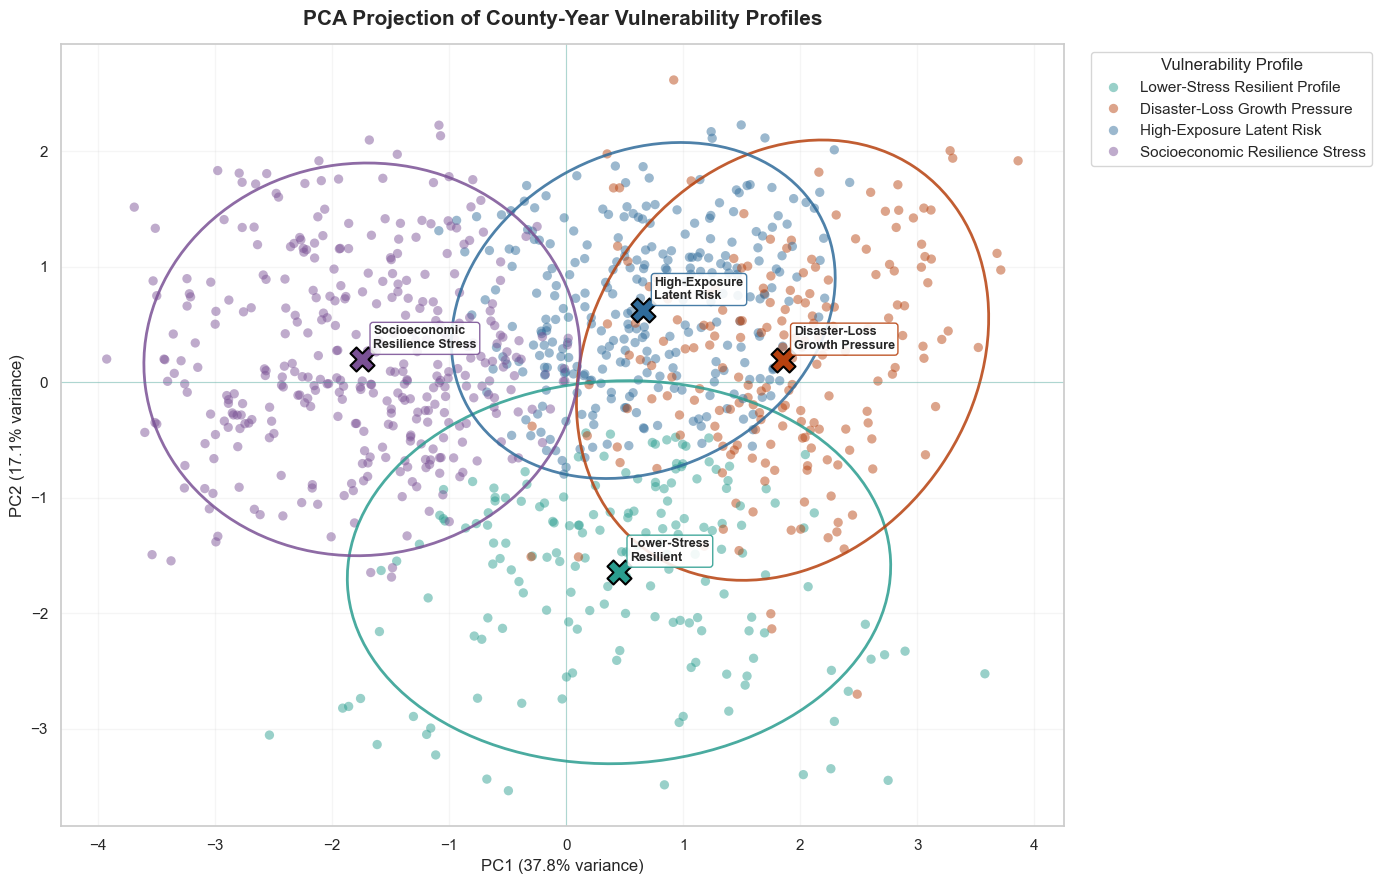

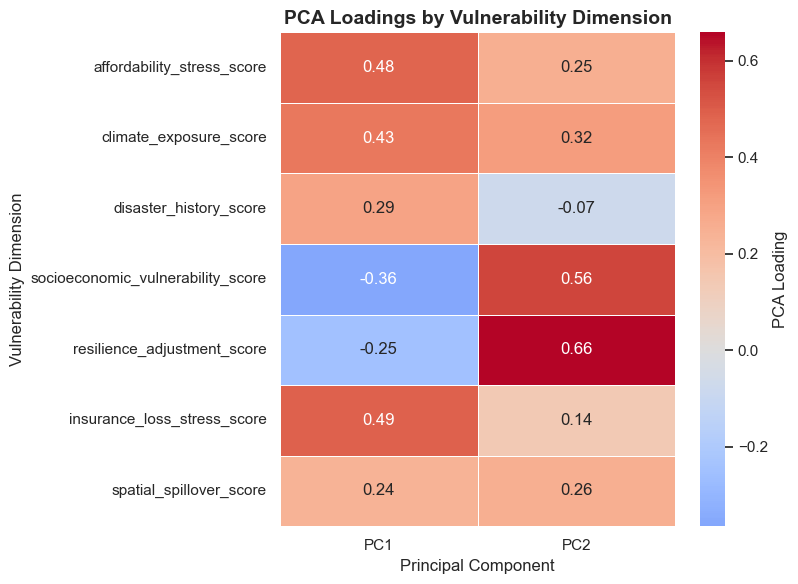

Improved PCA outputs saved successfully.
PCA cluster figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\pca_vulnerability_profiles_with_ellipses.png
PCA loading figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\pca_vulnerability_dimension_loadings.png


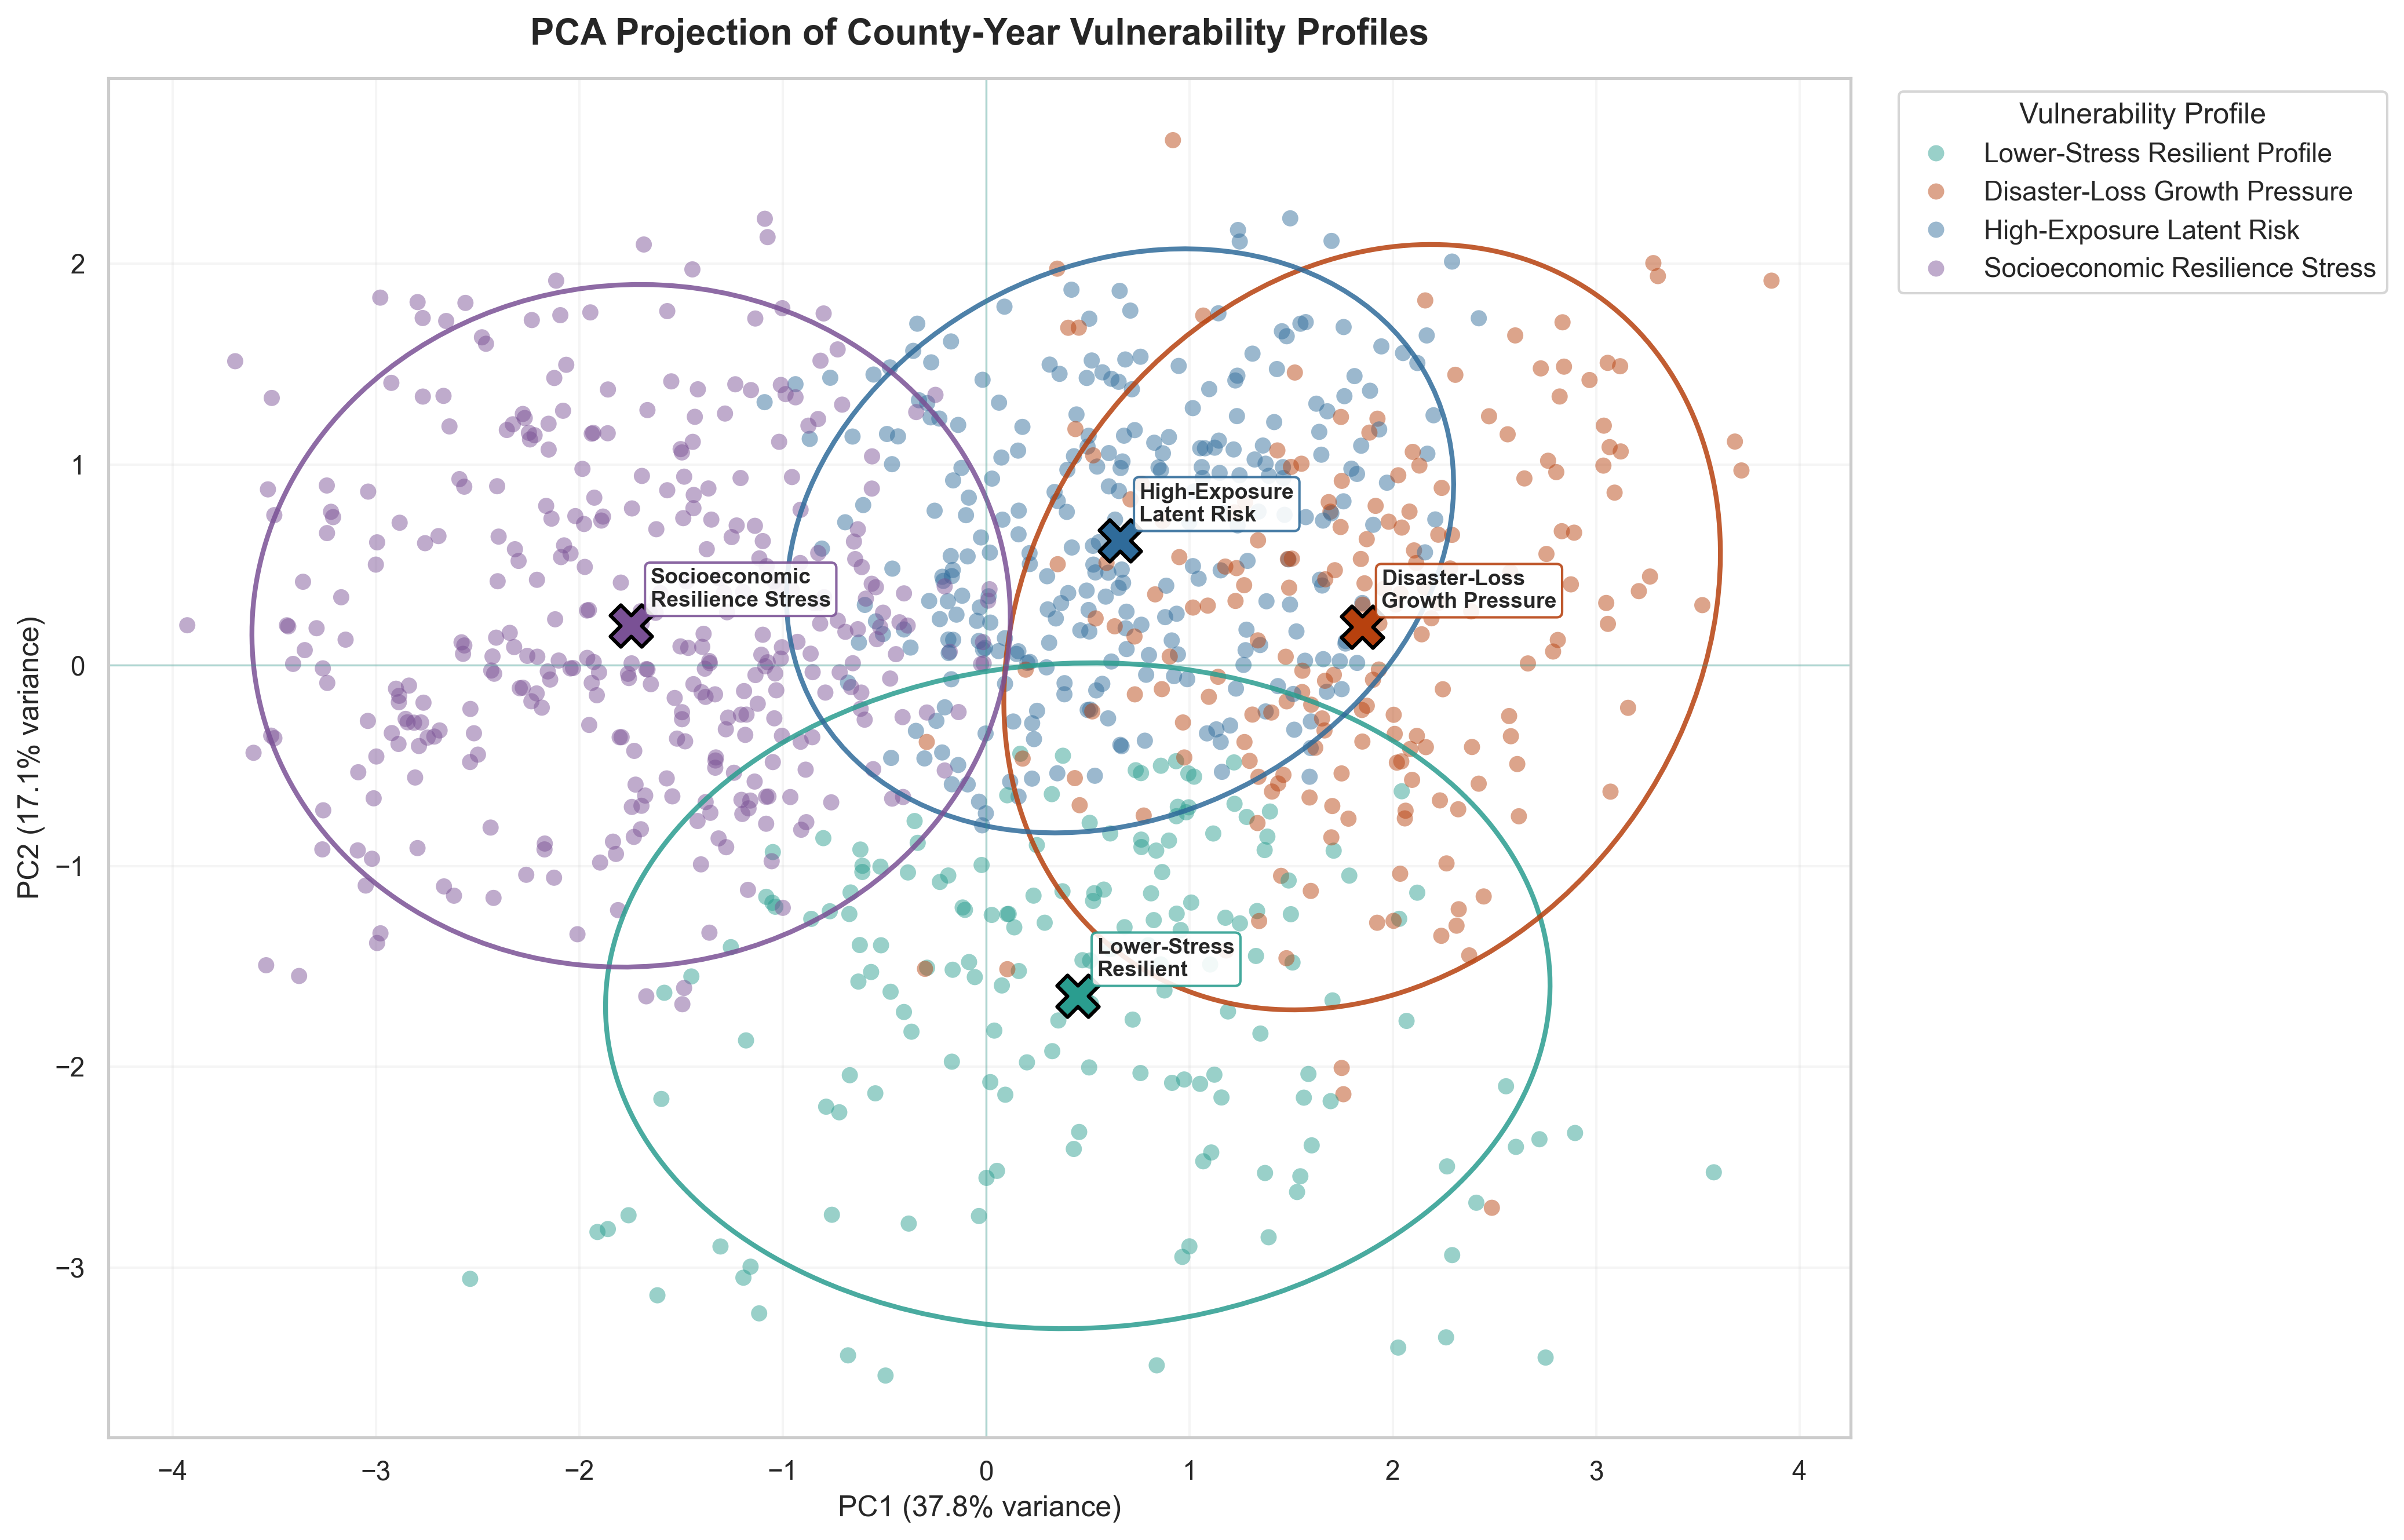

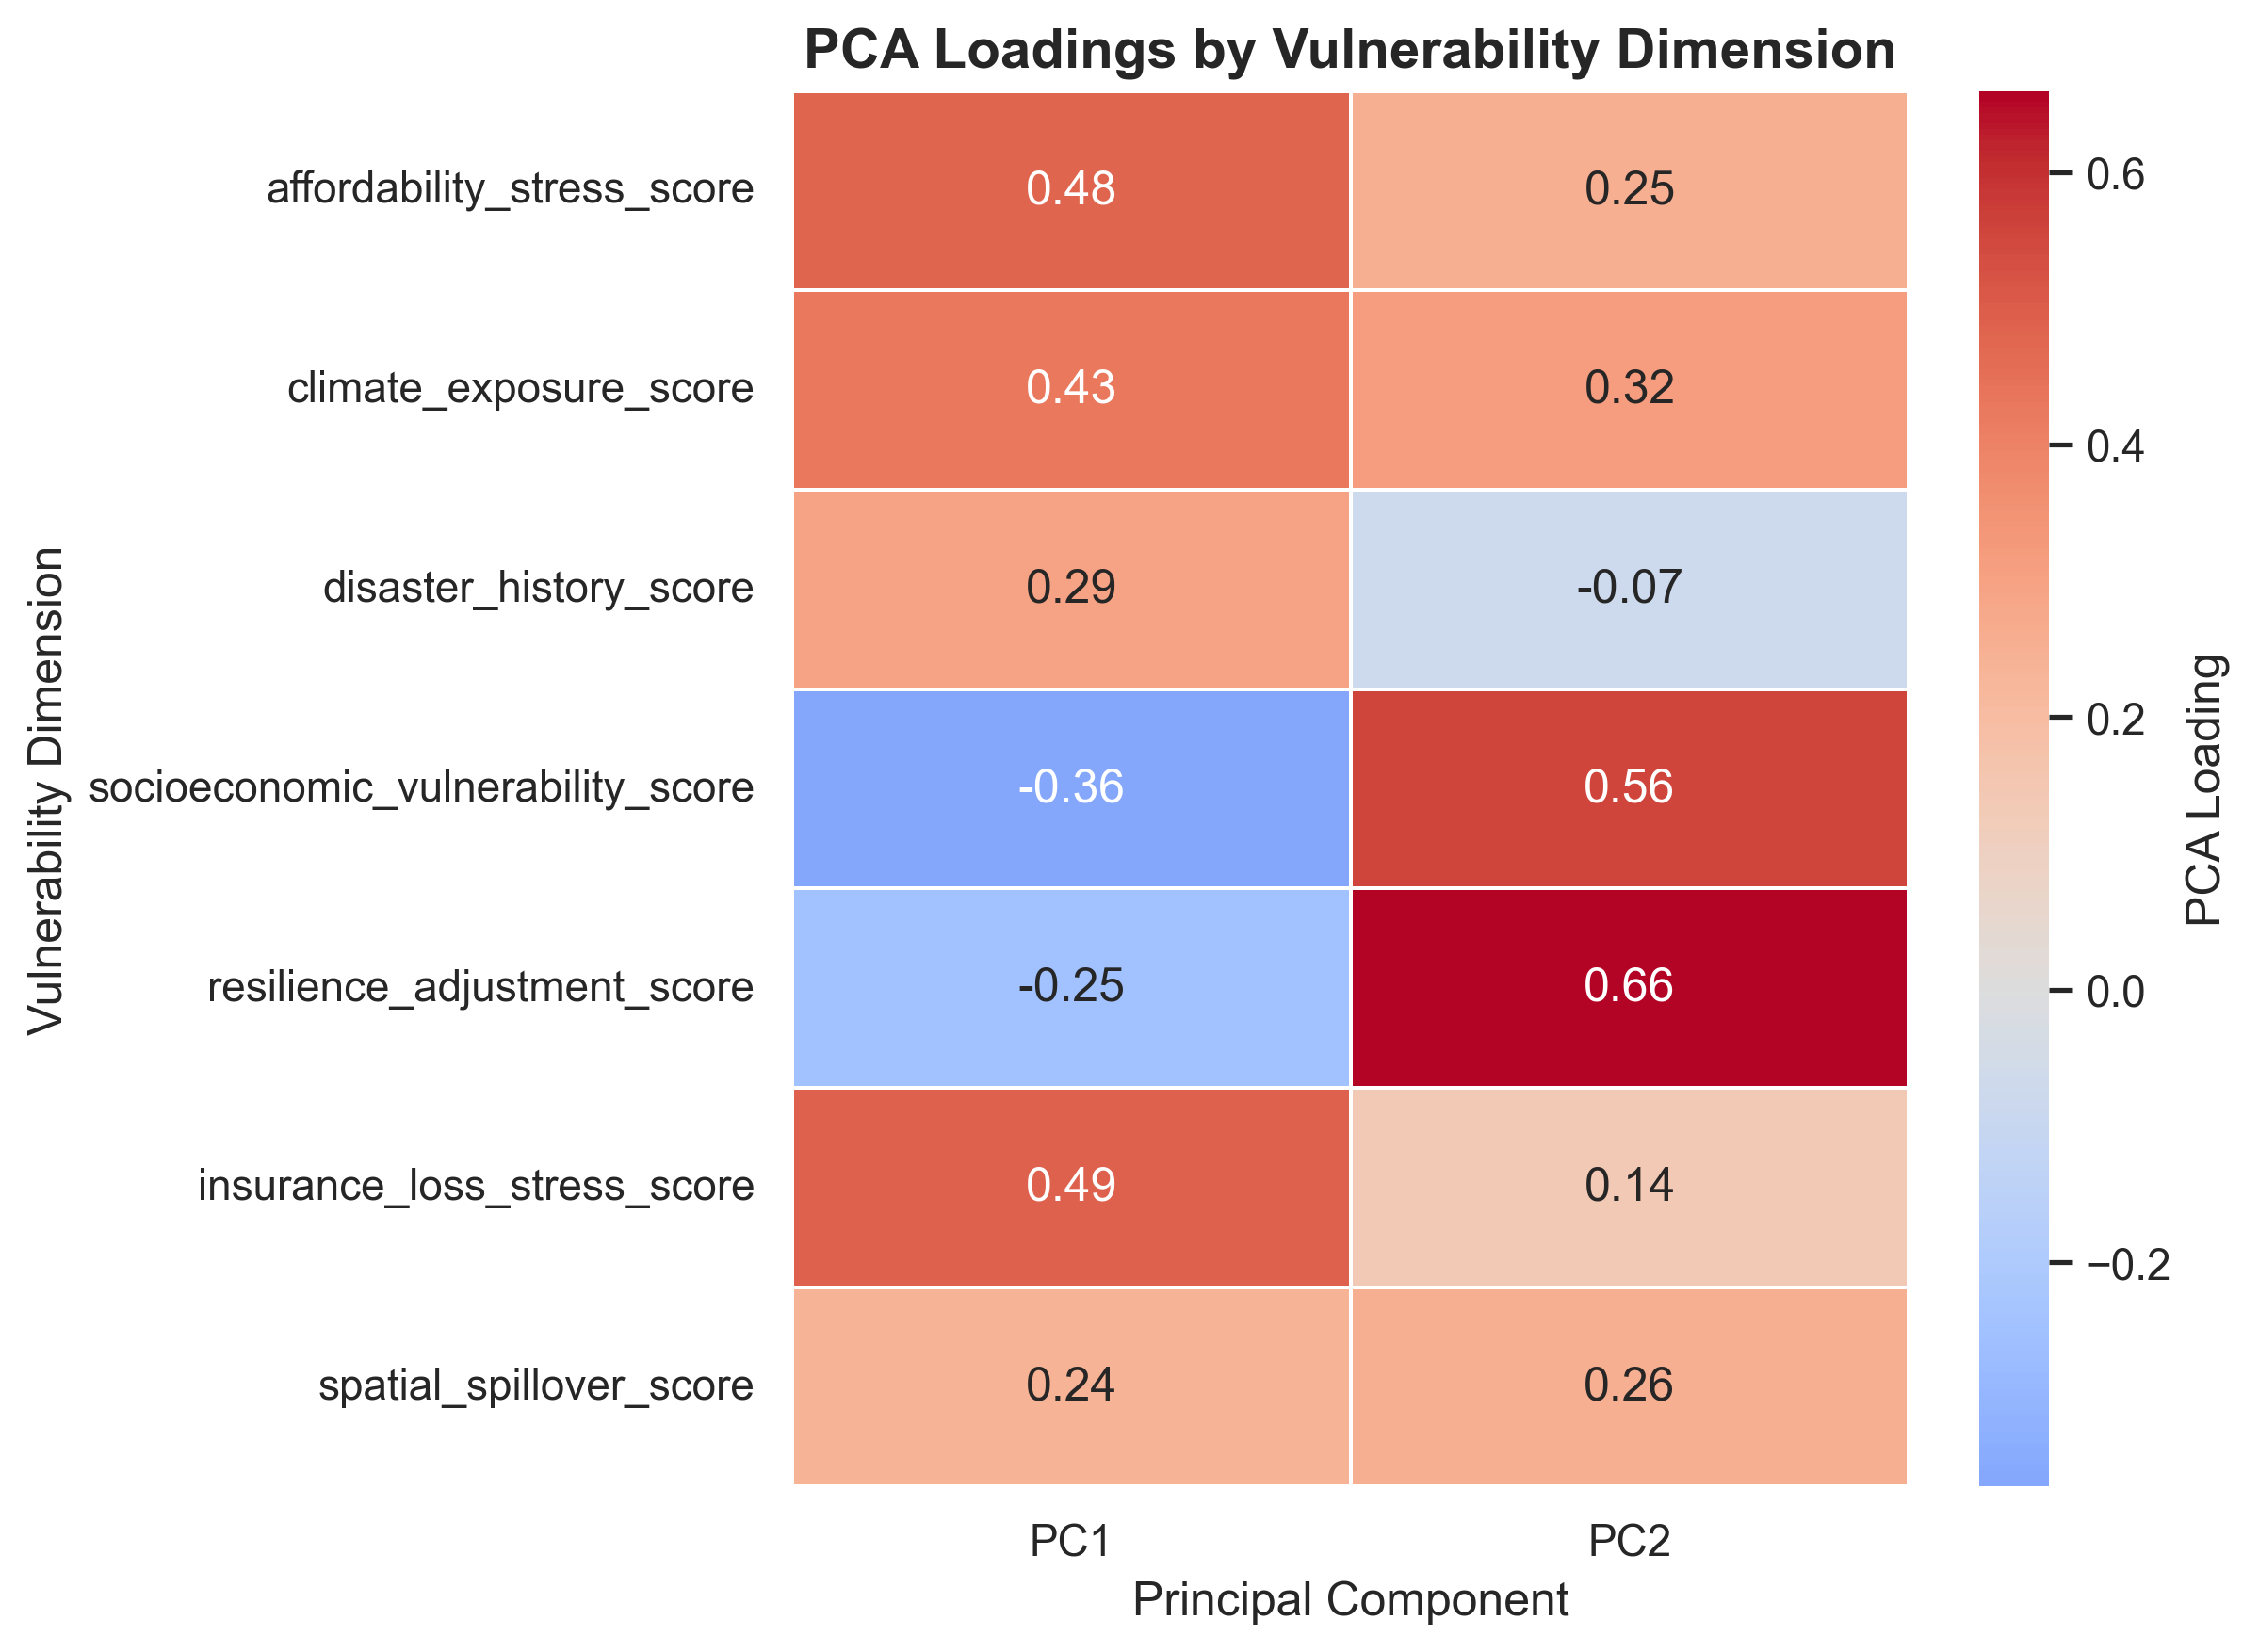

In [22]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2
import textwrap

# Fit Two-Component PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)

pca_coordinates = pca.fit_transform(X_scaled)

clustered_data["PC1"] = pca_coordinates[:, 0]
clustered_data["PC2"] = pca_coordinates[:, 1]

explained_variance_table = pd.DataFrame(
    {
        "principal_component": ["PC1", "PC2"],
        "explained_variance_pct": (pca.explained_variance_ratio_ * 100),
    }
)

total_explained_variance = pca.explained_variance_ratio_.sum() * 100

print("PCA completed successfully.")

print(
    f"PC1 explained variance: "
    f"{explained_variance_table.loc[0, 'explained_variance_pct']:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance_table.loc[1, 'explained_variance_pct']:.2f}%"
)

print(f"Total variance explained by PC1 and PC2: " f"{total_explained_variance:.2f}%")

display(explained_variance_table.round(4))

# Calculate PCA Loadings
#
# Each loading shows how strongly one clustering
# dimension contributes to a principal component.
# Positive and negative signs indicate direction,
# while larger absolute values indicate greater
# influence.

pca_loadings_table = pd.DataFrame(
    pca.components_.T, index=CLUSTERING_FEATURES, columns=["PC1", "PC2"]
)

pca_loadings_table["PC1_absolute"] = pca_loadings_table["PC1"].abs()

pca_loadings_table["PC2_absolute"] = pca_loadings_table["PC2"].abs()

print("\nPCA loadings")
display(pca_loadings_table[["PC1", "PC2"]].round(4))

print("Dimensions contributing most strongly to PC1")
display(
    pca_loadings_table[["PC1", "PC1_absolute"]]
    .sort_values("PC1_absolute", ascending=False)
    .round(4)
)

print("Dimensions contributing most strongly to PC2")
display(
    pca_loadings_table[["PC2", "PC2_absolute"]]
    .sort_values("PC2_absolute", ascending=False)
    .round(4)
)

# Transform Cluster Centroids into PCA Space

pca_cluster_centers = pca.transform(final_kmeans_model.cluster_centers_)

pca_centers_table = pd.DataFrame(
    {
        "cluster_id": range(FINAL_N_CLUSTERS),
        "cluster_name": [
            CLUSTER_NAMES[cluster_id] for cluster_id in range(FINAL_N_CLUSTERS)
        ],
        "PC1": pca_cluster_centers[:, 0],
        "PC2": pca_cluster_centers[:, 1],
    }
)

print("\nCluster centroids in PCA space")
display(pca_centers_table.round(4))

# Function for Confidence Ellipses


def add_confidence_ellipse(
    axis,
    x_values,
    y_values,
    edge_color,
    confidence_level=0.90,
    line_width=2.0,
    transparency=0.85,
):
    """
    Draw a covariance-based confidence ellipse.

    Parameters
    ----------
    axis:
        Matplotlib axis.
    x_values, y_values:
        PCA coordinates for one cluster.
    edge_color:
        Colour used for the ellipse outline.
    confidence_level:
        Proportion represented by the ellipse.
    """

    x_values = np.asarray(x_values)
    y_values = np.asarray(y_values)

    if len(x_values) < 3:
        return

    covariance_matrix = np.cov(x_values, y_values)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    order = eigenvalues.argsort()[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    confidence_scale = np.sqrt(chi2.ppf(confidence_level, df=2))

    width = 2 * confidence_scale * np.sqrt(eigenvalues[0])

    height = 2 * confidence_scale * np.sqrt(eigenvalues[1])

    ellipse = Ellipse(
        xy=(x_values.mean(), y_values.mean()),
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=edge_color,
        linewidth=line_width,
        alpha=transparency,
    )

    axis.add_patch(ellipse)


# Create Consistent Profile Colours

cluster_name_order = [
    CLUSTER_NAMES[cluster_id] for cluster_id in range(FINAL_N_CLUSTERS)
]

cluster_palette_values = PROFILE_COLORS

cluster_palette = {
    cluster_name: cluster_palette_values[index]
    for index, cluster_name in enumerate(cluster_name_order)
}

# Shorter labels for centroid annotations
centroid_labels = {
    "Lower-Stress Resilient Profile": "Lower-Stress\nResilient",
    "Disaster-Loss Growth Pressure": "Disaster-Loss\nGrowth Pressure",
    "High-Exposure Latent Risk": "High-Exposure\nLatent Risk",
    "Socioeconomic Resilience Stress": "Socioeconomic\nResilience Stress",
}

# Improved PCA Cluster Plot

fig, ax = plt.subplots(figsize=(14, 9))

sns.scatterplot(
    data=clustered_data,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_name_order,
    palette=cluster_palette,
    alpha=0.48,
    s=45,
    linewidth=0,
    ax=ax,
)

# Add one confidence ellipse per profile
for cluster_name in cluster_name_order:

    cluster_points = clustered_data[clustered_data["cluster_name"] == cluster_name]

    add_confidence_ellipse(
        axis=ax,
        x_values=cluster_points["PC1"],
        y_values=cluster_points["PC2"],
        edge_color=cluster_palette[cluster_name],
        confidence_level=0.90,
    )

# Plot cluster centroids
for _, centroid_row in pca_centers_table.iterrows():

    cluster_name = centroid_row["cluster_name"]

    ax.scatter(
        centroid_row["PC1"],
        centroid_row["PC2"],
        marker="X",
        s=300,
        color=cluster_palette[cluster_name],
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )

    ax.annotate(
        centroid_labels.get(
            cluster_name, "\n".join(textwrap.wrap(cluster_name, width=20))
        ),
        xy=(centroid_row["PC1"], centroid_row["PC2"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": cluster_palette[cluster_name],
            "alpha": 0.88,
        },
        zorder=6,
    )

ax.axhline(0, linewidth=0.8, alpha=0.35)

ax.axvline(0, linewidth=0.8, alpha=0.35)

ax.set_title(
    "PCA Projection of County-Year Vulnerability Profiles",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(f"PC1 " f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

ax.set_ylabel(f"PC2 " f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

ax.legend(
    title="Vulnerability Profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

ax.grid(alpha=0.18)

plt.tight_layout()

improved_pca_figure_path = (
    RESULTS_FIGURES / "pca_vulnerability_profiles_with_ellipses.png"
)

plt.savefig(improved_pca_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# PCA Loading Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    pca_loadings_table[["PC1", "PC2"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "PCA Loading"},
)

plt.title("PCA Loadings by Vulnerability Dimension", fontsize=14, fontweight="bold")

plt.xlabel("Principal Component")
plt.ylabel("Vulnerability Dimension")

plt.tight_layout()

pca_loadings_figure_path = RESULTS_FIGURES / "pca_vulnerability_dimension_loadings.png"

plt.savefig(pca_loadings_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Save PCA Outputs

explained_variance_table.to_csv(
    RESULTS_TABLES / "pca_explained_variance.csv", index=False
)

pca_loadings_table.to_csv(RESULTS_TABLES / "pca_component_loadings.csv")

pca_centers_table.to_csv(RESULTS_TABLES / "pca_cluster_centroids.csv", index=False)

print("Improved PCA outputs saved successfully.")

print(f"PCA cluster figure saved to: " f"{improved_pca_figure_path}")

print(f"PCA loading figure saved to: " f"{pca_loadings_figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "pca_vulnerability_profiles_with_ellipses.png"),
        width=850,
    )
)
display(
    Image(
        filename=str(RESULTS_FIGURES / "pca_vulnerability_dimension_loadings.png"),
        width=850,
    )
)


## 8. County membership and representative cases

County-level summaries describe dominant profiles, persistence, transitions, and representative county-years closest to each centroid. Recent summaries use 2021–2025 to align the profile interpretation with the later study period.


In [23]:
latest_year = clustered_data["Year"].max()
recent_start_year = latest_year - 4

recent_cluster_data = (
    clustered_data[clustered_data["Year"].between(recent_start_year, latest_year)]
    .sort_values(["STCOFIPS", "Year"])
    .copy()
)

# Latest-Year Cluster

latest_year_membership = clustered_data[clustered_data["Year"] == latest_year][
    [
        "STCOFIPS",
        "RegionName",
        "cluster_id",
        "cluster_name",
        "climate_housing_vulnerability_score",
        "vulnerability_class",
        "annual_price_growth_pct",
    ]
].rename(
    columns={
        "cluster_id": "latest_cluster_id",
        "cluster_name": "latest_cluster_name",
        "climate_housing_vulnerability_score": "latest_vulnerability_score",
        "vulnerability_class": "latest_vulnerability_class",
        "annual_price_growth_pct": "latest_annual_growth_pct",
    }
)

# Dominant Recent Cluster

recent_cluster_counts = (
    recent_cluster_data.groupby(
        ["STCOFIPS", "RegionName", "cluster_id", "cluster_name"]
    )
    .size()
    .reset_index(name="years_in_cluster")
)

recent_cluster_totals = (
    recent_cluster_data.groupby(["STCOFIPS", "RegionName"])
    .size()
    .reset_index(name="recent_years_observed")
)

recent_cluster_counts = recent_cluster_counts.merge(
    recent_cluster_totals, on=["STCOFIPS", "RegionName"], how="left"
)

recent_cluster_counts["recent_cluster_share_pct"] = (
    recent_cluster_counts["years_in_cluster"]
    / recent_cluster_counts["recent_years_observed"]
    * 100
)

dominant_recent_cluster = (
    recent_cluster_counts.sort_values(
        ["STCOFIPS", "years_in_cluster", "cluster_id"], ascending=[True, False, True]
    )
    .drop_duplicates("STCOFIPS")
    .rename(
        columns={
            "cluster_id": "dominant_recent_cluster_id",
            "cluster_name": "dominant_recent_cluster_name",
        }
    )
)

# Recent Cluster Transitions

recent_transition_summary = (
    recent_cluster_data.groupby("STCOFIPS")["cluster_id"]
    .apply(lambda values: values.ne(values.shift()).sum() - 1)
    .clip(lower=0)
    .rename("recent_cluster_transitions")
    .reset_index()
)

# Final County Membership Table

county_cluster_membership = (
    latest_year_membership.merge(
        dominant_recent_cluster[
            [
                "STCOFIPS",
                "dominant_recent_cluster_id",
                "dominant_recent_cluster_name",
                "years_in_cluster",
                "recent_years_observed",
                "recent_cluster_share_pct",
            ]
        ],
        on="STCOFIPS",
        how="left",
    )
    .merge(recent_transition_summary, on="STCOFIPS", how="left")
    .sort_values(["latest_cluster_id", "RegionName"])
)

county_cluster_membership["recent_cluster_share_pct"] = county_cluster_membership[
    "recent_cluster_share_pct"
].round(2)

print("County cluster membership summarized successfully.")
print(f"Recent period: {recent_start_year}–{latest_year}")
print(f"Counties summarized: " f"{county_cluster_membership['STCOFIPS'].nunique()}")

display(county_cluster_membership.head(15))

county_cluster_membership.to_csv(
    RESULTS_TABLES / "county_cluster_membership.csv", index=False
)

print(
    "County membership table saved to: "
    f"{RESULTS_TABLES / 'county_cluster_membership.csv'}"
)


County cluster membership summarized successfully.
Recent period: 2021–2025
Counties summarized: 67


,STCOFIPS,RegionName,latest_cluster_id,latest_cluster_name,latest_vulnerability_score,latest_vulnerability_class,latest_annual_growth_pct,dominant_recent_cluster_id,dominant_recent_cluster_name,years_in_cluster,recent_years_observed,recent_cluster_share_pct,recent_cluster_transitions
0,12001,Alachua County,0,Lower-Stress Resilient Profile,0.3564,Low,-1.5900,0,Lower-Stress Resilient Profile,3,5,60.0000,4
1,12003,Baker County,0,Lower-Stress Resilient Profile,0.2720,Low,0.9194,0,Lower-Stress Resilient Profile,5,5,100.0000,0
4,12009,Brevard County,0,Lower-Stress Resilient Profile,0.4965,Medium,-3.6820,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
9,12019,Clay County,0,Lower-Stress Resilient Profile,0.4119,Low,-2.0607,0,Lower-Stress Resilient Profile,3,5,60.0000,4
14,12031,Duval County,0,Lower-Stress Resilient Profile,0.4586,Medium,-3.2685,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
16,12035,Flagler County,0,Lower-Stress Resilient Profile,0.4460,Medium,-4.7733,1,Disaster-Loss Growth Pressure,3,5,60.0000,2
17,12037,Franklin County,0,Lower-Stress Resilient Profile,0.4446,Medium,-4.6156,1,Disaster-Loss Growth Pressure,4,5,80.0000,1
21,12045,Gulf County,0,Lower-Stress Resilient Profile,0.4205,Low,-3.4721,1,Disaster-Loss Growth Pressure,4,5,80.0000,1
29,12061,Indian River County,0,Lower-Stress Resilient Profile,0.4585,Medium,-4.6872,0,Lower-Stress Resilient Profile,3,5,60.0000,4
33,12069,Lake County,0,Lower-Stress Resilient Profile,0.4585,Medium,-2.1511,1,Disaster-Loss Growth Pressure,3,5,60.0000,2


County membership table saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering\county_cluster_membership.csv


In [24]:
# Identify Representative Counties for Each Profile

REPRESENTATIVE_COUNTIES_PER_PROFILE = 5
RECENT_PROFILE_START_YEAR = 2021
RECENT_PROFILE_END_YEAR = 2025

# Calculate Distance to Assigned Cluster Centroid

X_profile_scaled = scaler.transform(clustered_data[CLUSTERING_FEATURES])

assigned_cluster_ids = clustered_data["cluster_id"].astype(int).to_numpy()

assigned_centroids = final_kmeans_model.cluster_centers_[assigned_cluster_ids]

distance_to_assigned_centroid = np.linalg.norm(
    X_profile_scaled - assigned_centroids, axis=1
)

# Include available housing and vulnerability outcomes
possible_context_columns = [
    "annual_price_growth_pct",
    "avg_annual_housing_price",
    "annual_price_volatility",
    "housing_pressure_score",
    "climate_housing_vulnerability_score",
    "vulnerability_class",
]

context_columns = [
    column for column in possible_context_columns if column in clustered_data.columns
]

representative_columns = list(
    dict.fromkeys(
        ["STCOFIPS", "RegionName", "Year", "cluster_id", "cluster_name"]
        + CLUSTERING_FEATURES
        + context_columns
    )
)

cluster_representative_data = clustered_data[representative_columns].copy()

cluster_representative_data["distance_to_cluster_centroid"] = (
    distance_to_assigned_centroid
)

# Five Closest Unique Counties Per Cluster
#
# First retain the closest observation for each county
# within each cluster. Then select the five closest
# unique counties for every profile.

representative_county_years = (
    cluster_representative_data.sort_values(
        ["cluster_id", "distance_to_cluster_centroid", "RegionName", "Year"]
    )
    .drop_duplicates(subset=["cluster_id", "STCOFIPS"], keep="first")
    .groupby("cluster_id", group_keys=False)
    .head(REPRESENTATIVE_COUNTIES_PER_PROFILE)
    .reset_index(drop=True)
)

# Rank representatives within each cluster
representative_county_years["representative_rank"] = (
    representative_county_years.groupby("cluster_id").cumcount() + 1
)

# Latest-Year Cluster Membership

latest_profile_year = int(clustered_data["Year"].max())

latest_year_cluster_members = cluster_representative_data[
    cluster_representative_data["Year"] == latest_profile_year
].copy()

latest_year_cluster_counts = (
    latest_year_cluster_members.groupby(["cluster_id", "cluster_name"], as_index=False)
    .agg(counties_in_latest_year=("STCOFIPS", "nunique"))
    .sort_values("cluster_id")
)

# Select five latest-year examples closest to each centroid
latest_year_representatives = (
    latest_year_cluster_members.sort_values(
        ["cluster_id", "distance_to_cluster_centroid", "RegionName"]
    )
    .groupby("cluster_id", group_keys=False)
    .head(REPRESENTATIVE_COUNTIES_PER_PROFILE)
    .reset_index(drop=True)
)

latest_year_representatives["latest_year_rank"] = (
    latest_year_representatives.groupby("cluster_id").cumcount() + 1
)

# Dominant Recent Profile for Every County

recent_profile_data = cluster_representative_data[
    cluster_representative_data["Year"].between(
        RECENT_PROFILE_START_YEAR, RECENT_PROFILE_END_YEAR
    )
].copy()

recent_county_year_totals = recent_profile_data.groupby(
    ["STCOFIPS", "RegionName"], as_index=False
).agg(recent_years_observed=("Year", "nunique"))

recent_profile_membership = (
    recent_profile_data.groupby(
        ["STCOFIPS", "RegionName", "cluster_id", "cluster_name"], as_index=False
    )
    .agg(
        years_in_profile=("Year", "nunique"),
        average_centroid_distance=("distance_to_cluster_centroid", "mean"),
    )
    .merge(recent_county_year_totals, on=["STCOFIPS", "RegionName"], how="left")
)

recent_profile_membership["profile_persistence_pct"] = (
    recent_profile_membership["years_in_profile"]
    / recent_profile_membership["recent_years_observed"]
    * 100
)

# Choose the most frequent recent profile.
# Ties are resolved using the smaller average
# distance to the relevant cluster centroid.
dominant_recent_profiles = (
    recent_profile_membership.sort_values(
        ["STCOFIPS", "years_in_profile", "average_centroid_distance", "cluster_id"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates(subset="STCOFIPS", keep="first")
    .rename(
        columns={
            "cluster_id": "dominant_recent_cluster_id",
            "cluster_name": "dominant_recent_cluster_name",
            "years_in_profile": "years_in_dominant_profile",
            "profile_persistence_pct": "dominant_profile_persistence_pct",
        }
    )
    .reset_index(drop=True)
)

# Recent Dominant-Profile Summary

recent_dominant_profile_summary = (
    dominant_recent_profiles.groupby(
        ["dominant_recent_cluster_id", "dominant_recent_cluster_name"], as_index=False
    )
    .agg(
        counties=("STCOFIPS", "nunique"),
        mean_persistence_pct=("dominant_profile_persistence_pct", "mean"),
        median_persistence_pct=("dominant_profile_persistence_pct", "median"),
        counties_with_100_pct_persistence=(
            "dominant_profile_persistence_pct",
            lambda values: int((values == 100).sum()),
        ),
    )
    .sort_values("dominant_recent_cluster_id")
)

# Most Persistent Recent County Examples

persistent_recent_examples = (
    dominant_recent_profiles.sort_values(
        [
            "dominant_recent_cluster_id",
            "dominant_profile_persistence_pct",
            "average_centroid_distance",
            "RegionName",
        ],
        ascending=[True, False, True, True],
    )
    .groupby("dominant_recent_cluster_id", group_keys=False)
    .head(REPRESENTATIVE_COUNTIES_PER_PROFILE)
    .reset_index(drop=True)
)

persistent_recent_examples["recent_example_rank"] = (
    persistent_recent_examples.groupby("dominant_recent_cluster_id").cumcount() + 1
)

# Display Representative Results

representative_display_columns = [
    "cluster_name",
    "representative_rank",
    "RegionName",
    "Year",
    "distance_to_cluster_centroid",
] + context_columns

print("Representative county-year observations " "closest to each cluster centroid")

display(representative_county_years[representative_display_columns].round(4))

print(f"Latest-year cluster membership summary " f"({latest_profile_year})")

display(latest_year_cluster_counts)

latest_display_columns = [
    "cluster_name",
    "latest_year_rank",
    "RegionName",
    "Year",
    "distance_to_cluster_centroid",
] + context_columns

print(f"Representative counties in " f"{latest_profile_year}")

display(latest_year_representatives[latest_display_columns].round(4))

print(
    f"Dominant county profiles, "
    f"{RECENT_PROFILE_START_YEAR}–"
    f"{RECENT_PROFILE_END_YEAR}"
)

display(recent_dominant_profile_summary.round(4))

print("Most persistent recent examples " "within each dominant profile")

display(
    persistent_recent_examples[
        [
            "dominant_recent_cluster_name",
            "recent_example_rank",
            "RegionName",
            "years_in_dominant_profile",
            "recent_years_observed",
            "dominant_profile_persistence_pct",
            "average_centroid_distance",
        ]
    ].round(4)
)

# Save Representative County Outputs

representative_county_years.to_csv(
    RESULTS_TABLES / "representative_county_years_by_cluster.csv", index=False
)

latest_year_cluster_members.to_csv(
    RESULTS_TABLES / f"cluster_membership_{latest_profile_year}.csv", index=False
)

latest_year_representatives.to_csv(
    RESULTS_TABLES / f"representative_counties_{latest_profile_year}.csv", index=False
)

dominant_recent_profiles.to_csv(
    RESULTS_TABLES / "dominant_recent_county_profiles_2021_2025.csv", index=False
)

recent_dominant_profile_summary.to_csv(
    RESULTS_TABLES / "dominant_recent_profile_summary_2021_2025.csv", index=False
)

persistent_recent_examples.to_csv(
    RESULTS_TABLES / "persistent_recent_county_examples.csv", index=False
)

print("Representative county outputs saved successfully.")


Representative county-year observations closest to each cluster centroid


,cluster_name,representative_rank,RegionName,Year,distance_to_cluster_centroid,annual_price_growth_pct,avg_annual_housing_price,annual_price_volatility,housing_pressure_score,climate_housing_vulnerability_score,vulnerability_class
0,Lower-Stress Resilient Profile,1,Clay County,2019,1.0244,6.6162,"217,449.3908","3,348.9831",0.4220,0.4089,Low
1,Lower-Stress Resilient Profile,2,Sumter County,2019,1.0360,6.4101,"278,112.9208","4,006.0340",0.4551,0.4089,Low
2,Lower-Stress Resilient Profile,3,Nassau County,2014,1.0690,8.3172,"213,376.5308","3,308.6736",0.4315,0.3754,Low
3,Lower-Stress Resilient Profile,4,Lake County,2019,1.2121,6.8225,"235,308.5177","3,377.7592",0.4504,0.4608,Medium
4,Lower-Stress Resilient Profile,5,Seminole County,2019,1.2259,6.5878,"258,205.9848","4,639.5255",0.4673,0.3883,Low
5,Disaster-Loss Growth Pressure,1,Flagler County,2019,0.8848,5.3917,"241,736.9425","2,932.4721",0.4391,0.5147,Medium
6,Disaster-Loss Growth Pressure,2,Franklin County,2023,1.1582,-0.9999,"426,630.7885","5,746.4783",0.3887,0.5227,High
7,Disaster-Loss Growth Pressure,3,Martin County,2017,1.1587,8.1065,"255,887.8286","4,479.0729",0.4498,0.5426,High
8,Disaster-Loss Growth Pressure,4,Volusia County,2019,1.1677,6.1300,"208,725.5513","3,237.0136",0.4353,0.5302,High
9,Disaster-Loss Growth Pressure,5,Bay County,2023,1.1712,4.5028,"360,465.9618","1,574.1000",0.3670,0.5296,High


Latest-year cluster membership summary (2025)


,cluster_id,cluster_name,counties_in_latest_year
0,0,Lower-Stress Resilient Profile,20
1,1,Disaster-Loss Growth Pressure,14
2,2,High-Exposure Latent Risk,9
3,3,Socioeconomic Resilience Stress,24


Representative counties in 2025


...

Dominant county profiles, 2021–2025


,dominant_recent_cluster_id,dominant_recent_cluster_name,counties,mean_persistence_pct,median_persistence_pct,counties_with_100_pct_persistence
0,0,Lower-Stress Resilient Profile,11,74.5455,60.0000,3
1,1,Disaster-Loss Growth Pressure,30,72.6667,80.0000,4
2,2,High-Exposure Latent Risk,4,60.0000,60.0000,0
3,3,Socioeconomic Resilience Stress,22,83.6364,80.0000,9


Most persistent recent examples within each dominant profile


,dominant_recent_cluster_name,recent_example_rank,RegionName,years_in_dominant_profile,recent_years_observed,dominant_profile_persistence_pct,average_centroid_distance
0,Lower-Stress Resilient Profile,1,Wakulla County,5,5,100.0000,2.9588
1,Lower-Stress Resilient Profile,2,Saint Johns County,5,5,100.0000,3.1785
2,Lower-Stress Resilient Profile,3,Baker County,5,5,100.0000,3.2294
3,Lower-Stress Resilient Profile,4,Nassau County,4,5,80.0000,2.2316
4,Lower-Stress Resilient Profile,5,Santa Rosa County,4,5,80.0000,2.3323
5,Disaster-Loss Growth Pressure,1,Bay County,5,5,100.0000,1.5459
6,Disaster-Loss Growth Pressure,2,Manatee County,5,5,100.0000,1.9625
7,Disaster-Loss Growth Pressure,3,Walton County,5,5,100.0000,2.3645
8,Disaster-Loss Growth Pressure,4,Monroe County,5,5,100.0000,3.0451
9,Disaster-Loss Growth Pressure,5,Hillsborough County,4,5,80.0000,1.6789


Representative county outputs saved successfully.


## 9. Hidden-risk screening and sensitivity

Hidden-risk screening identifies counties combining strong recent housing growth with persistent membership in the two higher-risk profiles. Priority status applies the stricter top-quartile growth rule. Eight alternative definitions test whether county selection persists across growth, profile-persistence, and vulnerability thresholds.


In [25]:
RISK_CLUSTER_IDS = [1, 2]
PERSISTENCE_THRESHOLD_PCT = 60

hidden_risk_base = recent_cluster_data.copy()

hidden_risk_base["risk_cluster_flag"] = (
    hidden_risk_base["cluster_id"].isin(RISK_CLUSTER_IDS).astype(int)
)

hidden_risk_base["high_vulnerability_flag"] = (
    hidden_risk_base["vulnerability_class"].eq("High").astype(int)
)

# Recent County-Level Summary

county_recent_summary = (
    hidden_risk_base.groupby(["STCOFIPS", "RegionName"])
    .agg(
        recent_avg_annual_growth_pct=("annual_price_growth_pct", "mean"),
        recent_median_annual_growth_pct=("annual_price_growth_pct", "median"),
        recent_avg_vulnerability_score=("climate_housing_vulnerability_score", "mean"),
        recent_avg_climate_exposure_score=("climate_exposure_score", "mean"),
        recent_avg_disaster_history_score=("disaster_history_score", "mean"),
        recent_avg_insurance_loss_score=("insurance_loss_stress_score", "mean"),
        risk_cluster_years=("risk_cluster_flag", "sum"),
        high_vulnerability_years=("high_vulnerability_flag", "sum"),
        recent_years_observed=("Year", "nunique"),
    )
    .reset_index()
)

county_recent_summary["risk_cluster_share_pct"] = (
    county_recent_summary["risk_cluster_years"]
    / county_recent_summary["recent_years_observed"]
    * 100
)

county_recent_summary["high_vulnerability_share_pct"] = (
    county_recent_summary["high_vulnerability_years"]
    / county_recent_summary["recent_years_observed"]
    * 100
)

# Housing-Growth Thresholds

median_growth_threshold = county_recent_summary["recent_avg_annual_growth_pct"].median()

top_quartile_growth_threshold = county_recent_summary[
    "recent_avg_annual_growth_pct"
].quantile(0.75)

# Add Current and Dominant Cluster Information

hidden_risk_assessment = county_recent_summary.merge(
    county_cluster_membership[
        [
            "STCOFIPS",
            "latest_cluster_id",
            "latest_cluster_name",
            "latest_vulnerability_score",
            "latest_vulnerability_class",
            "dominant_recent_cluster_id",
            "dominant_recent_cluster_name",
            "recent_cluster_transitions",
        ]
    ],
    on="STCOFIPS",
    how="left",
)

hidden_risk_assessment["persistent_risk_profile"] = (
    hidden_risk_assessment["risk_cluster_share_pct"] >= PERSISTENCE_THRESHOLD_PCT
)

hidden_risk_assessment["current_or_dominant_risk_profile"] = hidden_risk_assessment[
    "latest_cluster_id"
].isin(RISK_CLUSTER_IDS) | hidden_risk_assessment["dominant_recent_cluster_id"].isin(
    RISK_CLUSTER_IDS
)

hidden_risk_assessment["strong_recent_growth"] = (
    hidden_risk_assessment["recent_avg_annual_growth_pct"] >= median_growth_threshold
)

hidden_risk_assessment["top_quartile_recent_growth"] = (
    hidden_risk_assessment["recent_avg_annual_growth_pct"]
    >= top_quartile_growth_threshold
)

# Hidden-Risk Definitions

hidden_risk_assessment["hidden_risk_flag"] = (
    hidden_risk_assessment["persistent_risk_profile"]
    & hidden_risk_assessment["current_or_dominant_risk_profile"]
    & hidden_risk_assessment["strong_recent_growth"]
)

hidden_risk_assessment["priority_hidden_risk_flag"] = (
    hidden_risk_assessment["hidden_risk_flag"]
    & hidden_risk_assessment["top_quartile_recent_growth"]
)

hidden_risk_assessment["hidden_risk_category"] = np.select(
    [
        hidden_risk_assessment["priority_hidden_risk_flag"],
        hidden_risk_assessment["hidden_risk_flag"],
    ],
    ["Priority Hidden Risk", "Hidden Risk"],
    default="Other County",
)

# Final Hidden-Risk County Table

hidden_risk_counties = (
    hidden_risk_assessment[hidden_risk_assessment["hidden_risk_flag"]]
    .sort_values(
        [
            "priority_hidden_risk_flag",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
        ],
        ascending=[False, False, False, False],
    )
    .reset_index(drop=True)
)

round_columns = [
    "recent_avg_annual_growth_pct",
    "recent_median_annual_growth_pct",
    "recent_avg_vulnerability_score",
    "recent_avg_climate_exposure_score",
    "recent_avg_disaster_history_score",
    "recent_avg_insurance_loss_score",
    "risk_cluster_share_pct",
    "high_vulnerability_share_pct",
]

hidden_risk_assessment[round_columns] = hidden_risk_assessment[round_columns].round(4)

hidden_risk_counties[round_columns] = hidden_risk_counties[round_columns].round(4)

print("Hidden-risk county assessment completed.")
print(f"Recent period: {recent_start_year}–{latest_year}")
print(f"Median recent growth threshold: " f"{median_growth_threshold:.4f}%")
print(f"Top-quartile growth threshold: " f"{top_quartile_growth_threshold:.4f}%")
print(f"Hidden-risk counties identified: " f"{len(hidden_risk_counties)}")
print(
    f"Priority hidden-risk counties: "
    f"{hidden_risk_counties['priority_hidden_risk_flag'].sum()}"
)

display(
    hidden_risk_counties[
        [
            "RegionName",
            "hidden_risk_category",
            "latest_cluster_name",
            "dominant_recent_cluster_name",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "recent_avg_climate_exposure_score",
            "recent_avg_disaster_history_score",
            "recent_avg_insurance_loss_score",
            "latest_vulnerability_class",
        ]
    ]
)

hidden_risk_assessment.to_csv(
    RESULTS_TABLES / "county_hidden_risk_assessment.csv", index=False
)

hidden_risk_counties.to_csv(RESULTS_TABLES / "hidden_risk_counties.csv", index=False)

print("Hidden-risk tables saved to: " f"{RESULTS_TABLES}")


Hidden-risk county assessment completed.
Recent period: 2021–2025
Median recent growth threshold: 8.9082%
Top-quartile growth threshold: 9.7571%
Hidden-risk counties identified: 15
Priority hidden-risk counties: 6


,RegionName,hidden_risk_category,latest_cluster_name,dominant_recent_cluster_name,risk_cluster_share_pct,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,recent_avg_climate_exposure_score,recent_avg_disaster_history_score,recent_avg_insurance_loss_score,latest_vulnerability_class
0,Hernando County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.8240,0.5955,0.7964,0.5275,0.5586,Medium
1,Collier County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.5318,0.6297,0.9738,0.5275,0.7325,High
2,Monroe County,Priority Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,10.0460,0.6352,0.9575,0.3536,0.6652,High
3,Miami-Dade County,Priority Hidden Risk,High-Exposure Latent Risk,High-Exposure Latent Risk,100.0000,10.0276,0.6483,1.0000,0.3316,0.7455,High
4,Dixie County,Priority Hidden Risk,Socioeconomic Resilience Stress,Disaster-Loss Growth Pressure,80.0000,9.8193,0.5695,0.6174,0.5629,0.5142,Medium
5,Levy County,Priority Hidden Risk,Socioeconomic Resilience Stress,Disaster-Loss Growth Pressure,80.0000,9.7679,0.5853,0.7008,0.5629,0.5073,Medium
6,Citrus County,Hidden Risk,High-Exposure Latent Risk,Disaster-Loss Growth Pressure,100.0000,9.7254,0.6300,0.9419,0.5742,0.6048,High
7,Palm Beach County,Hidden Risk,High-Exposure Latent Risk,High-Exposure Latent Risk,100.0000,9.3391,0.6108,0.9672,0.3395,0.6253,High
8,Hillsborough County,Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,9.3172,0.6200,0.9508,0.5162,0.7386,High
9,Walton County,Hidden Risk,Disaster-Loss Growth Pressure,Disaster-Loss Growth Pressure,100.0000,9.2837,0.5185,0.7615,0.3703,0.5617,Medium


Hidden-risk tables saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering


Hidden-risk threshold sensitivity analysis completed.
Median recent vulnerability threshold: 0.5185
Scenarios tested: 8

Sensitivity scenario summary


,scenario_name,growth_threshold_pct,persistence_threshold_pct,requires_above_median_vulnerability,minimum_high_vulnerability_years,counties_identified
0,Baseline,8.9082,60,False,0,15
1,Persistence 80%,8.9082,80,False,0,15
2,Persistence 100%,8.9082,100,False,0,11
3,Top-Quartile Growth,9.7571,60,False,0,6
4,Top-Quartile Growth + 80% Persistence,9.7571,80,False,0,6
5,Baseline + Above-Median Vulnerability,8.9082,60,True,0,14
6,Baseline + 3 High-Vulnerability Years,8.9082,60,False,3,12
7,Strict Combined Definition,9.7571,80,True,3,6


Counties identified in at least one scenario


,RegionName,scenarios_selected,selection_rate_pct,risk_cluster_share_pct,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,high_vulnerability_years,dominant_recent_cluster_name
0,Hernando County,8,100.0000,100.0000,10.8240,0.5955,4,Disaster-Loss Growth Pressure
1,Collier County,8,100.0000,100.0000,10.5318,0.6297,5,Disaster-Loss Growth Pressure
2,Monroe County,8,100.0000,100.0000,10.0460,0.6352,5,Disaster-Loss Growth Pressure
3,Miami-Dade County,8,100.0000,100.0000,10.0276,0.6483,5,High-Exposure Latent Risk
4,Dixie County,7,87.5000,80.0000,9.8193,0.5695,4,Disaster-Loss Growth Pressure
5,Levy County,7,87.5000,80.0000,9.7679,0.5853,4,Disaster-Loss Growth Pressure
6,Citrus County,5,62.5000,100.0000,9.7254,0.6300,5,Disaster-Loss Growth Pressure
7,Palm Beach County,5,62.5000,100.0000,9.3391,0.6108,5,High-Exposure Latent Risk
8,Hillsborough County,5,62.5000,100.0000,9.3172,0.6200,5,Disaster-Loss Growth Pressure
9,Pasco County,5,62.5000,100.0000,9.1633,0.6183,5,Disaster-Loss Growth Pressure


Counties identified in every scenario


,RegionName,recent_avg_annual_growth_pct,recent_avg_vulnerability_score,risk_cluster_share_pct,high_vulnerability_years
0,Hernando County,10.8240,0.5955,100.0000,4
1,Collier County,10.5318,0.6297,100.0000,5
2,Monroe County,10.0460,0.6352,100.0000,5
3,Miami-Dade County,10.0276,0.6483,100.0000,5


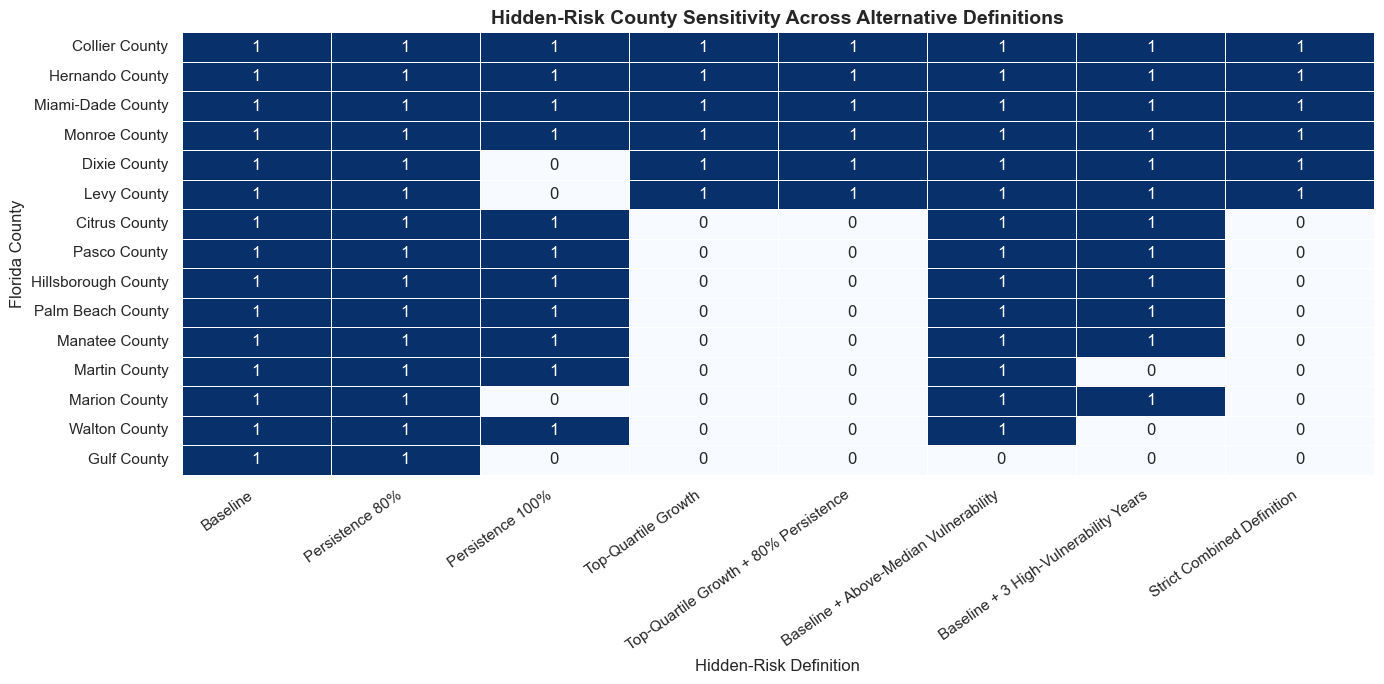

Hidden-risk sensitivity outputs saved successfully.
Figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\hidden_risk_threshold_sensitivity.png


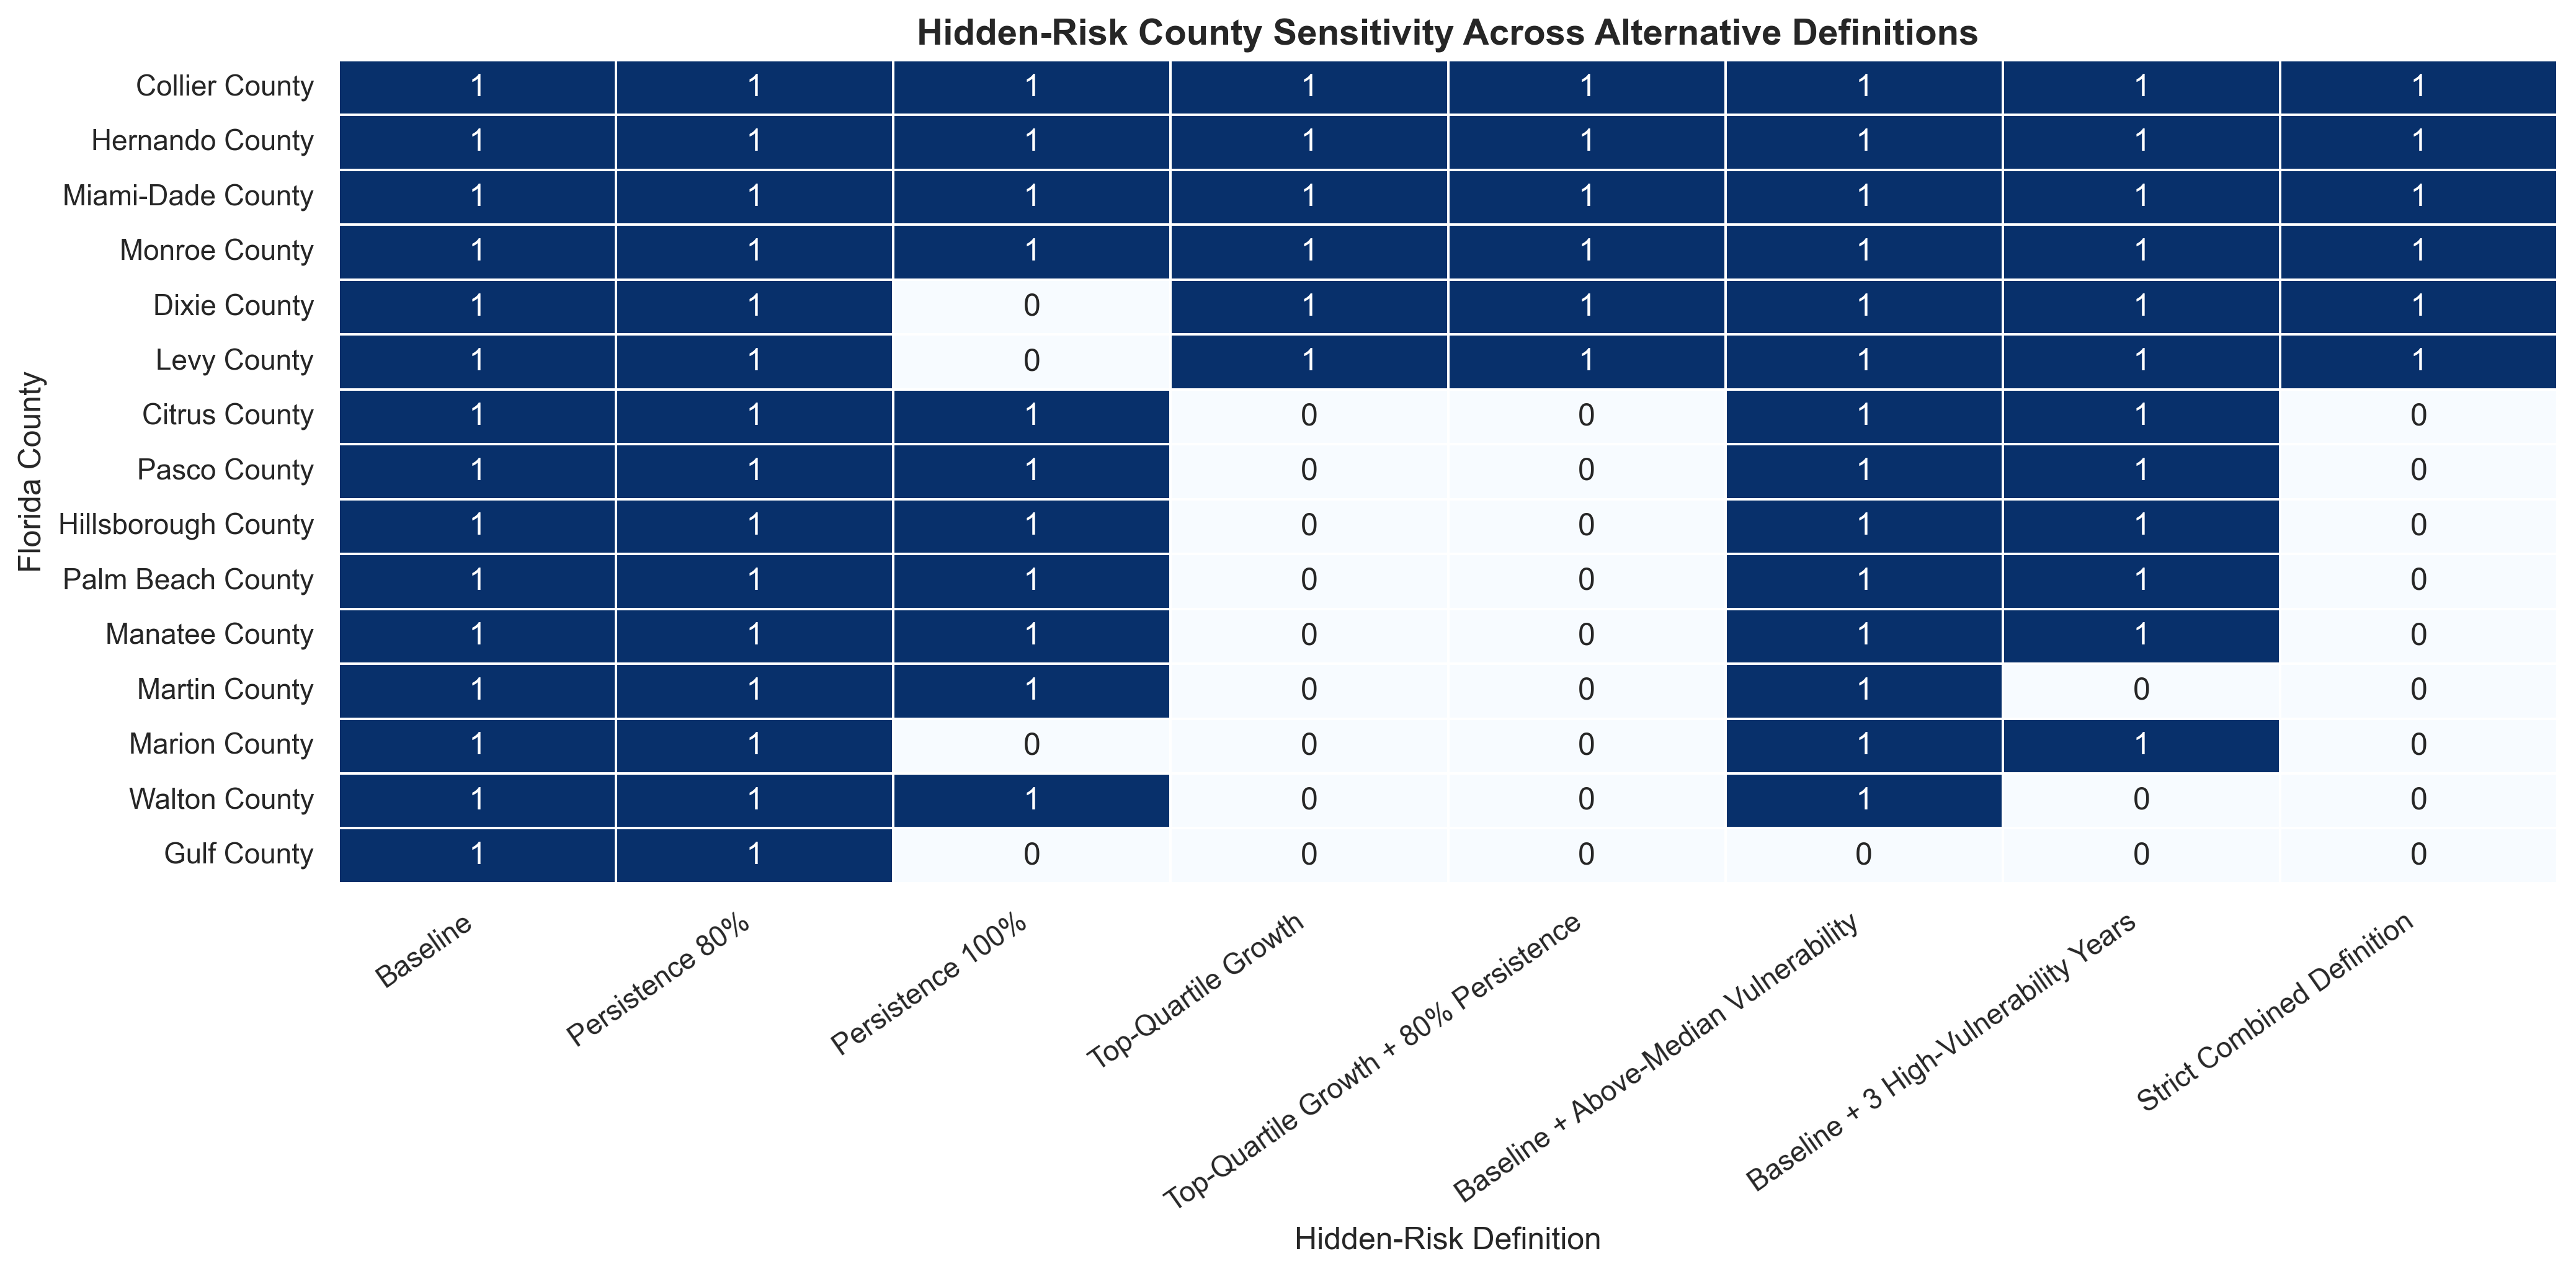

In [26]:
# Hidden-Risk Threshold Sensitivity Analysis

# Additional statewide threshold
median_vulnerability_threshold = hidden_risk_assessment[
    "recent_avg_vulnerability_score"
].median()

# Define Alternative Hidden-Risk Scenarios

sensitivity_scenarios = {
    "Baseline": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0,
    },
    "Persistence 80%": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0,
    },
    "Persistence 100%": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 100,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0,
    },
    "Top-Quartile Growth": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0,
    },
    "Top-Quartile Growth + 80% Persistence": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 0,
    },
    "Baseline + Above-Median Vulnerability": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": True,
        "minimum_high_vulnerability_years": 0,
    },
    "Baseline + 3 High-Vulnerability Years": {
        "growth_threshold": median_growth_threshold,
        "persistence_threshold": 60,
        "require_median_vulnerability": False,
        "minimum_high_vulnerability_years": 3,
    },
    "Strict Combined Definition": {
        "growth_threshold": top_quartile_growth_threshold,
        "persistence_threshold": 80,
        "require_median_vulnerability": True,
        "minimum_high_vulnerability_years": 3,
    },
}

# Apply Every Sensitivity Scenario

sensitivity_selection_matrix = hidden_risk_assessment[["STCOFIPS", "RegionName"]].copy()

scenario_summary_rows = []

for scenario_number, (scenario_name, criteria) in enumerate(
    sensitivity_scenarios.items(), start=1
):

    scenario_flag = (
        hidden_risk_assessment["current_or_dominant_risk_profile"]
        & (
            hidden_risk_assessment["risk_cluster_share_pct"]
            >= criteria["persistence_threshold"]
        )
        & (
            hidden_risk_assessment["recent_avg_annual_growth_pct"]
            >= criteria["growth_threshold"]
        )
    )

    if criteria["require_median_vulnerability"]:
        scenario_flag = scenario_flag & (
            hidden_risk_assessment["recent_avg_vulnerability_score"]
            >= median_vulnerability_threshold
        )

    if criteria["minimum_high_vulnerability_years"] > 0:
        scenario_flag = scenario_flag & (
            hidden_risk_assessment["high_vulnerability_years"]
            >= criteria["minimum_high_vulnerability_years"]
        )

    scenario_column = f"scenario_{scenario_number}"

    sensitivity_selection_matrix[scenario_column] = scenario_flag.astype(int)

    selected_counties = (
        hidden_risk_assessment.loc[scenario_flag, "RegionName"].sort_values().tolist()
    )

    scenario_summary_rows.append(
        {
            "scenario_number": scenario_number,
            "scenario_name": scenario_name,
            "growth_threshold_pct": criteria["growth_threshold"],
            "persistence_threshold_pct": criteria["persistence_threshold"],
            "requires_above_median_vulnerability": criteria[
                "require_median_vulnerability"
            ],
            "minimum_high_vulnerability_years": criteria[
                "minimum_high_vulnerability_years"
            ],
            "counties_identified": int(scenario_flag.sum()),
            "selected_counties": "; ".join(selected_counties),
        }
    )

hidden_risk_sensitivity_summary = pd.DataFrame(scenario_summary_rows)

# Create County-Level Sensitivity Summary

scenario_columns = [
    column
    for column in sensitivity_selection_matrix.columns
    if column.startswith("scenario_")
]

sensitivity_selection_matrix["scenarios_selected"] = sensitivity_selection_matrix[
    scenario_columns
].sum(axis=1)

number_of_scenarios = len(scenario_columns)

sensitivity_selection_matrix["selection_rate_pct"] = (
    sensitivity_selection_matrix["scenarios_selected"] / number_of_scenarios * 100
)

sensitivity_selection_matrix["selected_in_all_scenarios"] = (
    sensitivity_selection_matrix["scenarios_selected"] == number_of_scenarios
)

sensitivity_selection_matrix["selected_in_majority_of_scenarios"] = (
    sensitivity_selection_matrix["scenarios_selected"]
    >= np.ceil(number_of_scenarios / 2)
)

county_sensitivity_summary = (
    hidden_risk_assessment[
        [
            "STCOFIPS",
            "RegionName",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "risk_cluster_share_pct",
            "high_vulnerability_years",
            "latest_cluster_name",
            "dominant_recent_cluster_name",
        ]
    ]
    .merge(
        sensitivity_selection_matrix[
            [
                "STCOFIPS",
                "scenarios_selected",
                "selection_rate_pct",
                "selected_in_all_scenarios",
                "selected_in_majority_of_scenarios",
            ]
        ],
        on="STCOFIPS",
        how="left",
    )
    .sort_values(
        [
            "scenarios_selected",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
        ],
        ascending=[False, False, False],
    )
)

# Retain counties identified in at least one scenario
sensitivity_counties = county_sensitivity_summary[
    county_sensitivity_summary["scenarios_selected"] > 0
].reset_index(drop=True)

# Rename Scenario Columns for Presentation

scenario_column_names = {
    f"scenario_{scenario_number}": scenario_name
    for scenario_number, scenario_name in enumerate(
        sensitivity_scenarios.keys(), start=1
    )
}

presentation_selection_matrix = sensitivity_selection_matrix.rename(
    columns=scenario_column_names
)

# Display Results

print("Hidden-risk threshold sensitivity analysis completed.")

print(
    f"Median recent vulnerability threshold: " f"{median_vulnerability_threshold:.4f}"
)

print(f"Scenarios tested: " f"{number_of_scenarios}")

print("\nSensitivity scenario summary")
display(
    hidden_risk_sensitivity_summary[
        [
            "scenario_name",
            "growth_threshold_pct",
            "persistence_threshold_pct",
            "requires_above_median_vulnerability",
            "minimum_high_vulnerability_years",
            "counties_identified",
        ]
    ].round(4)
)

print("Counties identified in at least one scenario")
display(
    sensitivity_counties[
        [
            "RegionName",
            "scenarios_selected",
            "selection_rate_pct",
            "risk_cluster_share_pct",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "high_vulnerability_years",
            "dominant_recent_cluster_name",
        ]
    ].round(4)
)

print("Counties identified in every scenario")
display(
    sensitivity_counties[sensitivity_counties["selected_in_all_scenarios"]][
        [
            "RegionName",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "risk_cluster_share_pct",
            "high_vulnerability_years",
        ]
    ].round(4)
)

# Visualize Scenario Consistency

plot_selection_matrix = presentation_selection_matrix[
    presentation_selection_matrix["scenarios_selected"] > 0
].set_index("RegionName")[list(sensitivity_scenarios.keys())]

# Sort counties by number of scenarios selected
plot_selection_matrix = (
    plot_selection_matrix.assign(total_selected=lambda data: data.sum(axis=1))
    .sort_values("total_selected", ascending=False)
    .drop(columns="total_selected")
)

plt.figure(figsize=(14, max(7, len(plot_selection_matrix) * 0.45)))

sns.heatmap(
    plot_selection_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
)

plt.title(
    "Hidden-Risk County Sensitivity Across Alternative Definitions",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Hidden-Risk Definition")
plt.ylabel("Florida County")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

sensitivity_figure_path = RESULTS_FIGURES / "hidden_risk_threshold_sensitivity.png"

plt.savefig(sensitivity_figure_path, dpi=300, bbox_inches="tight")

plt.show()

# Save Sensitivity Outputs

hidden_risk_sensitivity_summary.to_csv(
    RESULTS_TABLES / "hidden_risk_sensitivity_scenarios.csv", index=False
)

presentation_selection_matrix.to_csv(
    RESULTS_TABLES / "hidden_risk_sensitivity_selection_matrix.csv", index=False
)

county_sensitivity_summary.to_csv(
    RESULTS_TABLES / "hidden_risk_sensitivity_county_summary.csv", index=False
)

print("Hidden-risk sensitivity outputs saved successfully.")

print(f"Figure saved to: " f"{sensitivity_figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "hidden_risk_threshold_sensitivity.png"),
        width=850,
    )
)


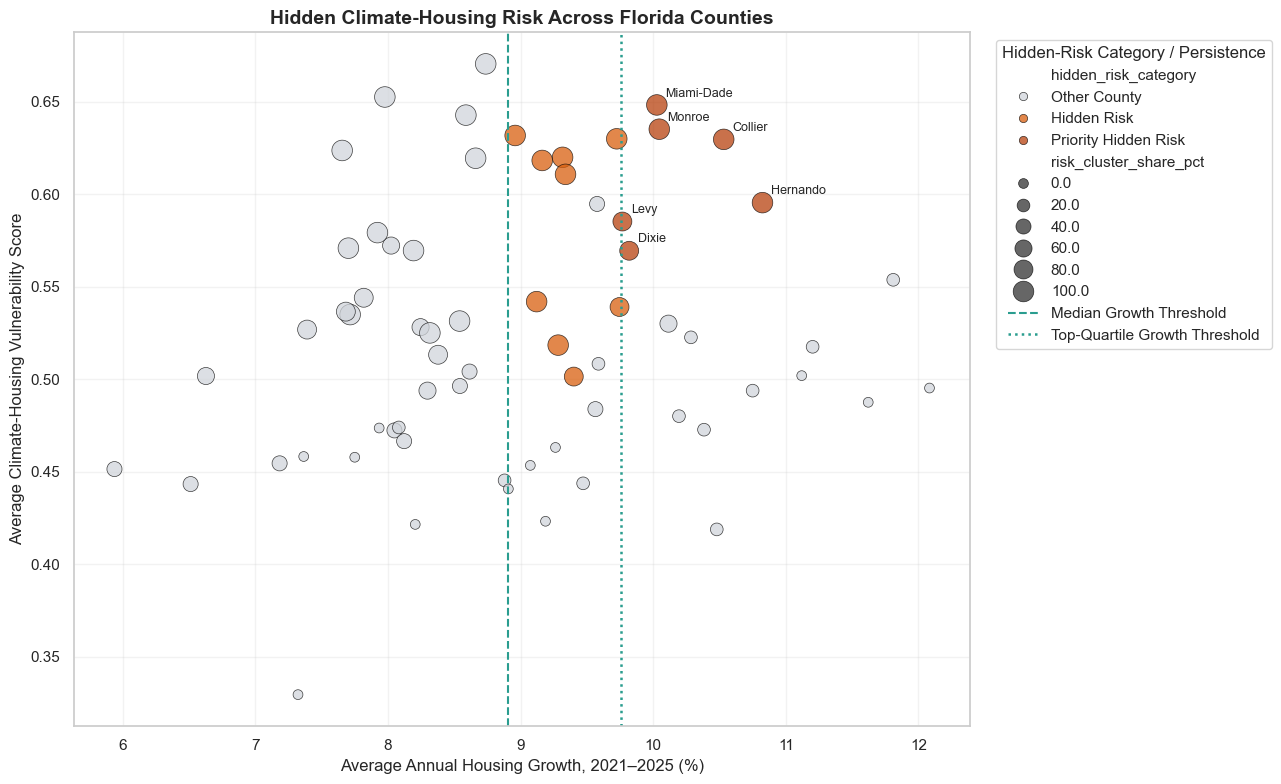

Hidden-risk county figure saved to: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering\hidden_risk_county_scatterplot.png


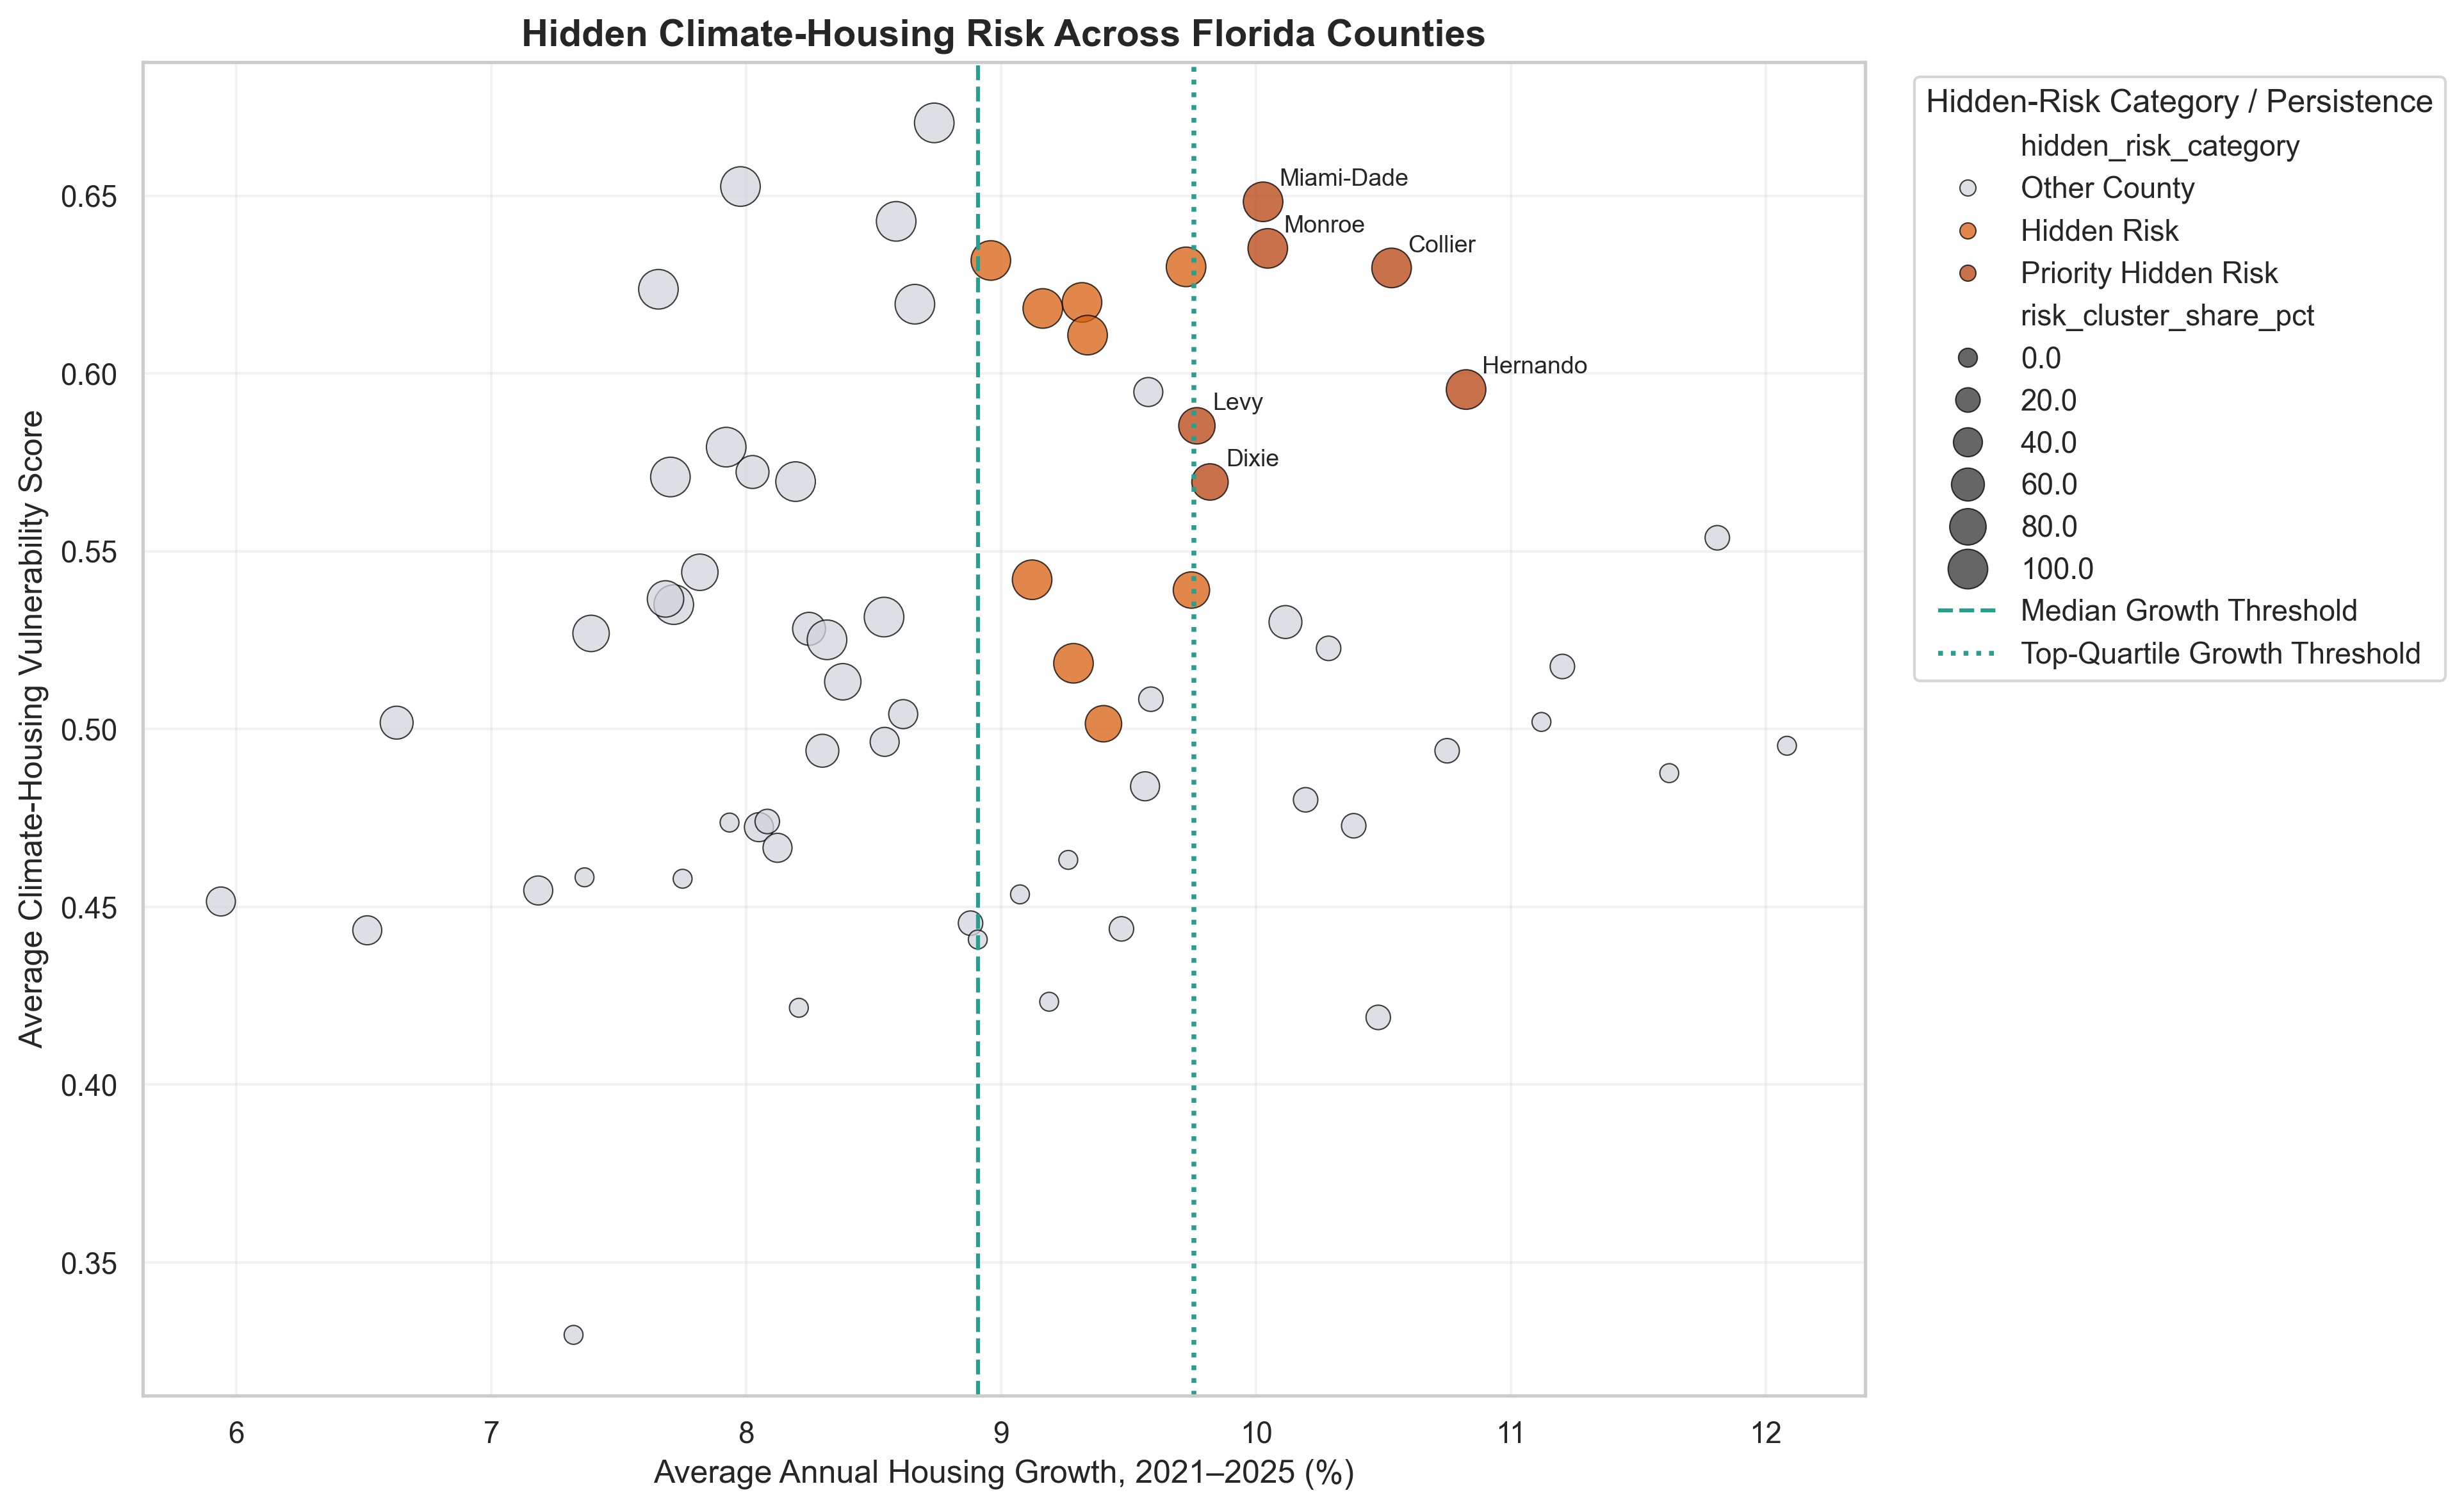

In [27]:
hidden_risk_category_order = ["Other County", "Hidden Risk", "Priority Hidden Risk"]

plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=hidden_risk_assessment,
    x="recent_avg_annual_growth_pct",
    y="recent_avg_vulnerability_score",
    hue="hidden_risk_category",
    hue_order=hidden_risk_category_order,
    palette=HIDDEN_RISK_COLORS,
    size="risk_cluster_share_pct",
    sizes=(50, 220),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5,
)

# Growth Thresholds

plt.axvline(
    median_growth_threshold,
    linestyle="--",
    linewidth=1.5,
    label="Median Growth Threshold",
)

plt.axvline(
    top_quartile_growth_threshold,
    linestyle=":",
    linewidth=1.8,
    label="Top-Quartile Growth Threshold",
)

# Label Priority Hidden-Risk Counties

priority_counties = hidden_risk_assessment[
    hidden_risk_assessment["priority_hidden_risk_flag"]
].copy()

for _, row in priority_counties.iterrows():
    county_label = row["RegionName"].replace(" County", "")

    plt.annotate(
        county_label,
        (row["recent_avg_annual_growth_pct"], row["recent_avg_vulnerability_score"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

plt.title(
    "Hidden Climate-Housing Risk Across Florida Counties",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel(f"Average Annual Housing Growth, " f"{recent_start_year}–{latest_year} (%)")

plt.ylabel("Average Climate-Housing Vulnerability Score")

plt.legend(
    title="Hidden-Risk Category / Persistence",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(alpha=0.25)
plt.tight_layout()

figure_path = RESULTS_FIGURES / "hidden_risk_county_scatterplot.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Hidden-risk county figure saved to: " f"{figure_path}")

display(
    Image(
        filename=str(RESULTS_FIGURES / "hidden_risk_county_scatterplot.png"), width=850
    )
)


## 10. Export models and final outputs

The complete county-year assignments, diagnostics, county summaries, fitted scaler, final K-Means estimator, and PCA model are saved under the filenames required by Notebooks 08 and 09.


In [28]:
import joblib

# Save Final County-Year Cluster Assignments

clustered_output_path = RESULTS_TABLES / "county_year_vulnerability_clusters.csv"

clustered_data.to_csv(clustered_output_path, index=False)

# Save Clustering Evaluation Tables

cluster_selection_table.to_csv(
    RESULTS_TABLES / "kmeans_cluster_selection_results.csv", index=False
)

algorithm_comparison_table.to_csv(
    RESULTS_TABLES / "clustering_algorithm_comparison.csv", index=False
)

cluster_stability_table.to_csv(
    RESULTS_TABLES / "cluster_stability_results.csv", index=False
)

correlation_matrix.to_csv(RESULTS_TABLES / "clustering_feature_correlations.csv")

clustering_summary.to_csv(RESULTS_TABLES / "clustering_feature_summary.csv")

# Save Final Cluster Profile Tables

final_cluster_profiles.to_csv(RESULTS_TABLES / "standardized_cluster_profiles.csv")

final_cluster_profile_table.to_csv(RESULTS_TABLES / "final_cluster_profiles.csv")

cluster_name_table.to_csv(RESULTS_TABLES / "cluster_name_mapping.csv", index=False)

housing_market_profile_table.to_csv(
    RESULTS_TABLES / "cluster_housing_market_profiles.csv"
)

cluster_class_counts.to_csv(RESULTS_TABLES / "cluster_vulnerability_class_counts.csv")

cluster_class_percentages.to_csv(
    RESULTS_TABLES / "cluster_vulnerability_class_percentages.csv"
)

# Save PCA Results

explained_variance_table.to_csv(
    RESULTS_TABLES / "pca_explained_variance.csv", index=False
)

pca_centers_table.to_csv(RESULTS_TABLES / "pca_cluster_centers.csv", index=False)

# Save County-Level Results

county_cluster_membership.to_csv(
    RESULTS_TABLES / "county_cluster_membership.csv", index=False
)

hidden_risk_assessment.to_csv(
    RESULTS_TABLES / "county_hidden_risk_assessment.csv", index=False
)

hidden_risk_counties.to_csv(RESULTS_TABLES / "hidden_risk_counties.csv", index=False)

# Save Fitted Objects

joblib.dump(scaler, RESULTS_MODELS / "clustering_standard_scaler.joblib")

joblib.dump(final_kmeans_model, RESULTS_MODELS / "final_kmeans_model.joblib")

joblib.dump(pca, RESULTS_MODELS / "clustering_pca_model.joblib")

# Save Notebook Summary

clustering_output_summary = pd.DataFrame(
    {
        "item": [
            "County-year observations",
            "Florida counties",
            "Study period",
            "Clustering features",
            "Final number of clusters",
            "Final clustering algorithm",
            "Hidden-risk counties",
            "Priority hidden-risk counties",
        ],
        "value": [
            len(clustered_data),
            clustered_data["STCOFIPS"].nunique(),
            f"{clustered_data['Year'].min()}–{clustered_data['Year'].max()}",
            len(CLUSTERING_FEATURES),
            FINAL_N_CLUSTERS,
            "K-Means",
            len(hidden_risk_counties),
            int(hidden_risk_counties["priority_hidden_risk_flag"].sum()),
        ],
    }
)

clustering_output_summary.to_csv(
    RESULTS_TABLES / "clustering_output_summary.csv", index=False
)

print("Final clustering outputs saved successfully.")
print(f"Clustered dataset: {clustered_output_path}")
print(f"Tables folder: {RESULTS_TABLES}")
print(f"Figures folder: {RESULTS_FIGURES}")
print(f"Models folder: {RESULTS_MODELS}")

display(clustering_output_summary)


Final clustering outputs saved successfully.
Clustered dataset: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering\county_year_vulnerability_clusters.csv
Tables folder: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\tables\vulnerability_clustering
Figures folder: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\figures\vulnerability_clustering
Models folder: C:\Users\saadm\OneDrive\Documents\MRP\climate-risk-housing-valuation\results\models\vulnerability_clustering


,item,value
0,County-year observations,1000
1,Florida counties,67
2,Study period,2011–2025
3,Clustering features,7
4,Final number of clusters,4
5,Final clustering algorithm,K-Means
6,Hidden-risk counties,15
7,Priority hidden-risk counties,6


## 11. Key findings

The final four-profile solution separates a Lower-Stress Resilient Profile, Disaster-Loss Growth Pressure, High-Exposure Latent Risk, and Socioeconomic Resilience Stress. The profiles differ not only in overall severity but in the form of vulnerability they express. Seed checks are strong, while the recent county-level and county-bootstrap analyses show moderate—rather than perfect—assignment stability, supporting use of the profiles as exploratory structures.

Fifteen counties satisfy the baseline hidden-risk definition and six meet the stricter priority rule. Collier, Hernando, Miami-Dade, and Monroe are selected under all eight sensitivity scenarios; Dixie and Levy are selected under seven. These results motivate the spatial synthesis and county-level explainability analyses that follow.
